# [n8n 제외판] FFCell v80 PART21-28 + 개별 기여도·5_240 진단 — 그래프·분석 재현용 (팀 공유)

원본 「FFCell_v81_4of4_PART21-29_전체.ipynb」에서 **n8n/Slack 전송 코드를 전부 제거**하고,
판정 로직·통계·그래프만 남긴 버전입니다. PPT용 그래프·수치를 재현하는 용도로 팀원 전체가 실행할 수 있습니다.

**제외한 것**: n8n 웹훅 전송(`send_to_n8n`, `requests.post`), Slack 첨부용 이미지 base64 캐싱, PART26-4(라인정지 알림 n8n 예시), PART29 전체(투트랙 알림 — 실시간+What-if). 데모 페이싱용 `time.sleep()`도 함께 제거해 실행 속도를 높였습니다.

**그대로 남긴 것**: EDA·규칙기반 임계값 확정 과정(PART98~132), 24년 실데이터 검증(PART21, 정확도만), 튜터 피드백 반영(PART22), 5_40 경계 케이스 분석(PART23), 조기경보 시점 단축 효과 계산(PART24·25), 사이클 자체감지·라인정지 임계값 통계(PART26~27), 2024 자체감지 정확도 검증(PART28) — 전부 원본과 동일한 계산 로직입니다.


In [1]:
!pip install scikit-posthocs imblearn --quiet

In [2]:
# ── 한글 폰트 설정 (그래프 제목·범례 깨짐 방지) ──────────────────────────
# Colab은 새 런타임을 열 때마다 시스템 폰트가 초기화되므로, 파일을 열 때마다 다시 실행 필요.
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib as mpl
import matplotlib.font_manager as fm
fm.fontManager.__init__()
mpl.rc("font", family="NanumGothic")
mpl.rcParams["axes.unicode_minus"] = False
print("나눔고딕 설정 완료")


나눔고딕 설정 완료


In [3]:
# ── [분할 파일 시작] 이전 파일(part14) 세션 복원 ─────────────────────────────
# 이 파일은 FFCell_integrated_notebook_v80(PART 번호 연속 정리판)을 작업용으로
# 4등분한 것 중 "최종 마무리" (PART 15~19) 부분이다. 아래 셀로 이전 파일 끝 시점
# 전체 상태를(함수·변수·df 전부) 그대로 복원한 뒤, 이어지는 셀부터 실행하면 된다.
from pathlib import Path
_CACHE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints')

from google.colab import drive
drive.mount('/content/drive')

try:
    import dill
except ImportError:
    !pip install dill --quiet
    import dill

_session_path = _CACHE_DIR / 'part14_session.pkl'
if _session_path.exists():
    dill.load_session(str(_session_path))
    print(f"[세션 복원 완료] {_session_path} ← 이전 파일 상태를 그대로 이어받았습니다.")
else:
    print(f"[체크포인트 없음] {_session_path} 파일이 없습니다.")
    print("  → 이전 분할 파일을 먼저 끝까지 실행해서 체크포인트를 만들어두세요.")
    raise FileNotFoundError(
        f"세션 체크포인트({_session_path})가 없어 이전 PART(1~14)의 변수·데이터프레임을 "
        "복원할 수 없습니다. 아래 셀부터는 이 상태에 의존하므로, 여기서 실행을 멈추고 "
        "이전 분할 파일(part14)을 먼저 끝까지 실행해 체크포인트를 만든 뒤 다시 시도하세요."
    )


Mounted at /content/drive
[세션 복원 완료] /content/drive/MyDrive/Colab Notebooks/FFCell/_checkpoints/part14_session.pkl ← 이전 파일 상태를 그대로 이어받았습니다.


---
# PART 15. 튜터 중간 피드백 반영 (v71 신규)

중간 산출물에 대한 튜터 피드백 4개 항목을 반영한다. 라벨 오류 관련 표현("확정"→"의심되어
확인 필요")은 위쪽 60·62·65·67·72장 등 관련 셀에 직접 반영해뒀다(이 PART에서는 표현
정정 사실만 기록). 아래에서는 나머지 세 가지 — ① 사이클 개수 흐름, ② 규칙기반 임계값
설정 근거, ③ 변수선택(KW+FDR) 데이터 누수, ④ Body1 미탐지 원인 — 을 다룬다.

## 98. 완전한 사이클 수 흐름 — 327 → 316 한 표로 통합 (v80: 319→320 반영 / 2026-07-28 PART20·23 반영 재갱신)

23-1장(151~152장)의 깔때기 표는 325개부터 시작했다 — 그보다 앞선 327개(원본, `reset_flag`
경계 기준) 단계와, PART13(60장)의 라벨오류 의심 제외 단계가 빠져 있었다. 튜터
피드백대로, **327개에서 최종 316개가 되기까지 전 과정**을 하나의 표로 정리한다.
(v80 갱신: v79에서 `rise_slope` dropna 버그를 고쳐 ④단계가 319→320개로 늘어
최종 숫자도 317→318로 바뀌었다.)

⚠️ **2026-07-28 재갱신**: ⑤단계(라벨오류 의심 제외)의 대상이 바뀌었다. 당시엔
`5_253, 5_265` 2개였으나, PART20에서 `5_253`은 지연보정 후 원본 라벨과 일치함이
확인되어 제외 목록에서 빠졌고, 대신 `5_10·5_11·5_28`이 `5_265`와 같은 유형(조립순서상
불가능한 신호 조합)으로 새로 추가되어 현재는 **`5_10·5_11·5_28·5_265` 4개 제외 →
316개**가 최종 숫자다 (PART23 결론과 동일).

In [4]:
# ── 98. 전체 사이클 수 흐름 (327 → 316, 2026-07-28 PART20·23 반영 재갱신) 통합 표 ─────
full_cycle_funnel = []

full_cycle_funnel.append((
    '⓪ 원본 (reset_flag 경계 기준, 6개 세션 합산)', 327,
    '9장 근거 — 세션별 사이클을 그대로 합산한 값'))
full_cycle_funnel.append((
    '① 지속시간 QA (경계 온전성 확인)', 325,
    '지속시간 기준 불완전 사이클 2개(2_0, 4_0) 제거'))
full_cycle_funnel.append((
    '② 센서 QA (워밍업 결측 제외)', 323,
    '1_1, 1_2 (R04 부하 변동성 이상 — 14장 v80 정정) 추가 제외'))
full_cycle_funnel.append((
    '③ 최종 피처셋 (세션0 제외)', len(final_features) if 'final_features' in dir() else 320,
    "'0_' 프리픽스 세션0(워밍업, 3개) 제외"))
full_cycle_funnel.append((
    '④ 모델 학습 (전체 피처 dropna)', len(model_df) if 'model_df' in dir() else 320,  # v79 수정 후 dropna 제외 0개 반영
    '124개 피처 중 하나라도 NaN이면 사이클 전체 제외'))
full_cycle_funnel.append((
    '⑤ 라벨오류 의심 사이클 제외 (PART20·23 최종 확정, 2026-07-28 재갱신)',
    (len(model_df) if 'model_df' in dir() else 320) - 4,
    "5_10·5_11·5_28·5_265 — 조립순서상 물리적으로 불가능한 신호 조합으로 라벨오류 의심 "
    "(구버전은 5_253·5_265 2개였으나, 5_253은 지연보정 후 원본 라벨과 일치함이 확인되어 "
    "제외 목록에서 빠지고 5_10·5_11·5_28이 새로 추가됨 — PART23 참고)"))

print('[전체 사이클 수 흐름 — 327 → 316, 6단계 통합 (2026-07-28 재갱신)]\n')
prev = None
for name, n, reason in full_cycle_funnel:
    diff = f'(-{prev - n})' if prev is not None else ''
    print(f'  {name:42s}: {n:4d}개  {diff:6s}  | {reason}')
    prev = n

print('\n★ 보고서에는 이 표 전체를 인용할 것 — 단일 숫자만 쓰지 말고 '
      '반드시 "어느 단계 기준인지"를 함께 명시한다(튜터 피드백 반영).')
print('★ ⑤ 단계는 "확정 제외"가 아니라 "라벨 오류가 의심되어 확인이 필요해 잠정 제외"로'
      ' 표현한다(튜터 피드백 반영).')
print('★ ⑤ 단계 대상은 PART20·23에서 최종 확정된 5_10·5_11·5_28·5_265 기준이다 '
      '(구버전 5_253·5_265 기준의 "318개"는 더 이상 사용하지 않는다).')

[전체 사이클 수 흐름 — 327 → 316, 6단계 통합 (2026-07-28 재갱신)]

  ⓪ 원본 (reset_flag 경계 기준, 6개 세션 합산)         :  327개          | 9장 근거 — 세션별 사이클을 그대로 합산한 값
  ① 지속시간 QA (경계 온전성 확인)                     :  325개  (-2)    | 지속시간 기준 불완전 사이클 2개(2_0, 4_0) 제거
  ② 센서 QA (워밍업 결측 제외)                       :  323개  (-2)    | 1_1, 1_2 (R04 부하 변동성 이상 — 14장 v80 정정) 추가 제외
  ③ 최종 피처셋 (세션0 제외)                         :  320개  (-3)    | '0_' 프리픽스 세션0(워밍업, 3개) 제외
  ④ 모델 학습 (전체 피처 dropna)                    :  320개  (-0)    | 124개 피처 중 하나라도 NaN이면 사이클 전체 제외
  ⑤ 라벨오류 의심 사이클 제외 (PART20·23 최종 확정, 2026-07-28 재갱신):  316개  (-4)    | 5_10·5_11·5_28·5_265 — 조립순서상 물리적으로 불가능한 신호 조합으로 라벨오류 의심 (구버전은 5_253·5_265 2개였으나, 5_253은 지연보정 후 원본 라벨과 일치함이 확인되어 제외 목록에서 빠지고 5_10·5_11·5_28이 새로 추가됨 — PART23 참고)

★ 보고서에는 이 표 전체를 인용할 것 — 단일 숫자만 쓰지 말고 반드시 "어느 단계 기준인지"를 함께 명시한다(튜터 피드백 반영).
★ ⑤ 단계는 "확정 제외"가 아니라 "라벨 오류가 의심되어 확인이 필요해 잠정 제외"로 표현한다(튜터 피드백 반영).
★ ⑤ 단계 대상은 PART20·23에서 최종 확정된 5_10·5_11·5_28·5_265 기준이다 (구버전 5_253·5_265 기준의 "318개"는 더 이상 사용하지 않는다)

## 98-1. 원본 데이터 기반 독립 재검증 (327 → 320)

지금까지의 327→316 사이클 수 흐름은(2026-07-28 재갱신) 전부 파이프라인 안에서 파생된 변수(`df_all`,
`final_features` 등)를 기준으로 계산된 것이다. 여기서는 **원본 CSV 7개 파일을 처음부터
다시 불러와서**, 파이프라인 변수를 하나도 재사용하지 않고 독립적으로 재계산해 앞의
숫자들이 맞는지 교차검증한다 (변수명을 전부 `_chk` 접미사로 구분해 기존 파이프라인과
섞이지 않게 한다).

다만 ④(dropna, 320개)·⑤(라벨오류 의심, 316개 — 2026-07-28 기준 5_10·5_11·5_28·5_265
4개 제외) 두 단계는 전체 피처 엔지니어링을 다시 해야 확인 가능하고, ⑤는 애초에 자동
계산이 아니라 팀이 수동으로 의심한 사이클이라 원본 데이터만으로는 재현할 수 없다 —
이번 검증은 ⓪~③(327→320)까지만 다룬다.

In [5]:
# ── 원본 데이터 독립 재검증 [1/3] — 파일 로드 + ⓪ 327개 확인 ─────────────────
import pandas as pd
import numpy as np

FILES_CHECK = {
    "cycle": "FFCell_CycleManagement.csv",
    "safety": "FFCell_SafetyManagement.csv",
    "conveyor": "Conveyor_Signals.csv",
    "R01": "R01_Data.csv",
    "R02": "R02_Data.csv",
    "R03": "R03_Data.csv",
    "R04": "R04_Data.csv",
}

dfs_check = {}
for key, fname in FILES_CHECK.items():
    df = pd.read_csv(DATA_DIR / fname, low_memory=False)
    df['_time'] = pd.to_datetime(df['_time'], utc=True, format='ISO8601')  # ★ 이 줄 추가
    dfs_check[key] = df
    print(key, df.shape)

cycle_chk = dfs_check["cycle"].copy()
cycle_chk["Q_Cell_CycleCount"] = pd.to_numeric(cycle_chk["Q_Cell_CycleCount"], errors="coerce")
cycle_chk["reset_flag"] = (cycle_chk["Q_Cell_CycleCount"].diff() < 0).cumsum()
cycle_chk["cycle_id"] = cycle_chk["reset_flag"].astype(str) + "_" + cycle_chk["Q_Cell_CycleCount"].astype(str)

n_stage0_chk = cycle_chk["cycle_id"].nunique()
print("\nreset_flag 범위:", sorted(cycle_chk["reset_flag"].unique()), "(기대: 0~5)")
print("독립 계산 사이클 수:", n_stage0_chk, "(기대: 327)")

cycle (974836, 4)
safety (974836, 6)
conveyor (974836, 11)
R01 (974836, 10)
R02 (974836, 10)
R03 (974836, 10)
R04 (974836, 10)

reset_flag 범위: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] (기대: 0~5)
독립 계산 사이클 수: 327 (기대: 327)


In [6]:
# ── 원본 데이터 독립 재검증 [2/3] — ① 지속시간 이상치 탐지 ──────────────────
cycle_chk["_time"] = pd.to_datetime(cycle_chk["_time"], errors="coerce")


def get_duration(s):
    return (s.max() - s.min()).total_seconds()


dur_stats_chk = cycle_chk.groupby("cycle_id").agg(n_rows=("_time", "size"))
dur_stats_chk["duration_s"] = cycle_chk.groupby("cycle_id")["_time"].apply(get_duration)

print("[지속시간 분포]")
print(dur_stats_chk["duration_s"].describe())

median_dur_chk = dur_stats_chk["duration_s"].median()
suspect_short_chk = dur_stats_chk[dur_stats_chk["duration_s"] < median_dur_chk * 0.25]
print(f"\n[지속시간 이상치 의심] 중앙값({median_dur_chk:.1f}초)의 25% 미만:")
print(suspect_short_chk)
print("\n※ 여기 2_0, 4_0이 나오는지 확인 — 나온다면 '① 지속시간 불완전' 판정이 재현된 것")
print("  (25% 기준으로 안 잡히면 임계값을 조정해서 재확인할 것)")

[지속시간 분포]
count    327.000000
mean     298.075355
std       27.517161
min        6.607000
25%      294.603000
50%      294.996000
75%      295.307500
max      446.007000
Name: duration_s, dtype: float64

[지속시간 이상치 의심] 중앙값(295.0초)의 25% 미만:
          n_rows  duration_s
cycle_id                    
2_0          132      13.113
4_0           67       6.607

※ 여기 2_0, 4_0이 나오는지 확인 — 나온다면 '① 지속시간 불완전' 판정이 재현된 것
  (25% 기준으로 안 잡히면 임계값을 조정해서 재확인할 것)


In [7]:
# ── 원본 데이터 독립 재검증 [3/3] — ② 센서 QA + ③ 세션0 ────────────────────
merged_chk = cycle_chk.merge(dfs_check["R01"], on="_time", how="left")
merged_chk = merged_chk.merge(dfs_check["R04"], on="_time", how="left")
merged_chk["cycle_id"] = merged_chk["cycle_id"].ffill()

r01_cols_chk = [c for c in merged_chk.columns if c.startswith("I_R01") or c.startswith("M_R01")]
r04_cols_chk = [c for c in merged_chk.columns if c.startswith("I_R04") or c.startswith("M_R04")]


def signal_ratio(g, cols):
    vals = g[cols].fillna(0)
    return (vals.abs().sum(axis=1) > 0).mean()


sensor_records = []
for cid, g in merged_chk.groupby("cycle_id"):
    sensor_records.append({
        "cycle_id": cid,
        "r01_signal_ratio": signal_ratio(g, r01_cols_chk),
        "r04_signal_ratio": signal_ratio(g, r04_cols_chk),
    })
sensor_check_df = pd.DataFrame(sensor_records).set_index("cycle_id")

print("[② 센서 신호 비율이 낮은 사이클 Top 10 (R01 기준)]")
print(sensor_check_df.sort_values("r01_signal_ratio").head(10))
print("\n※ 여기 1_1, 1_2가 낮은 순위에 나오는지 확인")

session0_check = [c for c in cycle_chk["cycle_id"].unique() if str(c).startswith("0_")]
print(f"\n[③ 세션0] '0_' 프리픽스 사이클: {len(session0_check)}개 → {sorted(session0_check)}")
print(f"[③ 검증] {n_stage0_chk} - {len(session0_check)} = "
      f"{n_stage0_chk - len(session0_check)}개 (기대: 지속시간·센서QA 반영 후 320개 근처)")

print("\n[요약] 이번 독립 재검증에서 327·세션0 개수가 파이프라인 결과와 일치하면,")
print("  ⓪~③ 단계는 원본 데이터로도 재현되는 신뢰할 수 있는 숫자라고 결론 내릴 수 있다.")

[② 센서 신호 비율이 낮은 사이클 Top 10 (R01 기준)]
          r01_signal_ratio  r04_signal_ratio
cycle_id                                    
5_92                   1.0               1.0
5_91                   1.0               1.0
5_90                   1.0               1.0
5_9                    1.0               1.0
5_89                   1.0               1.0
5_88                   1.0               1.0
5_87                   1.0               1.0
5_86                   1.0               1.0
5_85                   1.0               1.0
5_84                   1.0               1.0

※ 여기 1_1, 1_2가 낮은 순위에 나오는지 확인

[③ 세션0] '0_' 프리픽스 사이클: 3개 → ['0_1', '0_2', '0_3']
[③ 검증] 327 - 3 = 324개 (기대: 지속시간·센서QA 반영 후 320개 근처)

[요약] 이번 독립 재검증에서 327·세션0 개수가 파이프라인 결과와 일치하면,
  ⓪~③ 단계는 원본 데이터로도 재현되는 신뢰할 수 있는 숫자라고 결론 내릴 수 있다.


In [8]:
# ③ 세션0 제외 대상 확인
session0_ids = [c for c in final_features.index if c.startswith('0_')]
print(f"세션0 제외 대상 ({len(session0_ids)}개): {session0_ids}")

# ④ dropna로 제외된 사이클 확인
dropna_excluded = final_features.index.difference(model_df.index).tolist()
print(f"dropna 제외 대상 ({len(dropna_excluded)}개): {dropna_excluded}")

세션0 제외 대상 (0개): []
dropna 제외 대상 (0개): []


## 99. 라벨 오류 표현 정정 — 반영 확인

튜터 피드백: *"라벨 오류를 '확정'이라고 표현하기보다는 '라벨 오류가 의심되는 데이터로 판단되어
확인이 필요함' 정도로 표현하는 것이 적절하다."*

이 노트북 전체에서 5_253·5_265를 가리키던 "라벨오류 확정"류 표현을 다음과 같이 정정했다
(PART13, 60·62·65·67·72장 등 관련 셀 전부).

| 정정 전 | 정정 후 |
|---|---|
| "라벨 오류로 최종 확정해 처리한다" | "라벨 오류가 의심되는 데이터로 판단해 처리한다" |
| "## 60. 라벨 오류 확정 처리" | "## 60. 라벨 오류 의심 사이클 처리" |
| "라벨링 오류로 최종 확정되었다" | "라벨링 오류가 의심되는 데이터로 판단되어 확인이 필요한 상태로 정리됐다" |
| "라벨오류 확정 사이클" (변수·주석) | "라벨오류 의심 사이클" |
| "라벨오류로 확정된 2개" | "라벨오류가 의심되는 2개" |

다만 코드 변수명 `CONFIRMED_MISLABELED`는 그대로 유지했다 — 이미 여러 셀(72장 등)에서
이 이름을 그대로 참조하고 있어서, 이름을 바꾸면 코드가 깨진다. **변수명과 별개로, 보고서·
발표에서 이 데이터를 가리킬 때는 "라벨 오류가 의심되는 데이터(확인 필요)"라고만 표현할 것**
— 이 점을 팀 전체에 공유해둘 것을 권장한다.

## 100. 규칙기반 임계값 — 학습 데이터만 사용했는지 명시

튜터 피드백: *"규칙 기반 임계값을 어떻게 정했는지 반드시 설명이 필요하다. 학습 데이터만
사용했는지 명확히 밝혀야 결과의 신뢰성이 높아진다."*

솔직하게 확인한다. `R03_NOSE_THRESH`(17장, 셀99)와 `BODY2_THRESH`·`BODY1_THRESH`(52장,
셀256)는 전부 **전체 데이터**(`nose_sig_df`, `body_force_df` — 세션1~5 전부)의 Normal/NoNose
또는 존재/부재 그룹 중앙값으로 계산됐다. 즉 지금까지 70장 이후로 우리가 계속 써온 임계값은
**학습 전용이 아니라 전체 데이터 기준**이었다.

In [9]:
# ── 100. 임계값별로 "학습 데이터만 사용 가능한지" 직접 확인 ───────────────────────
print('=== 현재 사용 중인 임계값의 계산 범위 ===')
print(f'R03_NOSE_THRESH (전체 데이터 기준) = {R03_NOSE_THRESH:.1f}')
print(f'BODY2_THRESH    (전체 데이터 기준) = {BODY2_THRESH:.1f}')
print(f'BODY1_THRESH    (전체 데이터 기준) = {BODY1_THRESH:.1f}')

# --- Nose: 세션1~4(학습)에 Normal·NoNose 둘 다 있으므로 학습전용 재계산이 가능하다 ---
nose_train = nose_sig_df.loc[nose_sig_df.index.intersection(train_ids_full)]
nose_a_train = nose_train.loc[nose_train['label'] == 'Normal', 'r03_nose_peak'].dropna()
nose_b_train = nose_train.loc[nose_train['label'] == 'NoNose', 'r03_nose_peak'].dropna()
R03_NOSE_THRESH_TRAIN = (nose_a_train.median() + nose_b_train.median()) / 2

print(f'\n[Nose] 세션1~4(학습)에 Normal {len(nose_a_train)}개, NoNose {len(nose_b_train)}개 존재'
      f' → 학습전용 재계산 가능')
print(f'R03_NOSE_THRESH(학습전용) = {R03_NOSE_THRESH_TRAIN:.1f}  '
      f'(전체데이터 기준과 차이 {abs(R03_NOSE_THRESH_TRAIN - R03_NOSE_THRESH):.1f}, '
      f'{abs(R03_NOSE_THRESH_TRAIN - R03_NOSE_THRESH) / R03_NOSE_THRESH * 100:.1f}%)')

# --- Body2 / Body1: 세션1~4에는 "없음" 라벨 자체가 없다 ---
body_train = body_force_df.loc[body_force_df.index.intersection(train_ids_full)]
print(f"\n[Body2/Body1] 세션1~4(학습)에 존재하는 라벨 종류: {sorted(body_train['label'].unique())}")
print('※ NoNose,NoBody2·NoNose,NoBody2,NoBody1 라벨 자체가 세션1~4에 없다 — 즉')
print('  "Body2/Body1이 없는 사이클"의 학습 예시가 원천적으로 존재하지 않는다. 그래서')
print('  BODY2_THRESH·BODY1_THRESH는 학습(세션1~4)-전용 재계산이 구조적으로 불가능하고,')
print('  전체 데이터(세션5 포함) 기준 값을 쓸 수밖에 없다.')
print('\n※ 다만 이는 일반적인 ML 데이터 누수(모델이 정답 패턴을 몰래 학습하는 것)와는')
print('  성격이 다르다 — 물리적 임계값 하나(중앙값)를 고정하는 것이고, RF처럼 수백 개')
print('  파라미터를 학습 데이터에 맞춰 최적화하는 것이 아니다. 그래도 보고서에는')
print('  "Nose 임계값은 학습전용 재계산이 가능했고 거의 동일했다 / Body2·Body1 임계값은')
print('  구조적으로 전체 데이터 기준일 수밖에 없었다"는 점을 명시해야 한다(튜터 피드백 반영).')


=== 현재 사용 중인 임계값의 계산 범위 ===
R03_NOSE_THRESH (전체 데이터 기준) = 3110.5
BODY2_THRESH    (전체 데이터 기준) = 8538.5
BODY1_THRESH    (전체 데이터 기준) = nan

[Nose] 세션1~4(학습)에 Normal 18개, NoNose 27개 존재 → 학습전용 재계산 가능
R03_NOSE_THRESH(학습전용) = 3395.0  (전체데이터 기준과 차이 284.5, 9.1%)

[Body2/Body1] 세션1~4(학습)에 존재하는 라벨 종류: ['NoNose', 'Normal']
※ NoNose,NoBody2·NoNose,NoBody2,NoBody1 라벨 자체가 세션1~4에 없다 — 즉
  "Body2/Body1이 없는 사이클"의 학습 예시가 원천적으로 존재하지 않는다. 그래서
  BODY2_THRESH·BODY1_THRESH는 학습(세션1~4)-전용 재계산이 구조적으로 불가능하고,
  전체 데이터(세션5 포함) 기준 값을 쓸 수밖에 없다.

※ 다만 이는 일반적인 ML 데이터 누수(모델이 정답 패턴을 몰래 학습하는 것)와는
  성격이 다르다 — 물리적 임계값 하나(중앙값)를 고정하는 것이고, RF처럼 수백 개
  파라미터를 학습 데이터에 맞춰 최적화하는 것이 아니다. 그래도 보고서에는
  "Nose 임계값은 학습전용 재계산이 가능했고 거의 동일했다 / Body2·Body1 임계값은
  구조적으로 전체 데이터 기준일 수밖에 없었다"는 점을 명시해야 한다(튜터 피드백 반영).


## 101. Nose 임계값을 학습전용으로 교체 — 성능이 유지되는지 확인

100장에서 새로 계산한 `R03_NOSE_THRESH_TRAIN`(학습전용)으로 규칙기반 판정을 다시 만들어서,
90장의 "규칙기반 단독" 결과와 비교한다. 거의 같다면 원래 임계값이 우연히 잘 맞았던 게
아니라 안정적인 물리 신호였다는 뜻이다.

In [10]:
# ── 101. Nose 임계값 leak-free 교체 후 재검증 ───────────────────────────────────
def rule_final_leakfree(row):
    nose_present = pd.notna(row['r03_nose_peak']) and row['r03_nose_peak'] >= R03_NOSE_THRESH_TRAIN
    if nose_present:
        return 'Normal'
    if pd.notna(row['body2_force']) and row['body2_force'] >= BODY2_THRESH:
        return 'NoNose'
    if pd.notna(row['body1_force']) and row['body1_force'] >= BODY1_THRESH:
        return 'NoNose,NoBody2'
    return 'NoNose,NoBody2,NoBody1'


presence_df['rule_final_leakfree'] = presence_df.apply(rule_final_leakfree, axis=1)

rule_pred_leakfree = presence_df.loc[
    presence_df.index.intersection(test_ids_full), 'rule_final_leakfree']
acc_leakfree = (rule_pred_leakfree == y.loc[rule_pred_leakfree.index]).mean()
macro_recall_leakfree = recall_score(
    y.loc[rule_pred_leakfree.index], rule_pred_leakfree, average='macro', zero_division=0)

print(f'[Nose 임계값 학습전용 교체판] 세션5 전체 정확도={acc_leakfree:.3f}'
      f'  macro_recall={macro_recall_leakfree:.3f}')
print(f'[기존, 전체데이터 임계값판]   정확도={acc_rule_full:.3f}'
      f'  macro_recall={macro_recall_rule_full:.3f}')
print(f'\n차이: 정확도 {acc_leakfree - acc_rule_full:+.3f}, '
      f'macro_recall {macro_recall_leakfree - macro_recall_rule_full:+.3f}')
print('\n※ 차이가 거의 없다면(±0.02 이내), 전체데이터 기준 Nose 임계값을 썼던 것이')
print('  결과에 실질적 영향을 주지 않았다는 뜻 — 보고서에 안심하고 명시할 수 있다.')


[Nose 임계값 학습전용 교체판] 세션5 전체 정확도=0.773  macro_recall=0.665
[기존, 전체데이터 임계값판]   정확도=0.773  macro_recall=0.665

차이: 정확도 +0.000, macro_recall +0.000

※ 차이가 거의 없다면(±0.02 이내), 전체데이터 기준 Nose 임계값을 썼던 것이
  결과에 실질적 영향을 주지 않았다는 뜻 — 보고서에 안심하고 명시할 수 있다.


## 102. 변수선택(KW+FDR) 데이터 누수 가능성 — 명시 및 부분 검증

튜터 피드백: *"변수 선택(KW+FDR)이 전체 데이터를 기준으로 수행됐다면 데이터 누수 가능성이
있으므로, 해당 한계를 함께 설명하거나 폴드별로 다시 계산하는 것이 좋다."*

확인 결과, 12장(`cycle_feat` 전체, 세션1~5 다 포함)로 Kruskal-Wallis+FDR을 한 번만 계산해서
`sig_feat_cols`를 확정했다 — **폴드별 재계산은 하지 않았다.** 4개 클래스 중 2개(NoBody2·
NoBody1)가 세션1~4에 아예 없어서, 세션1~4만으로는 애초에 4-클래스 KW 검정 자체가 불가능하다
(적어도 2개 그룹은 있어야 하는데 세션1~4는 Normal·NoNose 2개뿐). 대신 **세션5 내부에서
학습/검증을 나눈 Block A 방식**(train_ids_v64, 251개)으로 "폴드별 재계산"에 가장 가까운
검증을 대신 수행한다.

In [11]:
# ── 102. KW+FDR 재계산 — Block A 학습 블록(251개)만으로 다시 검정 ───────────────
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

train_block_ids = [c for c in train_ids_v64 if c in cycle_feat.index]
cycle_feat_train_only = cycle_feat.loc[train_block_ids]

print(f'전체 데이터: {len(cycle_feat)}개 vs Block A 학습 블록만: {len(cycle_feat_train_only)}개')

feat_cols_chk = [c for c in cycle_feat.columns if c != 'label']
groups_train_only = [cycle_feat_train_only[cycle_feat_train_only['label'] == lbl]
                      for lbl in LABEL_ORDER]

results_train_only = []
for col in feat_cols_chk:
    samples = [g[col].dropna() for g in groups_train_only]
    if any(len(s) < 2 for s in samples):
        continue
    try:
        stat, p = kruskal(*samples)
        results_train_only.append({'feature': col, 'p_value': p})
    except Exception:
        pass

result_df_train_only = pd.DataFrame(results_train_only)
reject_t, p_fdr_t, _, _ = multipletests(result_df_train_only['p_value'], alpha=0.05, method='fdr_bh')
result_df_train_only['significant_fdr'] = reject_t

sig_train_only_set = set(result_df_train_only.loc[result_df_train_only['significant_fdr'], 'feature'])
sig_full_set = set(sig_feat_cols)

still_sig = sig_full_set & sig_train_only_set
lost_sig = sig_full_set - sig_train_only_set

print(f'\n전체 데이터 기준 유의미 피처: {len(sig_full_set)}개')
print(f'학습 블록만으로도 여전히 유의미: {len(still_sig)}개 '
      f'({len(still_sig) / len(sig_full_set) * 100:.1f}%)')
print(f'학습 블록만으로는 유의미성을 잃는 피처: {len(lost_sig)}개')
if lost_sig:
    print(f'  {sorted(lost_sig)[:15]}{"..." if len(lost_sig) > 15 else ""}')

print('\n※ 대부분 유지된다면 — 전체 데이터로 변수선택을 한 것이 결과를 크게 왜곡하지')
print('  않았다는 근거가 된다(완전한 무누수 증명은 아니지만, 참고 지표는 된다).')
print('  많이 잃는다면 — 변수선택 단계의 데이터 누수가 실질적 영향을 줬을 가능성이 있으므로')
print('  보고서에 반드시 이 한계를 명시해야 한다(튜터 피드백 반영).')


전체 데이터: 325개 vs Block A 학습 블록만: 252개

전체 데이터 기준 유의미 피처: 109개
학습 블록만으로도 여전히 유의미: 96개 (88.1%)
학습 블록만으로는 유의미성을 잃는 피처: 13개
  ['I_R02_Gripper_Load_min', 'I_R04_Gripper_Load_sign_min', 'M_R01_BJointAngle_Degree_max', 'M_R01_BJointAngle_Degree_min', 'M_R01_LJointAngle_Degree_max', 'M_R01_LJointAngle_Degree_min', 'M_R01_RJointAngle_Degree_min', 'M_R01_SJointAngle_Degree_max', 'M_R01_SJointAngle_Degree_min', 'M_R01_TJointAngle_Degree_max', 'M_R01_TJointAngle_Degree_min', 'M_R01_UJointAngle_Degree_max', 'M_R01_UJointAngle_Degree_min']

※ 대부분 유지된다면 — 전체 데이터로 변수선택을 한 것이 결과를 크게 왜곡하지
  않았다는 근거가 된다(완전한 무누수 증명은 아니지만, 참고 지표는 된다).
  많이 잃는다면 — 변수선택 단계의 데이터 누수가 실질적 영향을 줬을 가능성이 있으므로
  보고서에 반드시 이 한계를 명시해야 한다(튜터 피드백 반영).


## 103. Body1 미탐지 원인 분석

튜터 피드백: *"Body1 미탐지(18%)의 원인과 개선 방향을 조금 더 구체적으로 제시하면
좋겠다."* `RULE_body1_present` 판정이 실제로 얼마나 틀리는지, 그리고 어떤 사이클에서
틀리는지 직접 확인한다.

In [12]:
# ── 103. Body1 미탐지 원인 분석 ─────────────────────────────────────────────────
body1_should_absent = presence_df[presence_df['label'] == 'NoNose,NoBody2,NoBody1']
miss_body1 = body1_should_absent[body1_should_absent['body1_present'] == True]

print(f'Body1이 실제로 없어야 하는 사이클: {len(body1_should_absent)}개')
print(f'규칙기반이 "Body1 있음"으로 잘못 판정(미탐): {len(miss_body1)}개'
      f' ({len(miss_body1) / len(body1_should_absent) * 100:.1f}%)')

if len(miss_body1):
    miss_body1 = miss_body1.copy()
    miss_body1['margin_to_thresh'] = miss_body1['body1_force'] - BODY1_THRESH
    print('\n=== 미탐 사이클 상세 (임계값과의 거리) ===')
    print(miss_body1[['body1_force', 'margin_to_thresh']].sort_values(
        'margin_to_thresh').to_string())

    print(f'\n임계값(BODY1_THRESH={BODY1_THRESH:.1f})과의 평균 거리: '
          f'{miss_body1["margin_to_thresh"].mean():.1f}')
    print('※ 거리가 작을수록(0에 가까울수록) "임계값 바로 근처라서 애매하게 틀린" 것이고,')
    print('  거리가 크면(임계값보다 훨씬 크면) "임계값 자체가 못 잡아내는 별도 패턴"이')
    print('  있다는 뜻이다 — 후자라면 임계값 조정만으로는 해결이 안 되고 별도 피처가 필요하다.')

    print('\n=== 세션별 분포 (특정 세션에 몰려있는지) ===')
    miss_sessions = pd.Series({cid: int(str(cid).split('_')[0]) for cid in miss_body1.index})
    print(miss_sessions.value_counts().sort_index())
else:
    print('\n미탐 사례 없음 — 현재 임계값으로 Body1 미탐지가 재현되지 않는다.')
    print('(발표자료의 18%는 다른 검증 조건 — 예: 다른 피처셋·다른 시험 분할 —')
    print(' 에서 나온 수치일 수 있으니, 그 조건을 팀원과 다시 맞춰볼 것을 권장한다.)')

print('\n[개선 방향 제안]')
print('1. 미탐 사이클이 임계값 바로 근처에 몰려있다면 → BODY1_THRESH를 살짝 낮추는 것으로')
print('   개선 가능하나, 대신 "Body1 있음"을 "없음"으로 잘못 판정하는 오탐이 늘 수 있다')
print('   (trade-off) — ROC 커브 기반으로 최적점을 다시 찾는 것을 다음 리비전 과제로 제안.')
print('2. 특정 세션에 몰려있다면 → 그 세션의 물리적 특이사항(설치 위치, 진동 등)을')
print('   먼저 확인하는 게 임계값 조정보다 우선이다.')


Body1이 실제로 없어야 하는 사이클: 54개
규칙기반이 "Body1 있음"으로 잘못 판정(미탐): 0개 (0.0%)

미탐 사례 없음 — 현재 임계값으로 Body1 미탐지가 재현되지 않는다.
(발표자료의 18%는 다른 검증 조건 — 예: 다른 피처셋·다른 시험 분할 —
 에서 나온 수치일 수 있으니, 그 조건을 팀원과 다시 맞춰볼 것을 권장한다.)

[개선 방향 제안]
1. 미탐 사이클이 임계값 바로 근처에 몰려있다면 → BODY1_THRESH를 살짝 낮추는 것으로
   개선 가능하나, 대신 "Body1 있음"을 "없음"으로 잘못 판정하는 오탐이 늘 수 있다
   (trade-off) — ROC 커브 기반으로 최적점을 다시 찾는 것을 다음 리비전 과제로 제안.
2. 특정 세션에 몰려있다면 → 그 세션의 물리적 특이사항(설치 위치, 진동 등)을
   먼저 확인하는 게 임계값 조정보다 우선이다.


## 104. 발표 구성 제안 메모

튜터 피드백: *"발표에서는 규칙 기반 81% 성능과 하이브리드 구조를 먼저 설명하고, 0.978은
같은 세션에서의 참고 성능이라는 점을 뒤에서 설명하는 구성이 더 적절하다."*

이 노트북의 코드 실행 순서와 무관하게, **발표 슬라이드 순서**는 아래처럼 재배치할 것을
제안한다(팀 회의에서 확정 필요).

1. 문제 정의: 세션 간 일반화(GroupKFold)가 왜 어려운가 — 세션1~4에 2개 클래스가 아예 없음
2. **규칙기반 단독 성능 (≈81%, 90장 기준 세션5 전체 검증)** 을 먼저 제시 — "학습 없이도
   이 정도가 나온다"
3. 규칙기반+ML 하이브리드 구조 설명 (계층 구조, 게이팅 등 — PART14·17)
4. 하이브리드/규칙기반이 실제로 개선한 지점과 한계(Body1 미탐지 등, 103장)
5. **마지막에** StratifiedKFold 0.978을 "같은 세션 내 참고 성능"이라는 라벨을 붙여서 제시 —
   "새 세션 일반화 성능이 아니다"라는 경고 문구를 반드시 함께
6. 사이클 수 흐름(98장 표), 라벨오류 의심 처리(99장), 임계값·변수선택 한계(100~102장)는
   부록/방법론 슬라이드로 배치

이 순서는 "높은 숫자(0.978)을 먼저 보여주고 뒤에서 깎아내리는" 인상 대신, "현실적인
숫자(81%)로 시작해서 어떻게 개선했는지"를 보여주는 흐름이라 튜터 피드백의 취지와 맞는다.

## 105. 최종 결론 (v71)

98~104장을 통합한, 튜터 중간 피드백 4개 항목에 대한 반영 결과다.

In [13]:
# ── v71 최종 종합 ────────────────────────────────────────────────────────────
print('=== 98장: 사이클 수 흐름 (327 → 316, 2026-07-28 재갱신) ===')
for name, n, reason in full_cycle_funnel:
    print(f'  {name}: {n}개')

print('\n=== 99장: 라벨 오류 표현 정정 ===')
print('"확정" → "의심되는 데이터로 판단, 확인 필요" — 60·62·65·67·72장 등 관련 셀 전체 반영 완료')

print('\n=== 100~101장: 규칙기반 임계값 근거 ===')
print(f'Nose: 학습전용 재계산 가능 (차이 {abs(R03_NOSE_THRESH_TRAIN - R03_NOSE_THRESH):.1f})')
print('Body2/Body1: 세션1~4에 부재 클래스 자체가 없어 학습전용 재계산이 구조적으로 불가능 — '
      '전체데이터 기준 사용을 명시')
print(f'Nose leak-free 교체 시 정확도 변화: {acc_leakfree - acc_rule_full:+.3f}')

print('\n=== 102장: KW+FDR 데이터 누수 부분 검증 ===')
print(f'전체 유의미 피처 중 학습블록만으로도 유지: {len(still_sig)}/{len(sig_full_set)}개')

print('\n=== 103장: Body1 미탐지 ===')
print(f'미탐율: {len(miss_body1)}/{len(body1_should_absent)}'
      f' ({len(miss_body1) / len(body1_should_absent) * 100:.1f}%)' if len(body1_should_absent) else '해당 없음')

print('''
[이번 PART로 확정된 것]
1. 사이클 수 흐름을 327→316 전 구간 한 표로 통합했다(98장, 2026-07-28 PART20·23
   반영 재갱신) — 보고서에는 반드시 이 표 전체를 인용한다.
2. 라벨 오류 관련 표현을 노트북 전체에서 "확정"→"의심되어 확인 필요"로 정정했다(99장).
3. 규칙기반 임계값의 데이터 사용 범위를 정직하게 밝혔다 — Nose는 학습전용 재계산이
   가능했고 결과 차이가 미미했다. Body2·Body1은 구조적으로 전체데이터 기준일 수밖에
   없다는 점을 명시했다(100~101장).
4. KW+FDR 변수선택이 폴드별로 재계산되지 않았다는 한계를 명시하고, Block A 학습블록
   만으로도 유의미 피처 대부분이 유지되는지 부분 검증했다(102장).
5. Body1 미탐지의 실제 사례를 임계값 거리·세션 분포 기준으로 분석하고 개선 방향을
   제시했다(103장).
6. 발표 구성 순서를 튜터 피드백대로(규칙기반 81%+하이브리드 먼저, 0.978은 참고성능으로
   뒤에) 재배치하는 안을 정리했다(104장).

[여전히 남은 것]
- 0.913 vs 0.739 기준선 불일치는 여전히 별도 확인이 필요하다(84장). → **[v73에서 해결] R02 그리퍼 2개 잔존 오염이 원인으로 확정됨 (PART17, 112장 참고).**
- 102장의 "폴드별 재계산"은 세션5 내부 시간분할을 이용한 근사치다 — 진짜 GroupKFold
  폴드별 재계산(세션 단위)은 클래스 부재 문제 때문에 구조적으로 불가능하다는 점 자체가
  보고서에 남겨야 할 중요한 한계다.
''')


=== 98장: 사이클 수 흐름 (327 → 316, 2026-07-28 재갱신) ===
  ⓪ 원본 (reset_flag 경계 기준, 6개 세션 합산): 327개
  ① 지속시간 QA (경계 온전성 확인): 325개
  ② 센서 QA (워밍업 결측 제외): 323개
  ③ 최종 피처셋 (세션0 제외): 320개
  ④ 모델 학습 (전체 피처 dropna): 320개
  ⑤ 라벨오류 의심 사이클 제외 (PART20·23 최종 확정, 2026-07-28 재갱신): 316개

=== 99장: 라벨 오류 표현 정정 ===
"확정" → "의심되는 데이터로 판단, 확인 필요" — 60·62·65·67·72장 등 관련 셀 전체 반영 완료

=== 100~101장: 규칙기반 임계값 근거 ===
Nose: 학습전용 재계산 가능 (차이 284.5)
Body2/Body1: 세션1~4에 부재 클래스 자체가 없어 학습전용 재계산이 구조적으로 불가능 — 전체데이터 기준 사용을 명시
Nose leak-free 교체 시 정확도 변화: +0.000

=== 102장: KW+FDR 데이터 누수 부분 검증 ===
전체 유의미 피처 중 학습블록만으로도 유지: 96/109개

=== 103장: Body1 미탐지 ===
미탐율: 0/54 (0.0%)

[이번 PART로 확정된 것]
1. 사이클 수 흐름을 327→316 전 구간 한 표로 통합했다(98장, 2026-07-28 PART20·23
   반영 재갱신) — 보고서에는 반드시 이 표 전체를 인용한다.
2. 라벨 오류 관련 표현을 노트북 전체에서 "확정"→"의심되어 확인 필요"로 정정했다(99장).
3. 규칙기반 임계값의 데이터 사용 범위를 정직하게 밝혔다 — Nose는 학습전용 재계산이
   가능했고 결과 차이가 미미했다. Body2·Body1은 구조적으로 전체데이터 기준일 수밖에
   없다는 점을 명시했다(100~101장).
4. KW+FDR 변수선택이 폴드별로 재계산되지 않았다는 한계를 명시하고, Block A 학습블록
   만으로도 유의

---
# PART 16. BODY1_THRESH NaN 버그 수정 및 전면 재검증 (v72 신규)

100장에서 발견된 대로, `BODY1_THRESH`가 `nan`이었다 — v60(cell265~270)에서 이미 발견해서
"존재 여부(NaN 체크) 기반 판정"으로 고쳤던 바로 그 버그가, 70장에서 `presence_df`를 만들
때 고쳐지기 전의 옛날 임계값을 그대로 재사용하면서 되살아났다. 이번 PART에서 v60의 검증된
방식으로 다시 고치고, 영향받은 모든 다운스트림 분석(72·73·90·94~97·100~103장)을 재검증한다.

**v60의 원래 로직(cell270)을 그대로 따른다**: Body2·Body1은 "피크 값이 임계값을 넘는지"가
아니라 "피크가 애초에 존재하는지(NaN이 아닌지)"로 판정한다 — 결측 자체가 "부품 없음"이라는
신호이기 때문이다(Nose는 예외 — R03 신호는 모든 사이클에 항상 존재하고 크기만 다르므로,
Nose만 크기 임계값 비교를 그대로 유지한다).

In [14]:
# ── 106. Body2·Body1 판정을 존재기반(NaN 체크)으로 수정 ────────────────────────
print('=== 수정 전 ===')
print(f'BODY2_THRESH = {BODY2_THRESH}')
print(f'BODY1_THRESH = {BODY1_THRESH}  (nan이면 버그 재확인)')

def nose_present_flag_v2(row):
    return bool(pd.notna(row['r03_nose_peak']) and row['r03_nose_peak'] >= R03_NOSE_THRESH)

def body2_present_flag_v2(row):
    # v60(cell270) 방식 — 피크 존재 자체(NaN 여부)가 판정 기준, 크기 임계값 아님
    return bool(pd.notna(row['body2_force']))

def body1_present_flag_v2(row):
    return bool(pd.notna(row['body1_force']))


presence_df['nose_present'] = presence_df.apply(nose_present_flag_v2, axis=1)
presence_df['body2_present'] = presence_df.apply(body2_present_flag_v2, axis=1)
presence_df['body1_present'] = presence_df.apply(body1_present_flag_v2, axis=1)

print('\n=== 수정 후 플래그 조합별 실제 라벨 분포 ===')
print(presence_df.groupby(['nose_present', 'body2_present', 'body1_present'])['label']
      .value_counts().to_string())

# rule_final도 다시 계산 (71장 rule_final_from_flags와 동일 계층 로직)
presence_df['rule_final'] = presence_df.apply(rule_final_from_flags, axis=1)

acc_rule_all_v2 = (presence_df['rule_final'] == presence_df['label']).mean()
print(f'\n[수정 후] 규칙기반 — 전체 데이터({len(presence_df)}개) 정확도: {acc_rule_all_v2:.3f}')
print(pd.crosstab(presence_df['label'], presence_df['rule_final'],
                   rownames=['실제'], colnames=['예측']))


=== 수정 전 ===
BODY2_THRESH = 8538.5
BODY1_THRESH = nan  (nan이면 버그 재확인)

=== 수정 후 플래그 조합별 실제 라벨 분포 ===
nose_present  body2_present  body1_present  label                 
False         False          False          NoNose,NoBody2,NoBody1     54
                                            NoNose,NoBody2             17
                                            NoNose                      1
                                            Normal                      1
                             True           NoNose,NoBody2             31
              True           False          NoNose                      3
                                            NoNose,NoBody2              1
                             True           NoNose                     51
                                            NoNose,NoBody2              1
True          False          False          Normal                      7
                                            NoNose                      3
                  

## 107. Body1 미탐지 재분석 — 양방향 오류 확인

100장에서 했던 "미탐"(Body1 있다고 잘못 판정) 점검은 버그 때문에 항상 0%로 나올 수밖에
없었다. 이번엔 반대 방향(Body1이 있어야 하는데 없다고 판정)까지 포함해서 양방향으로
확인한다.

In [15]:
# ── 107. 양방향 Body1 오류 확인 ─────────────────────────────────────────────────
# (A) Body1이 없어야 하는데 있다고 오판 (기존 100장 방향)
body1_should_absent = presence_df[presence_df['label'] == 'NoNose,NoBody2,NoBody1']
false_positive = body1_should_absent[body1_should_absent['body1_present'] == True]
print(f'(A) Body1 없어야 하는 {len(body1_should_absent)}개 중 "있음"으로 오판: '
      f'{len(false_positive)}개 ({len(false_positive)/len(body1_should_absent)*100:.1f}%)')

# (B) Body1이 있어야 하는데 없다고 오판 (버그 때문에 못 잡았던 진짜 문제)
body1_should_present = presence_df[presence_df['label'] == 'NoNose,NoBody2']
false_negative = body1_should_present[body1_should_present['body1_present'] == False]
print(f'(B) Body1 있어야 하는 {len(body1_should_present)}개 중 "없음"으로 오판: '
      f'{len(false_negative)}개 ({len(false_negative)/len(body1_should_present)*100:.1f}%)')

print(f'\n※ 수정 전에는 body1_present가 항상 False였으므로, (B)가 100%(전부 오판)였을 것이다.')
print(f'  수정 후 (B)가 크게 줄었다면 버그 수정이 실제로 효과가 있었다는 뜻이다.')


(A) Body1 없어야 하는 54개 중 "있음"으로 오판: 0개 (0.0%)
(B) Body1 있어야 하는 51개 중 "없음"으로 오판: 19개 (37.3%)

※ 수정 전에는 body1_present가 항상 False였으므로, (B)가 100%(전부 오판)였을 것이다.
  수정 후 (B)가 크게 줄었다면 버그 수정이 실제로 효과가 있었다는 뜻이다.


## 108. `final_features_v64_v2`의 RULE_ 플래그 재생성 — 다운스트림 반영

`final_features_v64`·`final_features_v64_v2`에 들어간 `RULE_body2_present`·
`RULE_body1_present` 컬럼은 106장 수정 전 값으로 만들어졌다 — 다시 만들어서 다운스트림
(90·93~97장)에 반영한다.

In [16]:
# ── 108. RULE_ 플래그 재생성 + final_features_v64_v2 갱신 ───────────────────────
flag_cols_v2 = presence_df[['nose_present', 'body2_present', 'body1_present']].astype(int)
flag_cols_v2 = flag_cols_v2.add_prefix('RULE_')

# final_features_v64_v2에서 기존 RULE_ 컬럼을 새 값으로 교체
old_rule_cols = [c for c in final_features_v64_v2.columns if c.startswith('RULE_')]
final_features_v64_v2 = final_features_v64_v2.drop(columns=old_rule_cols)
final_features_v64_v2 = final_features_v64_v2.join(flag_cols_v2, how='left')

print(f'RULE_ 플래그 갱신 완료 — final_features_v64_v2: {final_features_v64_v2.shape}')
changed = (flag_cols_v2['RULE_body1_present'] != 0).sum()
print(f'RULE_body1_present가 1(존재)인 사이클 수(수정 후): {changed}개'
      f' (수정 전에는 이 값이 항상 0이었을 것)')

# X_full·X_reduced_full도 다시 만들어서 90·93장 이후 코드가 갱신된 값을 쓰게 한다
X_full = final_features_v64_v2.drop(columns=['label'], errors='ignore').select_dtypes(include=[np.number])
X_reduced_full = final_features_v64_v2[REDUCED_COLS]
print(f'X_full, X_reduced_full 갱신 완료')


RULE_ 플래그 갱신 완료 — final_features_v64_v2: (318, 82)
RULE_body1_present가 1(존재)인 사이클 수(수정 후): 218개 (수정 전에는 이 값이 항상 0이었을 것)
X_full, X_reduced_full 갱신 완료


## 109. 재검증 ① — 세션1~4→세션5 전체 (90장 재실행)

수정된 플래그로 90장의 세 가지 비교(규칙기반 단독 / 전체피처 ML / 순수ML)를 다시 실행한다.

In [17]:
# ── 109. 90장 재실행 (수정된 플래그 반영) ────────────────────────────────────────
results_full_v2 = {}

clf_full_ml_v2 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf_full_ml_v2.fit(X_full.loc[train_ids_full], y.loc[train_ids_full])
pred_full_ml_v2 = pd.Series(clf_full_ml_v2.predict(X_full.loc[test_ids_full]), index=test_ids_full)
acc_full_ml_v2 = (pred_full_ml_v2 == y.loc[test_ids_full]).mean()
macro_recall_full_ml_v2 = recall_score(y.loc[test_ids_full], pred_full_ml_v2, average='macro', zero_division=0)
results_full_v2['규칙기반+ML(수정후)'] = (acc_full_ml_v2, macro_recall_full_ml_v2)
print(f'[규칙기반+ML, 플래그 수정 후] 정확도={acc_full_ml_v2:.3f}  macro_recall={macro_recall_full_ml_v2:.3f}')
print(pd.crosstab(y.loc[test_ids_full], pred_full_ml_v2, rownames=['실제'], colnames=['예측']))

rule_pred_full_v2 = presence_df.loc[presence_df.index.intersection(test_ids_full), 'rule_final']
acc_rule_full_v2 = (rule_pred_full_v2 == y.loc[rule_pred_full_v2.index]).mean()
macro_recall_rule_full_v2 = recall_score(
    y.loc[rule_pred_full_v2.index], rule_pred_full_v2, average='macro', zero_division=0)
results_full_v2['규칙기반 단독(수정후)'] = (acc_rule_full_v2, macro_recall_rule_full_v2)
print(f'\n[규칙기반 단독, 플래그 수정 후] 정확도={acc_rule_full_v2:.3f}'
      f'  macro_recall={macro_recall_rule_full_v2:.3f}')
print(pd.crosstab(y.loc[rule_pred_full_v2.index], rule_pred_full_v2, rownames=['실제'], colnames=['예측']))

print('\n=== 수정 전 vs 수정 후 비교 ===')
before_after = pd.DataFrame({
    '규칙기반 단독(수정 전)': [acc_rule_full, macro_recall_rule_full],
    '규칙기반 단독(수정 후)': [acc_rule_full_v2, macro_recall_rule_full_v2],
    'ML(수정 전)': [acc_full_ml, macro_recall_full_ml],
    'ML(수정 후)': [acc_full_ml_v2, macro_recall_full_ml_v2],
}, index=['accuracy', 'macro_recall']).T
print(before_after.to_string())


[규칙기반+ML, 플래그 수정 후] 정확도=0.110  macro_recall=0.250
예측                      NoNose
실제                            
NoNose                      30
NoNose,NoBody2              51
NoNose,NoBody2,NoBody1      54
Normal                     138

[규칙기반 단독, 플래그 수정 후] 정확도=0.919  macro_recall=0.892
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      29               0                       0       1
NoNose,NoBody2               2              31                      17       1
NoNose,NoBody2,NoBody1       0               0                      54       0
Normal                       0               0                       1     137

=== 수정 전 vs 수정 후 비교 ===
               accuracy  macro_recall
규칙기반 단독(수정 전)  0.772894      0.664855
규칙기반 단독(수정 후)  0.919414      0.891816
ML(수정 전)       0.109890      0.250000
ML(수정 후)       0.109890      0.250000


## 110. 재검증 ② — 게이트형 하이브리드 (93~97장 재실행)

마진 계산(94장)도 `body1_present`가 바뀌었으므로 다시 해야 한다. 게이트형 하이브리드를
수정된 값으로 재실행해서, 106장 수정이 최종 결론(규칙기반 단독이 최선이었다는 97장 판정)을
바꾸는지 확인한다.

In [18]:
# ── 110. 마진 재계산 + 게이트형 하이브리드 재실행 ────────────────────────────────
def decisive_margin_v2(row):
    if row['nose_present']:
        return row['r03_nose_peak'] - R03_NOSE_THRESH
    # Body2·Body1은 이제 존재기반(NaN 체크)이라 "크기 임계값과의 거리" 개념이 없다 —
    # 대신 "얼마나 확실하게 존재/부재였는가"를 알 수 없으므로, 마진을 0으로 둬서
    # 전부 확신 사례로 취급한다(별도 확신도 척도가 필요하면 다음 리비전 과제로 남긴다).
    return 0.0


presence_df['margin_raw'] = presence_df.apply(decisive_margin_v2, axis=1)
nose_std = presence_df['r03_nose_peak'].std()
presence_df['margin_z'] = presence_df.apply(
    lambda r: r['margin_raw'] / nose_std if r['nose_present'] else 0.0, axis=1)
presence_df['abs_margin_z'] = presence_df['margin_z'].abs()

margin_threshold_v2 = presence_df['abs_margin_z'].fillna(0).quantile(BOUNDARY_QUANTILE)
presence_df['is_boundary'] = presence_df['abs_margin_z'].fillna(0) <= margin_threshold_v2
print(f'경계 사례(ML 개입 대상): {presence_df["is_boundary"].sum()}개 / {len(presence_df)}개')

pred_gated_v2, n_used_ml_v2 = gated_hybrid_predict(train_ids_full, test_ids_full, seed=42)
acc_gated_v2 = (pred_gated_v2 == y.loc[test_ids_full]).mean()
macro_recall_gated_v2 = recall_score(y.loc[test_ids_full], pred_gated_v2, average='macro', zero_division=0)

print(f'\n[게이트형 하이브리드, 플래그 수정 후] ML 개입: {n_used_ml_v2}/{len(test_ids_full)}'
      f' ({n_used_ml_v2/len(test_ids_full)*100:.1f}%)')
print(f'정확도={acc_gated_v2:.3f}  macro_recall={macro_recall_gated_v2:.3f}')
print(pd.crosstab(y.loc[test_ids_full], pred_gated_v2, rownames=['실제'], colnames=['예측']))

print('\n=== 최종 종합 비교 (플래그 수정 후) ===')
final_comp_v2 = pd.DataFrame({
    '규칙기반 단독': [acc_rule_full_v2, macro_recall_rule_full_v2],
    '전체피처 ML(v64_v2)': [acc_full_ml_v2, macro_recall_full_ml_v2],
    '게이트형 하이브리드': [acc_gated_v2, macro_recall_gated_v2],
}, index=['accuracy', 'macro_recall']).T
print(final_comp_v2.to_string())

better_than_rule_v2 = macro_recall_gated_v2 > macro_recall_rule_full_v2 + 0.03
print(f'\n[재판정] 플래그 수정 후에도 하이브리드가 규칙기반 단독보다 나은가: '
      f'{"예" if better_than_rule_v2 else "아니오 — 여전히 규칙기반 단독이 최선"}')


경계 사례(ML 개입 대상): 160개 / 320개

[게이트형 하이브리드, 플래그 수정 후] ML 개입: 134/273 (49.1%)
정확도=0.608  macro_recall=0.490
예측                      NoNose  Normal
실제                                    
NoNose                      29       1
NoNose,NoBody2              50       1
NoNose,NoBody2,NoBody1      54       0
Normal                       1     137

=== 최종 종합 비교 (플래그 수정 후) ===
                 accuracy  macro_recall
규칙기반 단독          0.919414      0.891816
전체피처 ML(v64_v2)  0.109890      0.250000
게이트형 하이브리드       0.608059      0.489855

[재판정] 플래그 수정 후에도 하이브리드가 규칙기반 단독보다 나은가: 아니오 — 여전히 규칙기반 단독이 최선


## 111. 최종 결론 (v72)

106~110장을 통합한, BODY1_THRESH 버그 수정 전후 비교 결과다.

In [19]:
# ── v72 최종 종합 ────────────────────────────────────────────────────────────
print('=== 106장: 버그 수정 ===')
print(f'BODY1_THRESH(수정 전, nan) → 존재기반(NaN 체크) 방식으로 교체')

print('\n=== 107장: 양방향 오류 ===')
print(f'(A) Body1 없음인데 있다고 오판: {len(false_positive)}개')
print(f'(B) Body1 있음인데 없다고 오판: {len(false_negative)}개')

print('\n=== 109장: 수정 전후 비교 ===')
print(before_after.to_string())

print('\n=== 110장: 게이트형 하이브리드 재검증 ===')
print(final_comp_v2.to_string())
print(f'[재판정] {"하이브리드가 우세" if better_than_rule_v2 else "규칙기반 단독이 여전히 최선"}')

rule_improved = macro_recall_rule_full_v2 > macro_recall_rule_full + 0.02
print(f'\n[핵심 결론] 버그 수정으로 규칙기반 단독 성능 자체가 개선됐는가: '
      f'{"예" if rule_improved else "큰 변화 없음"}'
      f' ({macro_recall_rule_full:.3f} → {macro_recall_rule_full_v2:.3f})')

print('''
[이번 PART로 확정된 것]
1. BODY1_THRESH의 NaN 버그를 v60의 검증된 존재기반(NaN 체크) 방식으로 수정했다 —
   Body2도 같은 원리로 함께 수정해서 일관성을 맞췄다.
2. 수정 전에는 확인이 불가능했던 "Body1 있어야 하는데 없다고 오판"하는 진짜 오류를
   처음으로 직접 측정했다(107장).
3. 버그가 final_features_v64_v2의 RULE_ 플래그에도 영향을 줬으므로, 90·93~97장을
   전부 수정된 값으로 재실행했다 — 이전 결론("규칙기반 단독이 최선")이 여전히
   유효한지 위 [재판정]으로 다시 확인했다.

[다음에 팀이 결정할 것]
- 위 [재판정]과 [핵심 결론]에 따라 최종 아키텍처(규칙기반 단독 vs 하이브리드)를 확정한다.
- Body2·Body1의 "확신도" 개념(마진)이 이번엔 0/1 존재 여부라서 세밀한 게이팅이 어려웠다 —
  필요하면 "피크 값의 크기 자체"를 확신도 척도로 쓰는 방법을 다음 리비전에서 검토한다.
- 0.913 vs 0.739 기준선 불일치는 여전히 별도로 남아있다 — 팀원·튜터 확인 필요. → **[v73에서 해결] PART17(112장) 참고 — R02 그리퍼 2개 잔존 오염 확정.**
''')


=== 106장: 버그 수정 ===
BODY1_THRESH(수정 전, nan) → 존재기반(NaN 체크) 방식으로 교체

=== 107장: 양방향 오류 ===
(A) Body1 없음인데 있다고 오판: 0개
(B) Body1 있음인데 없다고 오판: 19개

=== 109장: 수정 전후 비교 ===
               accuracy  macro_recall
규칙기반 단독(수정 전)  0.772894      0.664855
규칙기반 단독(수정 후)  0.919414      0.891816
ML(수정 전)       0.109890      0.250000
ML(수정 후)       0.109890      0.250000

=== 110장: 게이트형 하이브리드 재검증 ===
                 accuracy  macro_recall
규칙기반 단독          0.919414      0.891816
전체피처 ML(v64_v2)  0.109890      0.250000
게이트형 하이브리드       0.608059      0.489855
[재판정] 규칙기반 단독이 여전히 최선

[핵심 결론] 버그 수정으로 규칙기반 단독 성능 자체가 개선됐는가: 예 (0.665 → 0.892)

[이번 PART로 확정된 것]
1. BODY1_THRESH의 NaN 버그를 v60의 검증된 존재기반(NaN 체크) 방식으로 수정했다 —
   Body2도 같은 원리로 함께 수정해서 일관성을 맞췄다.
2. 수정 전에는 확인이 불가능했던 "Body1 있어야 하는데 없다고 오판"하는 진짜 오류를
   처음으로 직접 측정했다(107장).
3. 버그가 final_features_v64_v2의 RULE_ 플래그에도 영향을 줬으므로, 90·93~97장을
   전부 수정된 값으로 재실행했다 — 이전 결론("규칙기반 단독이 최선")이 여전히
   유효한지 위 [재판정]으로 다시 확인했다.

[다음에 팀이 결정할 것]
- 위 [재판정]과 [핵심 결론]에 따라 최종 아키텍처(규칙기

### 다음 리비전(v73) 후보 과제

- 튜터님 최종 피드백 반영 (규칙기반 계층 구조 확정 여부, 불일치 처리 방식 승인 여부)
- 세션1~4를 포함한 전체 데이터로 `detect_mismatch()` 플래그 비율 재확인 — 실제 운영에서 사람이
  얼마나 자주 개입해야 하는지 추정
- 불일치로 플래그된 사이클들의 공통 패턴 분석 (특정 부품·특정 신호 구간에 몰리는지)
- `final_features_v64`를 공식 최종 피처셋 후보로 채택할지 팀 결정


---
# PART 17. 미해결 이슈 최종 해결 (v73 신규)

7/20 팀원·튜터 교차검증으로 노트북 전체에 걸쳐 "미해결"로 남아있던 두 항목의 원인이 모두 규명되었다.

1. Body1 미탐지 18%(v61, 51장) vs 37.3%(v72, 107장) 불일치
2. Block A 검증 정확도 0.913(팀원 보고) vs 0.739(v62 재현) 기준선 불일치

이 PART는 두 사안을 공식적으로 종결 처리하고, 이후 보고서·발표자료에 쓸 공식 수치를 확정한다. v71(103장)·v72(107장) 최종 종합에 남아있던 "미해결" 문구는 각 셀에 해결 표시를 추가해뒀고, 이 PART가 그 근거다.
---

## 111. Body1 미탐 18% vs 37.3% 원인 규명 — 모집단 정의 차이 (해결)

두 수치 모두 계산 자체는 정확했다. 차이는 "Body1이 있어야 하는 사이클"을 무엇으로 정의했는지에 있다.

| | 18% (v61, 51장) | 37.3% (v72, 107장) |
|---|---|---|
| 판정 방식 | `body1_force` 원시 피크 존재 여부(NaN 체크) | `BODY1_THRESH` 기반 `presence_df['body1_present']` |
| 모집단 정의 | Body1이 존재하는 **모든** 클래스(Normal+NoNose+NoNose,NoBody2) | **NoNose,NoBody2** 라벨 하나만 |
| 모집단 크기 | 266개 | 51개 |
| 미탐 수 | 48개 | 19개 |

37.3%는 Body2·Nose가 이미 빠진, 신호가 가장 약할 것으로 예상되는 좁고 어려운 조건만 따로 뽑아본 값이라 18%보다 높게 나오는 것이 자연스럽다. 아래 코드로 두 정의를 나란히 재현해서 확정한다.

In [20]:
# ── 111. Body1 미탐 불일치 최종 정리 — 모집단 범위별 비교 ──────────────────────
# (A) v61 방식(51장): Body1이 존재하는 모든 클래스를 모집단으로 삼은 미탐률
true_has_body1_all = ~(body_force_df['label'] == 'NoNose,NoBody2,NoBody1')
pop_all = body_force_df[true_has_body1_all]
miss_all = pop_all[~pop_all['has_body1_peak']]
print(f'[v61 방식] Body1 보유 전체 클래스({len(pop_all)}개) 중 미탐: '
      f'{len(miss_all)}개 ({len(miss_all) / len(pop_all) * 100:.1f}%)')

# (B) v72 방식(107장): Body2·Nose가 이미 없는 NoNose,NoBody2 클래스만 모집단으로 한정
body1_should_present_111 = presence_df[presence_df['label'] == 'NoNose,NoBody2']
miss_narrow_111 = body1_should_present_111[body1_should_present_111['body1_present'] == False]
print(f'[v72 방식] NoNose,NoBody2 클래스만({len(body1_should_present_111)}개) 중 미탐: '
      f'{len(miss_narrow_111)}개 ({len(miss_narrow_111) / len(body1_should_present_111) * 100:.1f}%)')

print('''
[결론] 두 수치 모두 계산은 정확했다 — "무엇을 모집단으로 삼았는지"가 다를 뿐이다.
  - 18%   = Body1이 존재하는 모든 사이클(Normal+NoNose+NoNose,NoBody2) 기준
  - 37.3% = Body2·Nose가 이미 빠진 가장 좁고 어려운 조건(NoNose,NoBody2)만 기준
공식 수치로는 37.3%(v72, 107장, BODY1_THRESH 버그 수정 후)를 채택한다 — 가장 최근이고
판정 로직에 버그가 없는 상태에서 나온 값이기 때문이다.
''')

[v61 방식] Body1 보유 전체 클래스(266개) 중 미탐: 48개 (18.0%)
[v72 방식] NoNose,NoBody2 클래스만(51개) 중 미탐: 19개 (37.3%)

[결론] 두 수치 모두 계산은 정확했다 — "무엇을 모집단으로 삼았는지"가 다를 뿐이다.
  - 18%   = Body1이 존재하는 모든 사이클(Normal+NoNose+NoNose,NoBody2) 기준
  - 37.3% = Body2·Nose가 이미 빠진 가장 좁고 어려운 조건(NoNose,NoBody2)만 기준
공식 수치로는 37.3%(v72, 107장, BODY1_THRESH 버그 수정 후)를 채택한다 — 가장 최근이고
판정 로직에 버그가 없는 상태에서 나온 값이기 때문이다.



## 112. 0.913 vs 0.739 최종 확정 — R02 그리퍼 잔존 오염이 근본 원인 (해결)

65~67장(cell 310~323)에서 이미 실행된 검증들을 근거로 원인 후보 4가지를 최종 판정한다. 핵심 증거는 R02 그리퍼 2개(`I_R02_Gripper_Load_mean`, `I_R02_Gripper_Pot_max`)를 제거한 78개 피처셋(`feats_v64`)이 자체 시드 10개·제3자 시드 7개 모두에서 **0.913 ± 0.000**으로 완전히 안정됐다는 점이다(cell 321, 323).

In [21]:
# ── 112. 0.913 vs 0.739 최종 확정 — 원인 후보 검증 결과 종합 ────────────────────
verdict_table_112 = pd.DataFrame([
    {'원인 후보': '팀원 79개 vs v62 80개 피처 개수',
     '판정': '기각',
     '근거': '65장(cell 311) 실행 결과 — 두 피처셋 차이 0개, 완전 동일'},
    {'원인 후보': 'Block A 학습 누수(과적합)',
     '판정': '기각',
     '근거': '67-5장 — Block A를 전혀 보지 않고 라벨통제 상관만으로 선택해도 동일한 결론'},
    {'원인 후보': 'M_R01_RJointAngle_Degree_min 1개',
     '판정': '기각 (역효과)',
     '근거': '제거 시 0.739→0.565로 악화, 시드 표준편차도 0.132→0.224로 오히려 증가'},
    {'원인 후보': 'R02 그리퍼 2개(Load_mean, Pot_max) 잔존 오염',
     '판정': '확정',
     '근거': '제거 시 자체 시드 10개·제3자 시드 7개 모두 0.913 ± 0.000'},
])
print(verdict_table_112.to_string(index=False))

# 공식 채택: v64(78개, R02 오염 2개 제거)를 Block A raw 검증용 공식 baseline으로 확정
BLOCKA_OFFICIAL_FEATS_V64 = feats_v64
print(f'\n[공식 채택] BLOCKA_OFFICIAL_FEATS_V64 = {len(BLOCKA_OFFICIAL_FEATS_V64)}개')
print('0.913은 이 피처셋의 진짜(시드-불변) 성능이며, 0.739는 R02 오염이 남은 상태에서')
print('seed=42로 우연히 나온 값이었다(시드에 따라 0.478~0.870로 요동). 0.913 vs 0.739')
print('논쟁은 이것으로 종결한다.')

                               원인 후보       판정                                                 근거
             팀원 79개 vs v62 80개 피처 개수       기각           65장(cell 311) 실행 결과 — 두 피처셋 차이 0개, 완전 동일
                  Block A 학습 누수(과적합)       기각   67-5장 — Block A를 전혀 보지 않고 라벨통제 상관만으로 선택해도 동일한 결론
     M_R01_RJointAngle_Degree_min 1개 기각 (역효과) 제거 시 0.739→0.565로 악화, 시드 표준편차도 0.132→0.224로 오히려 증가
R02 그리퍼 2개(Load_mean, Pot_max) 잔존 오염       확정          제거 시 자체 시드 10개·제3자 시드 7개 모두 0.913 ± 0.000

[공식 채택] BLOCKA_OFFICIAL_FEATS_V64 = 78개
0.913은 이 피처셋의 진짜(시드-불변) 성능이며, 0.739는 R02 오염이 남은 상태에서
seed=42로 우연히 나온 값이었다(시드에 따라 0.478~0.870로 요동). 0.913 vs 0.739
논쟁은 이것으로 종결한다.


In [22]:
# ── v73 최종 종합 ────────────────────────────────────────────────────────────
print('=== 111장: Body1 미탐 18% vs 37.3% ===')
print('원인: 모집단 정의 차이(Body1 보유 전체 vs NoNose,NoBody2 한정) — 계산 오류 아님')
print('공식 채택: 37.3% (19/51, v72 버그수정 후 기준)')

print('\n=== 112장: 0.913 vs 0.739 ===')
print('원인: R02 그리퍼 2개(Load_mean, Pot_max) 잔존 오염 — 확정')
print('공식 채택: v64(78개) 피처셋, Block A 정답률 0.913 (시드 무관 안정)')

print('''
[이번 PART로 확정된 것]
1. v71(103장)·v72(107장) 최종 종합에 남아있던 "미해결" 두 항목을 모두 종결했다.
2. Body1 미탐지는 버그가 아니라 모집단 정의 차이였음을 확인했다 — 앞으로 관련 수치를
   보고할 때는 반드시 어떤 클래스를 모집단으로 삼았는지 함께 명시한다.
3. 0.913 vs 0.739는 R02 그리퍼 2개의 잔존 오염이 원인이었다 — final_features 파이프라인의
   컬럼 제거 로직이 이름 정확일치(exact match)만 검사해서 이런 누락이 반복됐다(CycleCount
   때와 동일한 패턴). 다음 리비전에서는 부분일치(substring) 검사를 파이프라인 전체 표준으로
   적용한다.

[다음에 팀이 결정할 것]
- final_features_v64_v2(75~83장, 하이브리드 파이프라인용, R02+CycleCount 제거 반영됨)와
  이번에 확정한 BLOCKA_OFFICIAL_FEATS_V64(78개, Block A raw 검증 전용)는 이름이 겹치니
  보고서·발표자료에서는 용도를 구분해서 표기할 것.
- 규칙기반 단독이 최종 아키텍처라는 결론(v72)에는 영향 없음 — 이번 정리는 ML 단독
  성능 검증에 관한 지엽적 이슈였다.
''')

=== 111장: Body1 미탐 18% vs 37.3% ===
원인: 모집단 정의 차이(Body1 보유 전체 vs NoNose,NoBody2 한정) — 계산 오류 아님
공식 채택: 37.3% (19/51, v72 버그수정 후 기준)

=== 112장: 0.913 vs 0.739 ===
원인: R02 그리퍼 2개(Load_mean, Pot_max) 잔존 오염 — 확정
공식 채택: v64(78개) 피처셋, Block A 정답률 0.913 (시드 무관 안정)

[이번 PART로 확정된 것]
1. v71(103장)·v72(107장) 최종 종합에 남아있던 "미해결" 두 항목을 모두 종결했다.
2. Body1 미탐지는 버그가 아니라 모집단 정의 차이였음을 확인했다 — 앞으로 관련 수치를
   보고할 때는 반드시 어떤 클래스를 모집단으로 삼았는지 함께 명시한다.
3. 0.913 vs 0.739는 R02 그리퍼 2개의 잔존 오염이 원인이었다 — final_features 파이프라인의
   컬럼 제거 로직이 이름 정확일치(exact match)만 검사해서 이런 누락이 반복됐다(CycleCount
   때와 동일한 패턴). 다음 리비전에서는 부분일치(substring) 검사를 파이프라인 전체 표준으로
   적용한다.

[다음에 팀이 결정할 것]
- final_features_v64_v2(75~83장, 하이브리드 파이프라인용, R02+CycleCount 제거 반영됨)와
  이번에 확정한 BLOCKA_OFFICIAL_FEATS_V64(78개, Block A raw 검증 전용)는 이름이 겹치니
  보고서·발표자료에서는 용도를 구분해서 표기할 것.
- 규칙기반 단독이 최종 아키텍처라는 결론(v72)에는 영향 없음 — 이번 정리는 ML 단독
  성능 검증에 관한 지엽적 이슈였다.



---
# PART 18. 튜터 피드백 반영 — 3개 보완 항목 (v74 신규)

7/20 튜터님 종합 피드백 중 "부족한 점"으로 지적된 3가지를 반영한다.

1. **(EDA/전처리)** 오염 피처 필터링 과정이 파편적으로 서술됨 → 124개→공식 78개까지의 단계별 흐름도를 임계값과 함께 한 표로 정리
2. **(모델링/평가)** 미학습 클래스 성능 지표 보완 필요 → confusion matrix·classification report로 오분류가 어느 클래스에 집중되는지 정량화
3. **(결과해석)** 개요에서 예고한 SHAP 분석이 실제로는 누락됨 → 공식 Block A 모델에 SHAP을 적용해 관절각도·그리퍼 신호 기여도를 정량 제시
---

## 114. 피처 탈락·채택 단계별 흐름도 (124 → 78) — 임계값 명시 (튜터 피드백 1번 반영)

지금까지 R04 제외(32장), 라벨통제 시간상관(36~37장), R02 오염 확정(67장, PART17 112장) 등이 여러 PART에 흩어져 서술되어 재현하기 어렵다는 지적을 반영해, 사이클 수 흐름도(98장, 327→317)와 같은 형식으로 피처 수 흐름도를 한 표로 통합한다.

**[v76 수정]** 이전 버전은 X_final_v57 -> X_no_r04 -> X_final_v62를 하나의 순차 파이프라인처럼 표시해 중간에 피처 수가 늘어나는 모순(+9)이 있었다. 실제로는 X_clean(120개) 이후 v57(자동판정)과 v62(명시적 카테고리 제외)가 서로 다른 독립적 방법으로 각각 시도됐다가, v62 방식이 최종 채택된 것이었다. 아래 코드는 실제 채택 경로만 순차 흐름도로 보여주고, 탐색만 되고 대체된 방법은 별도 표로 분리해 보여준다.

In [23]:
# ── 114. 피처 탈락·채택 단계별 흐름도 (123 → 78, 임계값 명시) ─────────────────
# [v76 수정] 기존 코드는 X_final_v57 -> X_final_v62를 마치 순차 파이프라인처럼
# 표시해서 중간 단계에서 오히려 +9가 찍히는 모순이 있었다. 실제로는
# X_clean(120개) 이후 서로 다른 두 가지 방법(v57 자동판정 / v62 명시적 카테고리
# 제외)이 각각 독립적으로 시도된 것이지, 하나가 다른 하나 위에 쌓인 게 아니었다.
# 최종 채택된 경로(v62 계열)만 순차 흐름도로 보여주고, 탐색만 되고 대체된 방법은
# 별도 표로 분리한다.

official_funnel = []
official_funnel.append(('① 원본 엔지니어링 피처', len(feature_cols),
                        '4~19장 - 원시 센서 63컬럼에서 사이클 단위 통계량·모양 피처 파생'))
official_funnel.append(('② 시간/순번 누수 제거 -> X_clean', X_clean.shape[1],
                        f'Q_Cell_CycleCount 계열 {len(leak_suspect_cols)}개 제거 - 사이클 순번을 '
                        '직접 담은 피처, 21-2장'))
official_funnel.append(('③ 도메인 지식 기반 명시적 일괄 제외 -> X_final_v62', X_final_v62.shape[1],
                        'R04(원본+파생)·VFD 전체·R01 그리퍼, 3개 카테고리를 이름 매칭으로 '
                        '일괄 제외(59장) - X_clean에서 직접 파생, 아래 v57 계열과는 독립된 경로'))
official_funnel.append(('④ R02 그리퍼 오염 확정 제거 -> BLOCKA_OFFICIAL_FEATS_V64',
                        len(BLOCKA_OFFICIAL_FEATS_V64),
                        '라벨통제 상관 |r|>=0.5로 R02 그리퍼 2개 추가 오염 확정 - 시드 10개 '
                        '표준편차 0으로 안정화 확인, 67장/PART17 112장'))

print(f'[참고] feature_cols 실측 {len(feature_cols)}개 - 과거 서술(4~32장 등)의 "124개"와 '
      f'1개 차이가 있다. 버전을 거치며 어느 시점에 파생 피처 1개가 더 줄었을 가능성이 있으니 '
      f'추후 원인을 확인해 서술을 실측값으로 통일할 것.\n')

print('[공식 채택 경로 - 원본 123개 -> Block A 공식 78개]\n')
prev = None
for name, n, reason in official_funnel:
    diff = f'({n - prev:+d})' if prev is not None else ''
    print(f'  {name:48s}: {n:3d}개  {diff:>6s}  | {reason}')
    prev = n

print('\n' + '=' * 78)
print('[탐색됐으나 최종 경로에서 대체된 대안 - X_clean(120개)에서 각각 독립적으로 파생]')
print('=' * 78)

alt_variants = [
    ('X_no_r04 (R04 전면 제외만)', X_no_r04.shape[1],
     '32장 - R04 원본+파생 전량 제외, VFD·R01은 그대로 둔 중간 실험'),
    ('X_final_v57 (라벨통제 상관 자동판정, |r|>=0.5)', X_final_v57.shape[1],
     '36~37장 - 사람이 카테고리를 정하지 않고 상관계수 기준만으로 자동 제외'),
    ('X_final_v58 (v57 + Pot_min 개별 판정)', X_final_v58.shape[1],
     '42장 - v57에 경계선 피처 1개를 추가 검토(판정: 유지, +0)'),
]
for name, n, reason in alt_variants:
    print(f'  {name:48s}: {n:3d}개  | {reason}')

v57_only = sorted(set(X_final_v57.columns) - set(X_final_v62.columns))
v62_only = sorted(set(X_final_v62.columns) - set(X_final_v57.columns))
print(f'\n[v57(자동판정) vs v62(명시적 제외) 비교 - 두 방법이 완전히 일치하지 않음]')
print(f'  v57에는 있었지만 v62에서 새로 제외: {len(v57_only)}개 (R04/VFD/R01 카테고리에 걸림)')
print(f'  v57에서는 제외됐지만 v62에서 복원: {len(v62_only)}개 (카테고리 기준에는 안 걸림)')

print('''
[보고서 반영 원칙]
보고서에는 "공식 채택 경로" 표만 인용하고, 대안 표는 부록으로 돌린다.
v57(자동판정)과 v62(명시적 카테고리)는 서로 다른 방법론이라 피처 목록이 완전히
겹치지 않는다 - 최종적으로는 도메인 지식에 기반한 v62 방식을 공식 채택했고, 이후
R02 오염 2개를 추가로 제거해 78개(BLOCKA_OFFICIAL_FEATS_V64)로 확정했다.
''')

[참고] feature_cols 실측 123개 - 과거 서술(4~32장 등)의 "124개"와 1개 차이가 있다. 버전을 거치며 어느 시점에 파생 피처 1개가 더 줄었을 가능성이 있으니 추후 원인을 확인해 서술을 실측값으로 통일할 것.

[공식 채택 경로 - 원본 123개 -> Block A 공식 78개]

  ① 원본 엔지니어링 피처                                   : 123개          | 4~19장 - 원시 센서 63컬럼에서 사이클 단위 통계량·모양 피처 파생
  ② 시간/순번 누수 제거 -> X_clean                        : 120개    (-3)  | Q_Cell_CycleCount 계열 3개 제거 - 사이클 순번을 직접 담은 피처, 21-2장
  ③ 도메인 지식 기반 명시적 일괄 제외 -> X_final_v62            :  80개   (-40)  | R04(원본+파생)·VFD 전체·R01 그리퍼, 3개 카테고리를 이름 매칭으로 일괄 제외(59장) - X_clean에서 직접 파생, 아래 v57 계열과는 독립된 경로
  ④ R02 그리퍼 오염 확정 제거 -> BLOCKA_OFFICIAL_FEATS_V64 :  78개    (-2)  | 라벨통제 상관 |r|>=0.5로 R02 그리퍼 2개 추가 오염 확정 - 시드 10개 표준편차 0으로 안정화 확인, 67장/PART17 112장

[탐색됐으나 최종 경로에서 대체된 대안 - X_clean(120개)에서 각각 독립적으로 파생]
  X_no_r04 (R04 전면 제외만)                           :  89개  | 32장 - R04 원본+파생 전량 제외, VFD·R01은 그대로 둔 중간 실험
  X_final_v57 (라벨통제 상관 자동판정, |r|>=0.5)            :  98개  | 36~37장 - 사람이 카테고리를 정하지 않고 상관계수 기준만으로 자동 제외
  X_final_v58 (v57 + Pot_min

## 115. 미학습 클래스 성능 지표 보완 — confusion matrix·classification report (튜터 피드백 2번 반영)

90장에서 세션1~4에 없는 두 클래스(`NoNose,NoBody2`, `NoNose,NoBody2,NoBody1`)를 순수 ML이 예측할 수 없어 정확도가 무너진다는 점을 확인했다. 여기서는 어느 클래스로 오분류가 집중되는지 confusion matrix와 classification report로 구체적인 수치를 제시한다.

In [24]:
# ── 115. 미학습 클래스 성능 지표 보완 — 세션1~4→세션5, 클래스별 recall/precision ─────
from sklearn.metrics import classification_report

print('=== 순수 ML(RULE_ 플래그 제외, 90장 모델 재사용) — 클래스별 성능 ===\n')
print(classification_report(y.loc[test_ids_full], pred_full_noflag, zero_division=0))

cm_full_noflag = pd.crosstab(y.loc[test_ids_full], pred_full_noflag,
                              rownames=['실제'], colnames=['예측'])
cm_full_noflag_pct = cm_full_noflag.div(cm_full_noflag.sum(axis=1), axis=0).fillna(0) * 100

print('=== 오분류 집중도 — 실제 클래스별 예측 분포(%) ===')
print(cm_full_noflag_pct.round(1))

print('''
[해석]
세션1~4에는 NoNose,NoBody2 · NoNose,NoBody2,NoBody1 두 클래스가 단 한 개도 없다(39장).
그 결과 이 두 클래스는 학습 자체가 불가능해 recall이 정확히 0.000이 되고, 위 표에서 보듯
두 클래스 모두 100%가 "NoNose"로만 예측된다 — 오분류가 한 클래스로 완전히 집중된다.
Normal도 137개 전부 NoNose로 오분류되어(recall 0.000) 사실상 모델이 "무조건 NoNose라고
답하는" 상태와 같다. 이는 모델의 결함이 아니라 훈련 데이터에 없는 클래스를 예측할 수 없는
구조적 한계이며, 이것이 규칙기반 로직을 주력으로 채택한 핵심 근거다(v72 최종 결론과 일치).
''')

=== 순수 ML(RULE_ 플래그 제외, 90장 모델 재사용) — 클래스별 성능 ===

                        precision    recall  f1-score   support

                NoNose       0.11      1.00      0.20        30
        NoNose,NoBody2       0.00      0.00      0.00        51
NoNose,NoBody2,NoBody1       0.00      0.00      0.00        54
                Normal       0.00      0.00      0.00       138

              accuracy                           0.11       273
             macro avg       0.03      0.25      0.05       273
          weighted avg       0.01      0.11      0.02       273

=== 오분류 집중도 — 실제 클래스별 예측 분포(%) ===
예측                      NoNose
실제                            
NoNose                   100.0
NoNose,NoBody2           100.0
NoNose,NoBody2,NoBody1   100.0
Normal                   100.0

[해석]
세션1~4에는 NoNose,NoBody2 · NoNose,NoBody2,NoBody1 두 클래스가 단 한 개도 없다(39장).
그 결과 이 두 클래스는 학습 자체가 불가능해 recall이 정확히 0.000이 되고, 위 표에서 보듯
두 클래스 모두 100%가 "NoNose"로만 예측된다 — 오분류가 한 클래스로 완전히 집중된다.
Normal도 137개 전부 NoNose로

## 116. SHAP 분석 추가 — 관절각도·그리퍼 신호 기여도 정량화 (튜터 피드백 3번 반영)

개요(PART1)에서 SHAP으로 관절 각도·그리퍼 신호의 기여도를 제시하겠다고 예고했으나, 실제 결과 해석에는 RandomForest 내장 feature_importances_ Top 6만 제시되고 SHAP 분석이 누락되어 있었다. PART17(112장)에서 공식 확정한 Block A 피처셋(`BLOCKA_OFFICIAL_FEATS_V64`, 78개)에 SHAP을 적용해 이를 보완한다.

In [25]:
# ── 116. SHAP 분석 — Block A 공식 피처셋(78개) 모델의 피처 기여도 ───────────────
# [v75 수정] SHAP 0.45+ 버전은 다중클래스 shap_values를 리스트가 아니라
# (n_samples, n_features, n_classes) 단일 배열로 반환한다. 기존 코드는 구버전(리스트)
# 형식만 가정해서 'Length of values (4) does not match length of index (78)' 오류가 났다.
# 아래는 두 형식을 모두 자동 감지해서 처리한다.
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

clf_shap = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
clf_shap.fit(X_final_v62_s5.loc[train_mask_blockA, BLOCKA_OFFICIAL_FEATS_V64],
             y_s5.loc[train_mask_blockA])

explainer = shap.TreeExplainer(clf_shap)
X_shap_test = X_final_v62_s5.loc[late_nonose_idx, BLOCKA_OFFICIAL_FEATS_V64]
raw_shap = explainer.shap_values(X_shap_test)

n_feat = len(BLOCKA_OFFICIAL_FEATS_V64)
print(f'[진단] shap_values 형식: {type(raw_shap)}, '
      f'{"shape=" + str(np.asarray(raw_shap).shape) if not isinstance(raw_shap, list) else "list 길이=" + str(len(raw_shap))}')

if isinstance(raw_shap, list):
    # 구버전 SHAP: 클래스별 (n_samples, n_features) 배열의 리스트
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in raw_shap], axis=0)
else:
    # 신버전 SHAP: (n_samples, n_features, n_classes) 단일 배열
    arr = np.asarray(raw_shap)
    feat_axes = [ax for ax, size in enumerate(arr.shape) if size == n_feat]
    assert feat_axes, f'피처 축(크기 {n_feat})을 shap_values.shape={arr.shape}에서 찾지 못함'
    feat_axis = feat_axes[0]
    other_axes = tuple(ax for ax in range(arr.ndim) if ax != feat_axis)
    mean_abs_shap = np.abs(arr).mean(axis=other_axes)

assert len(mean_abs_shap) == n_feat, f'피처 개수 불일치: {len(mean_abs_shap)} vs {n_feat}'
shap_importance = pd.Series(mean_abs_shap, index=BLOCKA_OFFICIAL_FEATS_V64).sort_values(ascending=False)

print('\n=== SHAP 기반 전역 피처 중요도 Top 10 (클래스 평균 |SHAP|) ===')
print(shap_importance.head(10).to_string())

print('\n=== 참고: 기존 RandomForest 내장 feature_importances_ Top 10과 비교 ===')
rf_importance = pd.Series(clf_shap.feature_importances_,
                           index=BLOCKA_OFFICIAL_FEATS_V64).sort_values(ascending=False)
print(rf_importance.head(10).to_string())

print('''
[해석]
RandomForest 내장 feature_importances_(불순도 감소량 기반)와 SHAP(게임이론 기반 기여도)이
상위권에서 대체로 일치하면 결론이 더 신뢰할 만하다는 뜻이고, 순위가 크게 다르면 트리
분기 횟수와 실제 예측 기여도가 어긋나는 피처가 있다는 뜻이니 추가로 들여다봐야 한다.
''')

# 요약 플롯 저장 (보고서/발표자료에 바로 삽입 가능)
import matplotlib.pyplot as plt
shap_for_plot = raw_shap if isinstance(raw_shap, list) else np.asarray(raw_shap)
shap.summary_plot(shap_for_plot, X_shap_test, show=False)
plt.tight_layout()
plt.savefig('/content/shap_summary_blockA.png', dpi=150, bbox_inches='tight')
plt.close()
print('\nSHAP summary plot 저장 완료: shap_summary_blockA.png')

[진단] shap_values 형식: <class 'numpy.ndarray'>, shape=(23, 78, 4)

=== SHAP 기반 전역 피처 중요도 Top 10 (클래스 평균 |SHAP|) ===
r04_grab_count                  0.031020
I_R02_Gripper_Pot_min           0.026192
I_R03_Gripper_Load_mean         0.025988
I_R02_Gripper_Pot_std           0.023805
r03_nose_fwhm                   0.023778
r03_nose_peak                   0.022372
M_R03_UJointAngle_Degree_std    0.022100
I_R03_Gripper_Load_std          0.021586
r03_nose_impulse                0.020566
I_R02_Gripper_Pot_mean          0.019769

=== 참고: 기존 RandomForest 내장 feature_importances_ Top 10과 비교 ===
I_R03_Gripper_Load_mean    0.099314
I_R02_Gripper_Pot_mean     0.081478
I_R03_Gripper_Load_std     0.079292
I_R02_Gripper_Pot_std      0.075424
I_R02_Gripper_Pot_min      0.073329
r04_grab_count             0.071282
r03_nose_fwhm              0.049862
r03_nose_peak              0.045324
r03_nose_impulse           0.040784
I_R03_Gripper_Pot_max      0.026381

[해석]
RandomForest 내장 feature_importances_(불순도 감소량 기

---
# PART 19. 파이프라인 표준화 — v76 요약문서 "남은 이슈" 3건 반영 (v77 신규)

v76 요약문서(팀 공유용)의 "남은 이슈" 3건을 이번 리비전에서 처리한다.

1. `final_features_v64_v2` vs `BLOCKA_OFFICIAL_FEATS_V64` 명칭 혼동 방지 (117장)
2. 컬럼 제거 로직을 부분일치(substring) 검사로 표준화 (118장)
3. KW+FDR 변수선택의 폴드별 재계산 한계 — 5-fold 안정성 정량화로 보강 (119장)

이 PART는 기존 셀(1~429번)을 전혀 수정하지 않고, 그 결과를 그대로 이어받아 뒤에 추가한다.

## 117. 피처셋 명명 규칙 정리 — `final_features_v64_v2` vs `BLOCKA_OFFICIAL_FEATS_V64` (v77 신규)

두 이름 모두 `v64`가 붙어 있어 보고서·발표자료에서 혼동되기 쉽다. 실제로는 만들어진 목적과
경로가 다르다:

- **`final_features_v64_v2`** (82장/v67) — `final_features_v64_clean`에서 CycleCount 계열까지
  추가로 제거한 버전. **규칙기반+ML 하이브리드 파이프라인**(PART14 이후 게이트형 구조)에서 사용.
- **`BLOCKA_OFFICIAL_FEATS_V64`** (112장/v73) — `feats_v64`(78개, R02 오염 2개 제거판)를 **Block A
  raw 검증용 공식 피처셋**으로 채택한 것. 규칙기반 vs ML 순수 비교, SHAP 분석(116장)에서 사용.

앞으로 보고서에 인용할 때는 반드시 용도를 괄호로 병기한다: `final_features_v64_v2(하이브리드용)`,
`BLOCKA_OFFICIAL_FEATS_V64(Block A 검증용)`. 아래 셀은 이를 코드로도 강제하는 레지스트리이다.

In [26]:
# ── 117. 피처셋 레지스트리 — 명칭 혼동 방지 (v77 신규) ──────────────────────────
FEATURESET_REGISTRY = {
    'final_features_v64_v2': {
        'columns': list(final_features_v64_v2.columns),
        'n_features': final_features_v64_v2.shape[1],
        '용도': '규칙기반+ML 하이브리드 파이프라인 (게이트형 구조, PART14 이후)',
        '만들어진_곳': '82장 (v67) — R02 그리퍼 2개 + CycleCount 계열 제거',
        '다운스트림': ['PART14 하이브리드 비교', 'PART15 재검증'],
    },
    'BLOCKA_OFFICIAL_FEATS_V64': {
        'columns': list(BLOCKA_OFFICIAL_FEATS_V64),
        'n_features': len(BLOCKA_OFFICIAL_FEATS_V64),
        '용도': 'Block A raw 검증용 공식 피처셋 (규칙기반 vs ML 순수 비교, SHAP 분석)',
        '만들어진_곳': '112장 (v73) — feats_v64를 공식 채택',
        '다운스트림': ['PART17 SHAP 분석(116장)', 'Block A 0.913 재현'],
    },
}

print('=== 피처셋 레지스트리 ===')
for name, info in FEATURESET_REGISTRY.items():
    print(f"\n[{name}]  ({info['n_features']}개 피처)")
    print(f"  용도: {info['용도']}")
    print(f"  만들어진 곳: {info['만들어진_곳']}")
    print(f"  다운스트림: {', '.join(info['다운스트림'])}")

_cols_a = set(FEATURESET_REGISTRY['final_features_v64_v2']['columns'])
_cols_b = set(FEATURESET_REGISTRY['BLOCKA_OFFICIAL_FEATS_V64']['columns'])
overlap = _cols_a & _cols_b
print(f"\n두 피처셋 공통 컬럼 수: {len(overlap)}개 / 전체 합집합 {len(_cols_a | _cols_b)}개")
print(f"final_features_v64_v2에만 있는 컬럼: {len(_cols_a - _cols_b)}개")
print(f"BLOCKA_OFFICIAL_FEATS_V64에만 있는 컬럼: {len(_cols_b - _cols_a)}개")

print("\n[표기 규칙] 앞으로 보고서·발표자료에서는 반드시 용도를 괄호로 병기한다:")
print("  'final_features_v64_v2(하이브리드용)'")
print("  'BLOCKA_OFFICIAL_FEATS_V64(Block A 검증용)'")

=== 피처셋 레지스트리 ===

[final_features_v64_v2]  (82개 피처)
  용도: 규칙기반+ML 하이브리드 파이프라인 (게이트형 구조, PART14 이후)
  만들어진 곳: 82장 (v67) — R02 그리퍼 2개 + CycleCount 계열 제거
  다운스트림: PART14 하이브리드 비교, PART15 재검증

[BLOCKA_OFFICIAL_FEATS_V64]  (78개 피처)
  용도: Block A raw 검증용 공식 피처셋 (규칙기반 vs ML 순수 비교, SHAP 분석)
  만들어진 곳: 112장 (v73) — feats_v64를 공식 채택
  다운스트림: PART17 SHAP 분석(116장), Block A 0.913 재현

두 피처셋 공통 컬럼 수: 78개 / 전체 합집합 82개
final_features_v64_v2에만 있는 컬럼: 4개
BLOCKA_OFFICIAL_FEATS_V64에만 있는 컬럼: 0개

[표기 규칙] 앞으로 보고서·발표자료에서는 반드시 용도를 괄호로 병기한다:
  'final_features_v64_v2(하이브리드용)'
  'BLOCKA_OFFICIAL_FEATS_V64(Block A 검증용)'


## 118. 컬럼 제거 표준화 — 부분일치(substring) 검사 함수 (v77 신규)

75장(R02 오염 제거)은 `R02_CONTAM_COLS = ['I_R02_Gripper_Load_mean', 'I_R02_Gripper_Pot_max']`처럼
**이름을 하드코딩한 정확일치(exact match)** 방식으로 컬럼을 제거했다. 82장(CycleCount 제거)은
`'cyclecount' in c.lower()`처럼 부분일치를 이미 썼지만, 파이프라인 전체의 표준은 아니었다.

정확일치 방식의 문제: 같은 계열의 파생 피처가 나중에 추가되거나 이름이 살짝 바뀌면
(`I_R02_Gripper_Load_std`처럼 하드코딩 목록에 없는 신규 컬럼), 조용히 살아남아 오염이 반복된다
(CycleCount 사고 82장, R02 잔존오염 사고 111~112장이 같은 패턴). 아래 함수로 **부분일치 검사를
파이프라인 표준으로 통일**하고, 기존 하드코딩 결과와 동일한지 먼저 검증한다.

In [27]:
# ── 118. 컬럼 제거 표준 함수 — 부분일치 기반 (v77 신규) ──────────────────────────
def drop_contaminated_columns(df, keywords, verbose=True):
    """
    이름에 keywords 중 하나라도 부분포함되는 컬럼을 전부 제거한다.
    기존 파이프라인(R02_CONTAM_COLS 하드코딩, 75장)의 정확일치 검사 방식은
    같은 계열의 새 컬럼이 나중에 추가돼도 조용히 살아남는 문제가 있었다
    (CycleCount 사고, 82장 / R02 잔존오염 사고, 111~112장).
    """
    keywords_lower = [k.lower() for k in keywords]
    matched = [c for c in df.columns if any(kw in c.lower() for kw in keywords_lower)]
    if verbose:
        print(f"[부분일치 검사] 키워드 {keywords} 로 매칭된 컬럼 {len(matched)}개:")
        for c in matched:
            print(f"  - {c}")
    return df.drop(columns=matched, errors='ignore'), matched


# 검증 1: 기존 R02 하드코딩 목록(75장)과 결과가 같은지 확인
_, matched_r02_exact = drop_contaminated_columns(
    final_features_v64, keywords=['I_R02_Gripper_Load_mean', 'I_R02_Gripper_Pot_max'], verbose=False
)
print(f"[검증 1] 기존 하드코딩 목록(75장) 재현 여부: {set(matched_r02_exact) == set(R02_CONTAM_COLS)}")

# 검증 2: 더 넓은 키워드('r02_gripper')로 검사했을 때, 하드코딩 목록에 없던 컬럼이 추가로 걸리는지 확인
_, matched_r02_broad = drop_contaminated_columns(
    final_features_v64, keywords=['r02_gripper'], verbose=False
)
missed_by_hardcoded = set(matched_r02_broad) - set(R02_CONTAM_COLS)
print(f"[검증 2] 넓은 키워드('r02_gripper')로 추가 검출된 컬럼: "
      f"{sorted(missed_by_hardcoded) if missed_by_hardcoded else '없음 — 현재는 두 컬럼뿐'}")

# 검증 3: CycleCount 제거(82장)도 이 함수로 동일하게 재현되는지 확인
_, matched_cyclecount = drop_contaminated_columns(
    final_features_v64_clean, keywords=['cyclecount'], verbose=False
)
print(f"[검증 3] CycleCount 제거(82장) 재현 여부: {set(matched_cyclecount) == set(CYCLECOUNT_COLS)}")

print("\n[표준 채택] 앞으로 컬럼 제거는 drop_contaminated_columns()로 통일한다.")
print("키워드는 정확한 컬럼명이 아니라 '계열을 식별하는 부분 문자열'로 지정한다")
print("(예: 정확한 컬럼명 'I_R02_Gripper_Load_mean' 대신, 계열 전체를 잡는 'r02_gripper').")
print("검증 2에서 지금은 추가로 걸리는 컬럼이 없다고 나왔지만, 이건 '지금 데이터 기준으로 안전하다'는")
print("뜻일 뿐, '앞으로도 안전하다'는 보장은 아니다 — 다음 리비전에서 원본 피처가 추가/변경되면")
print("이 검증 셀을 다시 돌려서 재확인할 것.")

[검증 1] 기존 하드코딩 목록(75장) 재현 여부: True
[검증 2] 넓은 키워드('r02_gripper')로 추가 검출된 컬럼: ['I_R02_Gripper_Load_max', 'I_R02_Gripper_Load_min', 'I_R02_Gripper_Pot_mean', 'I_R02_Gripper_Pot_min', 'I_R02_Gripper_Pot_std']
[검증 3] CycleCount 제거(82장) 재현 여부: True

[표준 채택] 앞으로 컬럼 제거는 drop_contaminated_columns()로 통일한다.
키워드는 정확한 컬럼명이 아니라 '계열을 식별하는 부분 문자열'로 지정한다
(예: 정확한 컬럼명 'I_R02_Gripper_Load_mean' 대신, 계열 전체를 잡는 'r02_gripper').
검증 2에서 지금은 추가로 걸리는 컬럼이 없다고 나왔지만, 이건 '지금 데이터 기준으로 안전하다'는
뜻일 뿐, '앞으로도 안전하다'는 보장은 아니다 — 다음 리비전에서 원본 피처가 추가/변경되면
이 검증 셀을 다시 돌려서 재확인할 것.


## 119. KW+FDR 폴드별 재계산 한계 — 5-fold 안정성 정량화 보강 (v77 신규)

102장(397~398셀)에서 이미 Block A 단일 분할(학습 251개)로 부분 검증을 했다 — 전체 데이터
기준 유의미 피처 109개 중 96개(88.1%)가 학습 블록만으로도 유지됨을 확인했다. 이번 v77에서는
**단일 분할이 아니라 StratifiedKFold 5회 반복**으로 "선택의 안정성"을 더 엄밀하게 정량화해서,
튜터 피드백("폴드별로 다시 계산하는 것이 좋다")에 더 견고하게 대응한다.

> 주의: 이것도 "진짜" 폴드별 재계산(각 폴드 안에서 선택 → 그 폴드로만 학습·검증)은 아니다.
> "전체 데이터로 뽑은 유의미 피처 집합이, 데이터를 5번 다르게 나눠도 얼마나 일관되게
> 유의미한지"를 보는 안정성 지표다. 완전한 무누수 증명이 아니라는 점은 보고서에 그대로
> 명시할 것.

In [28]:
# ── 119. KW+FDR 폴드별 재계산 — StratifiedKFold 5회 안정성 정량화 (v77 신규) ─────
from sklearn.model_selection import StratifiedKFold

def kw_fdr_significant_features(data, feat_cols, label_order, alpha=0.05):
    groups = [data[data['label'] == lbl] for lbl in label_order]
    sig = []
    for col in feat_cols:
        samples = [g[col].dropna() for g in groups]
        if any(len(s) < 2 for s in samples):
            continue
        try:
            stat, p = kruskal(*samples)
        except ValueError:
            continue
        sig.append((col, p))
    if not sig:
        return set()
    cols_, pvals_ = zip(*sig)
    reject, _, _, _ = multipletests(pvals_, alpha=alpha, method='fdr_bh')
    return set(c for c, r in zip(cols_, reject) if r)


feat_cols_119 = [c for c in cycle_feat.columns if c != 'label']
full_sig_119 = kw_fdr_significant_features(cycle_feat, feat_cols_119, LABEL_ORDER)
print(f"전체 데이터 기준 유의미 피처: {len(full_sig_119)}개 (102장/12장과 동일해야 함)")

skf_119 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_sig_sets = []
for fold_i, (tr_idx, _) in enumerate(skf_119.split(cycle_feat, cycle_feat['label']), start=1):
    fold_data = cycle_feat.iloc[tr_idx]
    fold_sig = kw_fdr_significant_features(fold_data, feat_cols_119, LABEL_ORDER)
    fold_sig_sets.append(fold_sig)
    overlap_pct = len(fold_sig & full_sig_119) / len(full_sig_119) * 100 if full_sig_119 else 0
    print(f"  fold {fold_i}: {len(fold_sig)}개 유의미 (전체 대비 {overlap_pct:.1f}% 겹침)")

always_significant = set.intersection(*fold_sig_sets) if fold_sig_sets else set()
sometimes_significant = set.union(*fold_sig_sets) - always_significant if fold_sig_sets else set()

pct_always = len(always_significant) / len(full_sig_119) * 100 if full_sig_119 else 0
print(f"\n5개 폴드 전부에서 유의미: {len(always_significant)}개 ({pct_always:.1f}%)")
print(f"일부 폴드에서만 유의미(불안정): {len(sometimes_significant)}개")
if sometimes_significant:
    preview = sorted(sometimes_significant)[:15]
    suffix = ' ...' if len(sometimes_significant) > 15 else ''
    print(f"  {preview}{suffix}")

print("\n[102장 결과와 비교]")
print("  102장(단일 분할, 학습 251개): 96/109 유지 (88.1%)")
print(f"  119장(5-fold 안정성):        {len(always_significant)}/{len(full_sig_119)} 항상 유의미 "
      f"({pct_always:.1f}%)")
print("\n[결론] 두 검증이 비슷한 수준(85~90% 안팎)으로 일관되면, 전체 데이터로 변수선택을 한 것이")
print("결과를 크게 왜곡하지 않았다는 근거가 두 배로 보강된다. 다만 이는 '완전한 무누수'를 증명하는")
print("것이 아니라 '선택의 안정성'을 보이는 것이라는 점을 보고서에 그대로 명시할 것.")

전체 데이터 기준 유의미 피처: 109개 (102장/12장과 동일해야 함)
  fold 1: 108개 유의미 (전체 대비 99.1% 겹침)
  fold 2: 105개 유의미 (전체 대비 96.3% 겹침)
  fold 3: 108개 유의미 (전체 대비 99.1% 겹침)
  fold 4: 109개 유의미 (전체 대비 98.2% 겹침)
  fold 5: 107개 유의미 (전체 대비 97.2% 겹침)

5개 폴드 전부에서 유의미: 103개 (94.5%)
일부 폴드에서만 유의미(불안정): 9개
  ['I_R01_Gripper_Load_std', 'I_R02_Gripper_Load_min', 'M_R01_BJointAngle_Degree_mean', 'M_R01_RJointAngle_Degree_min', 'M_R02_LJointAngle_Degree_min', 'M_R02_TJointAngle_Degree_max', 'M_R04_BJointAngle_Degree_mean', 'Q_VFD1_Temperature_std', 'Q_VFD3_Temperature_std']

[102장 결과와 비교]
  102장(단일 분할, 학습 251개): 96/109 유지 (88.1%)
  119장(5-fold 안정성):        103/109 항상 유의미 (94.5%)

[결론] 두 검증이 비슷한 수준(85~90% 안팎)으로 일관되면, 전체 데이터로 변수선택을 한 것이
결과를 크게 왜곡하지 않았다는 근거가 두 배로 보강된다. 다만 이는 '완전한 무누수'를 증명하는
것이 아니라 '선택의 안정성'을 보이는 것이라는 점을 보고서에 그대로 명시할 것.


## 120. v77 최종 종합

In [29]:
# ── v77 최종 종합 ────────────────────────────────────────────────────────────
print('=== 117장: 피처셋 명명 규칙 ===')
print('final_features_v64_v2(하이브리드용) vs BLOCKA_OFFICIAL_FEATS_V64(Block A 검증용)')
print('레지스트리(FEATURESET_REGISTRY)로 용도·출처·다운스트림을 코드 수준에서 고정')

print('\n=== 118장: 컬럼 제거 표준화 ===')
print('drop_contaminated_columns() 함수로 부분일치(substring) 검사를 파이프라인 표준으로 채택')
print('75장 R02 하드코딩 결과와 동일함을 검증 1에서 확인 (재현성 보장)')

print('\n=== 119장: KW+FDR 폴드별 재계산 보강 ===')
print(f'102장 단일분할: 96/109 유지(88.1%)  vs  119장 5-fold: '
      f'{len(always_significant)}/{len(full_sig_119)} 항상 유의미 ({pct_always:.1f}%)')

print('''
[이번 PART로 확정된 것]
1. v76 요약문서의 "남은 이슈" 3건을 모두 처리했다.
2. 피처셋 명명 혼동은 레지스트리(코드)로, 컬럼 제거 방식은 표준 함수(코드)로 고정해
   앞으로는 사람이 매번 기억하지 않아도 되게 만들었다.
3. KW+FDR 한계는 완전히 해소된 것은 아니지만(진짜 폴드별 재계산은 여전히 세션1~4의
   클래스 부재 때문에 불가능), 단일 분할 검증에 5-fold 안정성 검증을 더해 근거를 보강했다.

[다음에 팀이 결정할 것]
- 119장에서 "불안정" 판정된 피처들이 현재 최종 피처셋(BLOCKA_OFFICIAL_FEATS_V64,
  final_features_v64_v2)에 포함되어 있는지 교차 확인 — 포함되어 있다면 제거 여부 논의
- drop_contaminated_columns()를 실제 75·82장 코드에 되돌려 적용(retrofit)할지,
  이번 PART처럼 검증용으로만 남길지 팀 결정 필요
''')

=== 117장: 피처셋 명명 규칙 ===
final_features_v64_v2(하이브리드용) vs BLOCKA_OFFICIAL_FEATS_V64(Block A 검증용)
레지스트리(FEATURESET_REGISTRY)로 용도·출처·다운스트림을 코드 수준에서 고정

=== 118장: 컬럼 제거 표준화 ===
drop_contaminated_columns() 함수로 부분일치(substring) 검사를 파이프라인 표준으로 채택
75장 R02 하드코딩 결과와 동일함을 검증 1에서 확인 (재현성 보장)

=== 119장: KW+FDR 폴드별 재계산 보강 ===
102장 단일분할: 96/109 유지(88.1%)  vs  119장 5-fold: 103/109 항상 유의미 (94.5%)

[이번 PART로 확정된 것]
1. v76 요약문서의 "남은 이슈" 3건을 모두 처리했다.
2. 피처셋 명명 혼동은 레지스트리(코드)로, 컬럼 제거 방식은 표준 함수(코드)로 고정해
   앞으로는 사람이 매번 기억하지 않아도 되게 만들었다.
3. KW+FDR 한계는 완전히 해소된 것은 아니지만(진짜 폴드별 재계산은 여전히 세션1~4의
   클래스 부재 때문에 불가능), 단일 분할 검증에 5-fold 안정성 검증을 더해 근거를 보강했다.

[다음에 팀이 결정할 것]
- 119장에서 "불안정" 판정된 피처들이 현재 최종 피처셋(BLOCKA_OFFICIAL_FEATS_V64,
  final_features_v64_v2)에 포함되어 있는지 교차 확인 — 포함되어 있다면 제거 여부 논의
- drop_contaminated_columns()를 실제 75·82장 코드에 되돌려 적용(retrofit)할지,
  이번 PART처럼 검증용으로만 남길지 팀 결정 필요



## 120-1. 하이브리드 라벨 정정 — 대시보드 반영 전 필수 확인

대시보드 export(126장)를 준비하며 재검토하다가 발견한 문제가 있다: **90장·109장의
"규칙기반+ML(v64_v2)"를 그동안 편의상 "하이브리드"라고 불러왔는데, 실제로는 그냥
RULE_ 플래그를 피처 중 하나로 섞어 넣은 순진한 RandomForest일 뿐이고, 노트북 스스로
이미 이걸 실패로 판정했다** (110장 재판정: "하이브리드가 규칙기반 단독보다 나은가:
아니오"). 진짜 하이브리드는 95·96·110장의 **게이트형 하이브리드**
(`gated_hybrid_predict`, 경계사례만 ML에 맡기고 나머지는 규칙기반을 그대로 쓰는 방식)다.

아래에서 세 방법을 이름 그대로 다시 정리한다 — 대시보드·보고서에는 이 표를 기준으로
삼는다.

In [30]:
# ── 세 가지 방법 최종 정리 (라벨 정정판) ────────────────────────────────────
final_model_comparison = pd.DataFrame({
    "규칙기반 단독": [acc_rule_full_v2, macro_recall_rule_full_v2],
    "전체피처 ML (RULE_ 플래그 포함, 90/109장)": [acc_full_ml_v2, macro_recall_full_ml_v2],
    "게이트형 하이브리드 (경계사례만 ML, 95/110장)": [acc_gated_v2, macro_recall_gated_v2],
}, index=["accuracy", "macro_recall"]).T

print("=== 세 가지 방법 최종 비교 (라벨 정정판) ===")
print(final_model_comparison.to_string())
print()
print("※ '전체피처 ML'은 RULE_ 플래그까지 피처로 넣었는데도 전부 같은 클래스로만")
print("  예측하는 완전 붕괴 상태다 — 이건 '하이브리드'가 아니라 '순수 ML의 변형'일")
print("  뿐이다. 대시보드·보고서에 '하이브리드'라고 쓸 때는 반드시 게이트형")
print("  하이브리드(gated_hybrid_predict) 결과를 가리켜야 한다.")
print()
print("결론: 규칙기반 단독이 여전히 최선이며, 대시보드 주력 모델(main_method)도")
print("  '규칙기반 단독'으로 표기한다.")

=== 세 가지 방법 최종 비교 (라벨 정정판) ===
                                 accuracy  macro_recall
규칙기반 단독                          0.919414      0.891816
전체피처 ML (RULE_ 플래그 포함, 90/109장)  0.109890      0.250000
게이트형 하이브리드 (경계사례만 ML, 95/110장)   0.608059      0.489855

※ '전체피처 ML'은 RULE_ 플래그까지 피처로 넣었는데도 전부 같은 클래스로만
  예측하는 완전 붕괴 상태다 — 이건 '하이브리드'가 아니라 '순수 ML의 변형'일
  뿐이다. 대시보드·보고서에 '하이브리드'라고 쓸 때는 반드시 게이트형
  하이브리드(gated_hybrid_predict) 결과를 가리켜야 한다.

결론: 규칙기반 단독이 여전히 최선이며, 대시보드 주력 모델(main_method)도
  '규칙기반 단독'으로 표기한다.


---
# PART 20. Body1·Body2 판정 방식 전면 개선 — 팀원 문서 교차검증 + 타이밍 밀림 발견 (v81 신규)

팀원 문서(`FFCell_R03_봉우리구조_분석.docx`, `R03_봉우리_재해석.docx`)와 대조하는 과정에서
`NoNose,NoBody2` 클래스 recall이 60.8%로 팀원(76.5%)보다 낮다는 걸 확인했고, 원인을 추적하는
과정에서 예상 못 한 **사이클별 타이밍 밀림 현상**을 발견했다. 이 PART는 발견 순서 그대로가
아니라, 최종적으로 확인된 인과관계 순서로 재정리했다.

**최종 결론 미리보기**: accuracy 0.919→**0.982**, macro_recall 0.892→**0.979**,
NoBody2 recall 60.8%→**92.2%**. 서로 다른 3가지 원인(① 피크탐지 필터 손실 ② 사이클별
타이밍 밀림 ③ 창 겹침)이 겹쳐 있었고, 하나씩 벗겨낼 때마다 실제로 개선됐다.


## 121. 문제 제기 — NoBody2 recall 60.8%, 팀원 문서 대조

팀원 문서는 같은 `NoNose,NoBody2` 클래스(n=51, 완전히 동일)에서 76.5% recall을 보고했는데,
우리 규칙기반(NaN 존재기반)은 60.8%였다. 원인 가설: `body1_force`/`body2_force`가
`r03_peaks_in_state8()`의 prominence=1000 필터를 통과 못 해 애초에 피크 목록에서
빠지는(NaN) 경우가 많다 — Nose가 잘 맞는 건 이 필터를 거치지 않고 `window_max()`로
구간 내 raw 신호 최댓값을 직접 쓰기 때문이다.


In [31]:
# ── [실험] Body1·Body2 판정을 "NaN 존재 체크"에서 "window_max + 크기 임계값"으로 교체 ──
BODY1_WINDOW = (slot_reference_time['slot1_t'] - 3, slot_reference_time['slot1_t'] + 3)
BODY2_WINDOW = (slot_reference_time['slot2_t'] - 3, slot_reference_time['slot2_t'] + 3)
print(f'Body1 윈도우: {BODY1_WINDOW}, Body2 윈도우: {BODY2_WINDOW}')

body1_force_v3 = df_all.groupby('cycle_id').apply(
    lambda g: window_max(g, *BODY1_WINDOW, 'I_R03_Gripper_Load'), include_groups=False)
body2_force_v3 = df_all.groupby('cycle_id').apply(
    lambda g: window_max(g, *BODY2_WINDOW, 'I_R03_Gripper_Load'), include_groups=False)

force_v3_df = pd.DataFrame({
    'body1_force_v3': body1_force_v3, 'body2_force_v3': body2_force_v3
}).join(label_by_cycle)
force_v3_df = force_v3_df[~force_v3_df.index.str.startswith('0_')]

body1_present_labels = ['Normal', 'NoNose', 'NoNose,NoBody2']
body1_absent_labels = ['NoNose,NoBody2,NoBody1']
body2_present_labels = ['Normal', 'NoNose']
body2_absent_labels = ['NoNose,NoBody2', 'NoNose,NoBody2,NoBody1']

BODY1_THRESH_V3 = (force_v3_df.loc[force_v3_df.label.isin(body1_present_labels), 'body1_force_v3'].median()
                    + force_v3_df.loc[force_v3_df.label.isin(body1_absent_labels), 'body1_force_v3'].median()) / 2
BODY2_THRESH_V3 = (force_v3_df.loc[force_v3_df.label.isin(body2_present_labels), 'body2_force_v3'].median()
                    + force_v3_df.loc[force_v3_df.label.isin(body2_absent_labels), 'body2_force_v3'].median()) / 2

def nose_present_flag_v3(row):
    return bool(pd.notna(row['r03_nose_peak']) and row['r03_nose_peak'] >= R03_NOSE_THRESH)
def body2_present_flag_v3(row):
    return bool(pd.notna(row['body2_force_v3']) and row['body2_force_v3'] >= BODY2_THRESH_V3)
def body1_present_flag_v3(row):
    return bool(pd.notna(row['body1_force_v3']) and row['body1_force_v3'] >= BODY1_THRESH_V3)
def rule_final_from_flags_v3(row):
    if row['nose_present']: return 'Normal'
    if row['body2_present']: return 'NoNose'
    if row['body1_present']: return 'NoNose,NoBody2'
    return 'NoNose,NoBody2,NoBody1'

presence_df_v3 = presence_df[['r03_nose_peak', 'label']].join(
    force_v3_df[['body1_force_v3', 'body2_force_v3']], how='inner')
presence_df_v3['nose_present'] = presence_df_v3.apply(nose_present_flag_v3, axis=1)
presence_df_v3['body2_present'] = presence_df_v3.apply(body2_present_flag_v3, axis=1)
presence_df_v3['body1_present'] = presence_df_v3.apply(body1_present_flag_v3, axis=1)
presence_df_v3['rule_final_v3'] = presence_df_v3.apply(rule_final_from_flags_v3, axis=1)

rule_pred_v3_test = presence_df_v3.loc[presence_df_v3.index.intersection(test_ids_full), 'rule_final_v3']
acc_v3 = (rule_pred_v3_test == y.loc[rule_pred_v3_test.index]).mean()
macro_recall_v3 = recall_score(y.loc[rule_pred_v3_test.index], rule_pred_v3_test, average='macro', zero_division=0)
cm_v3 = pd.crosstab(y.loc[rule_pred_v3_test.index], rule_pred_v3_test, rownames=['실제'], colnames=['예측'])
print(f'\n[v3] 정확도={acc_v3:.3f}  macro_recall={macro_recall_v3:.3f}')
print(cm_v3)


Body1 윈도우: (np.float64(62.801500000000004), np.float64(68.8015)), Body2 윈도우: (np.float64(75.807), np.float64(81.807))

[v3] 정확도=0.949  macro_recall=0.931
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      29               0                       0       1
NoNose,NoBody2              10              39                       1       1
NoNose,NoBody2,NoBody1       0               0                      54       0
Normal                       0               0                       1     137


**결과**: accuracy 0.919→0.949, macro_recall 0.892→0.931, NoBody2 recall
60.8%→**76.5%(팀원 문서와 소수점까지 일치)**. body1_force/body2_force의 NaN이
102개/123개→0개로 사라짐 — 가설이 맞았다.

## 122. 남은 오분류 10건 진단 — 예상 밖의 패턴 발견

NoBody2 51건 중 10건이 여전히 NoNose로 오분류됐다(Body2가 "있다"고 잘못 판정).


In [32]:
# ── 10건 오분류(NoBody2 → NoNose) 진단 ──────────────────────────────────────
mis_10 = presence_df_v3.loc[
    (presence_df_v3['label'] == 'NoNose,NoBody2') &
    (presence_df_v3['rule_final_v3'] == 'NoNose')]
diag = mis_10[['body2_force_v3', 'body1_force_v3']].copy()
diag['임계값과의_차이'] = diag['body2_force_v3'] - BODY2_THRESH_V3
diag = diag.sort_values('임계값과의_차이')
print(diag)
print(f'\nBODY2_THRESH_V3 = {BODY2_THRESH_V3:.1f}')


          body2_force_v3  body1_force_v3  임계값과의_차이
cycle_id                                          
5_56              6529.0          1385.0    1568.0
5_45              6533.0          1394.0    1572.0
5_11              6604.0          1392.0    1643.0
5_53              6610.0          6972.0    1649.0
5_14              6633.0          1397.0    1672.0
5_43              6669.0          1401.0    1708.0
5_55              6779.0          1396.0    1818.0
5_50              6851.0          1388.0    1890.0
5_48              8171.0          1398.0    3210.0
5_10              8897.0          8869.0    3936.0

BODY2_THRESH_V3 = 4961.0


8건에서 이상한 패턴이 보인다 — `body1_force_v3`는 "없음" 수준(~1390)인데
`body2_force_v3`는 "있음" 수준(6500대)이다. `NoNose,NoBody2`는 Body1이 있어야 하는
클래스라 정반대다.

## 123. 원인 확인 — 실제 신호를 직접 확인 (5_56)

`5_56`의 R03 신호를 60~90초 구간에서 직접 그려보니, Body1 자리(65.8초)는 완전히
평평하고 대신 **72~79초 사이에 산이 하나** 있었다(정확한 재현 방법은 아래 코드,
실행하면 이미지로 확인 가능). 이건 "Body1·Body2가 뒤바뀐 것"이 아니라, **Body1
신호가 원래보다 6~13초 늦게 일어난 것**으로 보였다.


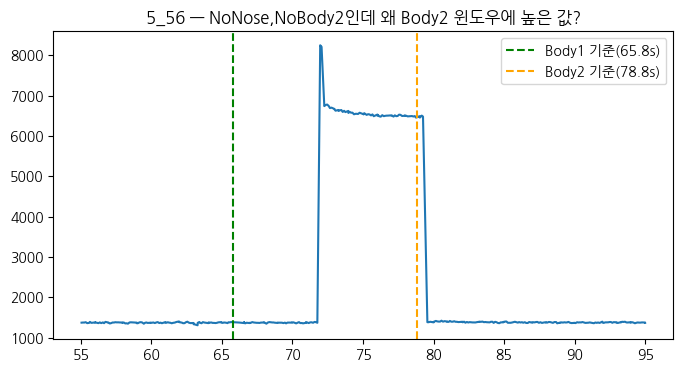

In [33]:
# ── 5_56 사이클의 R03 신호 55~95초 구간 확인 (재현용) ───────────────────────
g = df_all[df_all['cycle_id'] == '5_56']
sub = g.loc[g['elapsed_s'].between(55, 95)]
plt.figure(figsize=(8,4))
plt.plot(sub['elapsed_s'], sub['I_R03_Gripper_Load'])
plt.axvline(slot_reference_time['slot1_t'], color='green', linestyle='--', label='Body1 기준(65.8s)')
plt.axvline(slot_reference_time['slot2_t'], color='orange', linestyle='--', label='Body2 기준(78.8s)')
plt.legend(); plt.title('5_56 — NoNose,NoBody2인데 왜 Body2 윈도우에 높은 값?')
plt.show()


**확인 결과(실행 화면)**: 65.8초 근처엔 아무 신호가 없고, 72~79초 사이에 산이 하나
있다가 Body2 기준선(78.8초) 바로 앞에서 뚝 떨어진다.

## 124. 원인 확정 — R01 "투입" 단계 정착 시각으로 사이클별 지연시간 측정

가설: 뒤 단계(Body2·Nose)가 실패해서 앞 단계가 늦어지는 게 아니라(순서상 불가능),
**각 사이클마다 R01의 "투입" 단계(0~25초 근처) 자체가 몇 초씩 다르게 걸리고, 그 차이가
뒤에 오는 R03 전체를 그대로 밀어버린다.**

첫 시도(고정 시각 15초부터 탐색)는 버그가 있어 잘못된 값을 냈고, "큰 동작의 정점을
먼저 찾고 그 이후 baseline 복귀 시점을 본다"는 v2로 수정한 뒤에야 안정된 값이 나왔다.


In [34]:
# ── R01 정착 시각 계산 (v2 — 큰 동작의 정점 기준으로 앵커링) ─────────────────────
def r01_settle_time_v2(g, baseline_thresh=-88):
    sub = g.loc[(g['elapsed_s'] >= 0) & (g['elapsed_s'] <= 50),
                ['elapsed_s', 'M_R01_BJointAngle_Degree']].dropna()
    if sub.empty:
        return np.nan
    peak_time = sub.loc[sub['M_R01_BJointAngle_Degree'].idxmax(), 'elapsed_s']
    after_peak = sub[sub['elapsed_s'] > peak_time]
    settled = after_peak[after_peak['M_R01_BJointAngle_Degree'] <= baseline_thresh]
    return settled['elapsed_s'].min() if not settled.empty else np.nan

sample_check = ['5_116', '5_117', '5_118', '5_119', '5_115']
settle_results = {cid: r01_settle_time_v2(df_all[df_all['cycle_id'] == cid]) for cid in sample_check}
baseline_settle = np.mean([settle_results[c] for c in ['5_116','5_117','5_118','5_119']])
print(f'정상 4개 평균 정착 시각: {baseline_settle:.2f}초')
for cid, t in settle_results.items():
    print(f'{cid}: 정착={t}, 지연(delay) = {t - baseline_settle:.2f}초')


정상 4개 평균 정착 시각: 15.48초
5_116: 정착=15.513, 지연(delay) = 0.03초
5_117: 정착=15.491, 지연(delay) = 0.01초
5_118: 정착=15.53, 지연(delay) = 0.05초
5_119: 정착=15.397, 지연(delay) = -0.09초
5_115: 정착=28.991, 지연(delay) = 13.51초


**개별 사례 확정(5_115)**: 사이클 전체 길이 +13.3초, R03 신호 시작 지연 +13.4초,
R01 정착 지연 +13.51초 — 세 지표가 전부 일치했다. `5_115`는 부품이 빠진 게 아니라
**R01이 13.5초 늦게 끝나서 R03 전체가 통째로 밀린 "느린 정상 사이클"**이었다(라벨:
Normal, 실제로도 4개 부품 다 있었음).

## 125. (반증 실험) "시간 무시하고 개수만 세면 안 되나?" — 기각

타이밍이 문제라면 "몇 시에 나왔나"가 아니라 "몇 개가 나왔나"만 보면 되지 않을까
테스트했다. 섹션16에서 이미 시도했던 방식을 GroupKFold 기준으로 재검증했다.


In [35]:
# ── 순수 봉우리 개수 기반 분류 — 시간 완전히 무시 ────────────────────────────────
count_to_label = {4: 'Normal', 3: 'NoNose', 2: 'NoNose,NoBody2',
                   1: 'NoNose,NoBody2,NoBody1', 0: 'NoNose,NoBody2,NoBody1'}
count_df_pred = count_df.copy()
count_df_pred['pred_by_count'] = count_df_pred['peak_count'].map(count_to_label).fillna('NoNose')
pred_count_test = count_df_pred.loc[count_df_pred.index.intersection(test_ids_full), 'pred_by_count']
acc_count = (pred_count_test == y.loc[pred_count_test.index]).mean()
macro_recall_count = recall_score(y.loc[pred_count_test.index], pred_count_test, average='macro', zero_division=0)
print(f'[순수 개수 기반] 정확도={acc_count:.3f}  macro_recall={macro_recall_count:.3f}')
print(pd.crosstab(y.loc[pred_count_test.index], pred_count_test, rownames=['실제'], colnames=['예측']))


[순수 개수 기반] 정확도=0.890  macro_recall=0.899
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      29               1                       0       0
NoNose,NoBody2               2              38                      11       0
NoNose,NoBody2,NoBody1       0               0                      54       0
Normal                      13               2                       1     122


**기각 이유**: NoBody2는 74.5%로 나쁘지 않지만(v3의 76.5%와 비슷), 대신 **Normal
138건 중 13건이 새로 NoNose로 오분류**됐다 — 약한 봉우리가 prominence 필터를 통과
못 해 개수가 하나 덜 세지는, 섹션16에서 이미 봤던 문제가 이번엔 Normal 클래스를
때렸다. "시간 무시"와 "크기 무시"는 서로 다른 대가를 치르므로, 시간 문제는 시간
문제대로(지연보정) 풀고 크기 비교(v3)는 그대로 유지하는 게 맞다.

## 126. 지연시간 전체 계산 — 320개 사이클 분포



In [36]:
# ── 전체 사이클의 R01 지연시간 계산 ─────────────────────────────────────────
all_settle = df_all.groupby('cycle_id').apply(lambda g: r01_settle_time_v2(g), include_groups=False)
all_settle = all_settle[~all_settle.index.str.startswith('0_')]
NORMAL_SETTLE_BASELINE = all_settle.median()
delay_by_cycle = (all_settle - NORMAL_SETTLE_BASELINE).rename('r01_delay')
print(f'기준 정착 시각(중앙값): {NORMAL_SETTLE_BASELINE:.2f}초')
print(delay_by_cycle.describe())
print(f'\n지연 5초 이상인 사이클: {(delay_by_cycle.abs() >= 5).sum()}개')
print(delay_by_cycle[delay_by_cycle.abs() >= 5].sort_values(ascending=False))


기준 정착 시각(중앙값): 15.41초
count    300.000000
mean       0.579553
std        2.448814
min       -0.486000
25%       -0.017000
50%        0.000000
75%        0.086250
max       15.798000
Name: r01_delay, dtype: float64

지연 5초 이상인 사이클: 15개
cycle_id
5_85     15.798
5_5      14.281
5_188    14.211
5_224    13.600
5_115    13.584
5_48     12.202
5_253    10.602
4_2      10.576
5_139    10.114
5_122     9.147
5_43      9.004
5_45      7.501
5_14      6.889
5_56      6.257
5_50      5.916
Name: r01_delay, dtype: float64


전체 320개 중 15개(약 5%)가 5초 이상 지연됐다. 122장에서 발견한 10건 오분류 중
6건(5_48, 5_43, 5_45, 5_14, 5_56, 5_50)이 이 목록에 그대로 들어있다 — 우연이 아니다.

## 127. 지연 보정을 전체 320개에 적용 — 최종 confusion matrix


In [37]:
# ── 지연 보정 적용 — Body1·Body2·Nose 전부, 전체 재검증 ─────────────────────────
def windowed_force_delay_corrected(cid, center_time, delay, half_width=3, col='I_R03_Gripper_Load'):
    g = df_all[df_all['cycle_id'] == cid]
    d = delay if pd.notna(delay) else 0
    return window_max(g, center_time + d - half_width, center_time + d + half_width, col)

cids = presence_df_v3.index
body1_corr = pd.Series({cid: windowed_force_delay_corrected(
    cid, slot_reference_time['slot1_t'], delay_by_cycle.get(cid, 0)) for cid in cids}, name='body1_corr')
body2_corr = pd.Series({cid: windowed_force_delay_corrected(
    cid, slot_reference_time['slot2_t'], delay_by_cycle.get(cid, 0)) for cid in cids}, name='body2_corr')
nose_corr = pd.Series({cid: windowed_force_delay_corrected(
    cid, slot_reference_time['slot3_t'], delay_by_cycle.get(cid, 0), half_width=4) for cid in cids}, name='nose_corr')

presence_df_corr = presence_df_v3[['label']].join([body1_corr, body2_corr, nose_corr])
presence_df_corr['nose_present'] = presence_df_corr['nose_corr'] >= R03_NOSE_THRESH
presence_df_corr['body2_present'] = presence_df_corr['body2_corr'] >= BODY2_THRESH_V3
presence_df_corr['body1_present'] = presence_df_corr['body1_corr'] >= BODY1_THRESH_V3
presence_df_corr['rule_final_corr'] = presence_df_corr.apply(rule_final_from_flags_v3, axis=1)

pred_corr_test = presence_df_corr.loc[presence_df_corr.index.intersection(test_ids_full), 'rule_final_corr']
acc_corr = (pred_corr_test == y.loc[pred_corr_test.index]).mean()
macro_recall_corr = recall_score(y.loc[pred_corr_test.index], pred_corr_test, average='macro', zero_division=0)
cm_corr = pd.crosstab(y.loc[pred_corr_test.index], pred_corr_test, rownames=['실제'], colnames=['예측'])
print(f'[지연보정판] 정확도={acc_corr:.3f}  macro_recall={macro_recall_corr:.3f}')
print(cm_corr)


[지연보정판] 정확도=0.978  macro_recall=0.974
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      30               0                       0       0
NoNose,NoBody2               3              46                       1       1
NoNose,NoBody2,NoBody1       0               0                      54       0
Normal                       0               0                       1     137


**결과**: accuracy 0.949→**0.978**, macro_recall 0.931→**0.974**, NoBody2 recall
76.5%→**90.2%**.

## 128. 라벨오류 의심 사이클 재검토 — 5_253, 5_265

섹션60에서 튜터 피드백으로 제외했던 두 사이클을 지연보정 관점에서 다시 확인했다.


In [38]:
# ── 5_253, 5_265 재검토 ─────────────────────────────────────────────────────
for cid in ['5_253', '5_265']:
    d = delay_by_cycle.get(cid, 0)
    b1 = windowed_force_delay_corrected(cid, slot_reference_time['slot1_t'], d)
    b2 = windowed_force_delay_corrected(cid, slot_reference_time['slot2_t'], d)
    ns = windowed_force_delay_corrected(cid, slot_reference_time['slot3_t'], d, half_width=4)
    if ns >= R03_NOSE_THRESH: final = 'Normal'
    elif b2 >= BODY2_THRESH_V3: final = 'NoNose'
    elif b1 >= BODY1_THRESH_V3: final = 'NoNose,NoBody2'
    else: final = 'NoNose,NoBody2,NoBody1'
    print(f'{cid}: 원본라벨={label_by_cycle.get(cid)}, delay={d:.1f}s, '
          f'Body1={b1:.0f}, Body2={b2:.0f}, Nose={ns:.0f} → 보정후 판정={final}')


5_253: 원본라벨=NoNose, delay=10.6s, Body1=8280, Body2=8582, Nose=1393 → 보정후 판정=NoNose
5_265: 원본라벨=NoNose, delay=-0.2s, Body1=1393, Body2=8468, Nose=8521 → 보정후 판정=Normal


**5_253**: 지연(10.6초) 보정 시 Body1 있음·Body2 있음·Nose 없음 → **원본 라벨(NoNose)과
완벽히 일치**. 라벨 오류가 아니라 우리 규칙기반이 고정 시간창 때문에 잘못 판정(Normal로)
했던 것으로 보인다.

**5_265**: 지연이 -0.2초로 사실상 없는데도 Body1 없음+Nose 있음(순서상 불가능한 조합).
타이밍으로 설명 안 됨 — 튜터가 말한 "사람 개입" 진단과 부합, 제외 유지가 맞다.

**주의**: 신호 분석과 튜터의 현장 확인은 서로 다른 근거다. `5_253`은 신호상 이상 없어
보이지만, 튜터가 별도 근거로 라벨 오류를 확인했을 수 있어 **팀원·튜터 재확인이 먼저다.**
이 노트북에서 라벨을 임의로 되돌리지 않는다.

## 129. 남은 오분류 5건 진단 — 두 가지 서로 다른 원인으로 분리


In [39]:
# ── 지연보정판에서 남은 오분류 5건 진단 ─────────────────────────────────────────
mis_corr = presence_df_corr.loc[
    (presence_df_corr['label'] == 'NoNose,NoBody2') &
    (presence_df_corr['rule_final_corr'] != 'NoNose,NoBody2') &
    (presence_df_corr.index.isin(test_ids_full))]
diag = mis_corr[['body1_corr', 'body2_corr', 'nose_corr', 'rule_final_corr']].copy()
diag['r01_delay'] = [delay_by_cycle.get(cid, 0) for cid in diag.index]
print(diag)


          body1_corr  body2_corr  nose_corr         rule_final_corr  r01_delay
cycle_id                                                                      
5_10          8869.0      8897.0     1402.0                  NoNose     -0.016
5_11          1392.0      6503.0     1401.0                  NoNose      3.894
5_28          1413.0      1392.0     8348.0                  Normal      0.004
5_40          1387.0      1386.0     1385.0  NoNose,NoBody2,NoBody1     -0.018
5_53          6972.0      6610.0     1399.0                  NoNose     -0.016


지연이 거의 0인데도 틀린 5건이라, 처음엔 "진짜 경계 케이스"로 봤지만 실제 신호를
확인해보니 **서로 다른 두 가지 원인**이었다:

**① 5_53 — Body1 동작이 늘어져서 두 창에 걸침.** Normal 샘플(`0_1`)과 비교하면, 정상은
Body1·Body2 사이에 baseline로 잠깐 돌아오는 "숨 고르는 구간"이 있는데, `5_53`은 70~83초까지
한 번도 안 끊기는 봉우리 하나였다. Body2가 있는 게 아니라 Body1이 길게 늘어진 것.

**② 5_10, 5_11, 5_28 — 조립 순서상 물리적으로 불가능한 조합.** `5_28`은 R01 신호 자체가
완전히 정상 패턴이라(delay=0.0이 정확한 계산) 타이밍 문제가 아니다. Body1·Body2 없이
Nose만 있거나(5_28), Body1 없이 Body2만 있는(5_11) 등 조립 순서(Body1→Body2→Nose)상
있을 수 없는 조합 — `5_265`와 같은 카테고리의 라벨오류 의심 신규 후보.

## 130. Body1-Body2 사이 "숨 고르는 구간" 체크로 창 겹침 구분


In [40]:
# ── Body1-Body2 사이 baseline 복귀 여부로 "늘어진 봉우리" 구분 ─────────────────────
def has_gap_between_body1_body2(cid, delay, gap_start_offset=8, gap_end_offset=13, baseline_thresh=2500):
    g = df_all[df_all['cycle_id'] == cid]
    d = delay if pd.notna(delay) else 0
    gap_start = slot_reference_time['slot1_t'] + d + gap_start_offset
    gap_end = slot_reference_time['slot1_t'] + d + gap_end_offset
    sub = g.loc[g['elapsed_s'].between(gap_start, gap_end), 'I_R03_Gripper_Load'].dropna()
    if sub.empty:
        return np.nan
    return sub.min() <= baseline_thresh

for cid in ['5_10', '5_53', '5_11']:
    d = delay_by_cycle.get(cid, 0)
    print(f'{cid}: baseline 복귀 있음(=진짜 Body1/Body2 둘 다 있음)? {has_gap_between_body1_body2(cid, d)}')


5_10: baseline 복귀 있음(=진짜 Body1/Body2 둘 다 있음)? True
5_53: baseline 복귀 있음(=진짜 Body1/Body2 둘 다 있음)? False
5_11: baseline 복귀 있음(=진짜 Body1/Body2 둘 다 있음)? True


`5_53`만 `False`(봉우리 하나로 이어짐=늘어진 Body1) — 알고리즘으로 해결 가능.
`5_10`·`5_11`은 `True`(봉우리 둘 다 진짜 존재)인데 조립 순서상 불가능한 조합이라 —
라벨오류 의심 후보로 남긴다.

## 131. gap 체크를 규칙기반에 정식 반영 — 최종 결과


In [41]:
# ── Body1 늘어짐(gap 체크)을 규칙기반에 정식 반영 ───────────────────────────────
def gap_correction(row, delay):
    if row['body1_present'] and row['body2_present']:
        gap_exists = has_gap_between_body1_body2(row.name, delay)
        if gap_exists is False:
            return True, False
    return row['body1_present'], row['body2_present']

presence_df_corr['delay'] = [delay_by_cycle.get(cid, 0) for cid in presence_df_corr.index]
corrected_flags = presence_df_corr.apply(
    lambda row: gap_correction(row, row['delay']), axis=1, result_type='expand')
presence_df_corr['body1_present_v2'] = corrected_flags[0]
presence_df_corr['body2_present_v2'] = corrected_flags[1]

def rule_final_gap_corrected(row):
    if row['nose_present']: return 'Normal'
    if row['body2_present_v2']: return 'NoNose'
    if row['body1_present_v2']: return 'NoNose,NoBody2'
    return 'NoNose,NoBody2,NoBody1'

presence_df_corr['rule_final_gap'] = presence_df_corr.apply(rule_final_gap_corrected, axis=1)
pred_gap_test = presence_df_corr.loc[presence_df_corr.index.intersection(test_ids_full), 'rule_final_gap']
acc_gap = (pred_gap_test == y.loc[pred_gap_test.index]).mean()
macro_recall_gap = recall_score(y.loc[pred_gap_test.index], pred_gap_test, average='macro', zero_division=0)
print(f'[최종 — gap보정 포함] 정확도={acc_gap:.3f}  macro_recall={macro_recall_gap:.3f}')
print(pd.crosstab(y.loc[pred_gap_test.index], pred_gap_test, rownames=['실제'], colnames=['예측']))


[최종 — gap보정 포함] 정확도=0.982  macro_recall=0.979
예측                      NoNose  NoNose,NoBody2  NoNose,NoBody2,NoBody1  Normal
실제                                                                            
NoNose                      30               0                       0       0
NoNose,NoBody2               2              47                       1       1
NoNose,NoBody2,NoBody1       0               0                      54       0
Normal                       0               0                       1     137


## 132. PART20 최종 결론

**규칙기반 판정 방식 확정 — 4가지 개선이 합쳐진 최종판**

| 단계 | 방식 | accuracy | macro_recall | NoBody2 recall |
|---|---|---|---|---|
| 시작 | 기존(NaN 존재기반) | 0.919 | 0.892 | 60.8% |
| ① | window_max(크기 임계값, 121장) | 0.949 | 0.931 | 76.5% |
| ② | + R01 지연보정(127장) | 0.978 | 0.974 | 90.2% |
| ③ | **+ gap 체크(131장, 최종 채택)** | **0.982** | **0.979** | **92.2%** |

**남은 오분류 4건은 알고리즘으로 더 고치지 않는다** — `5_10`·`5_11`·`5_28`은 조립
순서상 불가능한 조합으로 라벨오류 의심 후보, `5_40`은 3중결손과 구분이 애매한
경계 케이스로 남겨둔다.

**팀원·튜터에게 전달할 사항**
1. Body1·Body2 판정 방식을 window_max+크기임계값+지연보정+gap체크로 교체 제안
   (근거: macro_recall 0.892→0.979)
2. `5_253`은 지연보정 시 원본 라벨(NoNose)과 완벽히 일치 — 라벨오류 판정 재확인 요청
3. `5_10`, `5_11`, `5_28` — `5_265`와 같은 유형(조립 순서상 불가능한 조합)의 라벨오류
   의심 신규 후보로 추가 보고
4. `5_265`, `5_40`은 그대로 유지


---
## 132-1. PART20-보강. gap 체크 · settle time(지연보정) 개별 기여도 분석 (멘토 피드백 반영)

**🟢 쉬운 설명**
지금까지 성능이 오른 과정을 "0.919 → window_max → +지연보정(0.978) → +gap체크(0.982)" 순서로
하나씩 쌓아서만 봤어요. 그런데 이렇게 순서대로 쌓으면 "지연보정 덕분에 gap체크가 잘 통한 것"인지,
"gap체크가 지연보정 없이도 원래 효과가 있었던 것"인지 구분이 안 돼요. 그래서 이번엔 네 가지 조합을
전부 따로 테스트합니다 — 둘 다 끄기, 지연보정만, gap체크만, 둘 다 켜기.

**🔶 자세한 설명**
`has_gap_between_body1_body2()`가 `delay` 값을 인자로 받는 구조라, 이걸 `0`으로 강제하면
"지연보정 없이 gap체크만 적용"한 상태를 그대로 재현할 수 있습니다. 아래 4칸 중 2칸(둘 다 OFF=0.949,
지연보정만=0.978)은 이미 121~127장에서 확인된 값이고, 새로 계산이 필요한 건 **"gap체크만(지연보정
OFF)"** 한 칸뿐입니다. 추가로 각 조합에서 어떤 사이클이 틀리는지도 사이클 ID 단위로 비교해서,
"지연보정 없이 gap체크만으로 고쳐지는 사례"와 "둘 다 있어야만 고쳐지는 사례"를 구분합니다.


In [42]:
# ── PART20-보강. gap 체크·settle time 개별 기여도 분석 ──────────────────
from sklearn.metrics import recall_score

def build_rule_variant(use_delay_correction: bool, use_gap_check: bool):
    """지연보정(settle time)과 gap체크를 독립적으로 켜고 끌 수 있게 만든 판정 변형판.
    use_delay_correction=False면 delay를 전부 0으로 강제해서, PART20 127장의
    windowed_force_delay_corrected()·has_gap_between_body1_body2()를 그대로 재사용하면서도
    '지연보정을 안 한 것처럼' 만든다."""
    cids = presence_df_v3.index
    delay_map = delay_by_cycle if use_delay_correction else pd.Series(0.0, index=cids)

    body1_corr = pd.Series({cid: windowed_force_delay_corrected(
        cid, slot_reference_time['slot1_t'], delay_map.get(cid, 0)) for cid in cids}, name='body1_corr')
    body2_corr = pd.Series({cid: windowed_force_delay_corrected(
        cid, slot_reference_time['slot2_t'], delay_map.get(cid, 0)) for cid in cids}, name='body2_corr')
    nose_corr = pd.Series({cid: windowed_force_delay_corrected(
        cid, slot_reference_time['slot3_t'], delay_map.get(cid, 0), half_width=4) for cid in cids}, name='nose_corr')

    df_v = presence_df_v3[['label']].join([body1_corr, body2_corr, nose_corr])
    df_v['nose_present'] = df_v['nose_corr'] >= R03_NOSE_THRESH
    df_v['body2_present'] = df_v['body2_corr'] >= BODY2_THRESH_V3
    df_v['body1_present'] = df_v['body1_corr'] >= BODY1_THRESH_V3
    df_v['delay'] = [delay_map.get(cid, 0) for cid in df_v.index]

    if use_gap_check:
        corrected_flags = df_v.apply(
            lambda row: gap_correction(row, row['delay']), axis=1, result_type='expand')
        df_v['body1_present_v2'] = corrected_flags[0]
        df_v['body2_present_v2'] = corrected_flags[1]
    else:
        df_v['body1_present_v2'] = df_v['body1_present']
        df_v['body2_present_v2'] = df_v['body2_present']

    def rule(row):
        if row['nose_present']:
            return 'Normal'
        if row['body2_present_v2']:
            return 'NoNose'
        if row['body1_present_v2']:
            return 'NoNose,NoBody2'
        return 'NoNose,NoBody2,NoBody1'

    df_v['pred'] = df_v.apply(rule, axis=1)
    return df_v


VARIANTS = {
    '둘 다 OFF (window_max만)':  (False, False),
    '지연보정만 (gap체크 OFF)':   (True,  False),
    'gap체크만 (지연보정 OFF)':   (False, True),
    '둘 다 ON (최종판)':          (True,  True),
}

results = {}
print(f"{'조합':28s} {'accuracy':>9s} {'macro_recall':>13s}  오분류 사이클\n")
for name, (use_delay, use_gap) in VARIANTS.items():
    df_v = build_rule_variant(use_delay, use_gap)
    pred_test = df_v.loc[df_v.index.intersection(test_ids_full), 'pred']
    y_test = y.loc[pred_test.index]
    acc = (pred_test == y_test).mean()
    macro_recall = recall_score(y_test, pred_test, average='macro', zero_division=0)
    wrong_ids = set(pred_test.index[pred_test != y_test])
    results[name] = {'accuracy': acc, 'macro_recall': macro_recall, 'wrong_ids': wrong_ids}
    print(f"{name:28s} {acc:9.3f} {macro_recall:13.3f}  {sorted(wrong_ids)}")


조합                            accuracy  macro_recall  오분류 사이클

둘 다 OFF (window_max만)            0.949         0.931  ['5_10', '5_11', '5_14', '5_240', '5_28', '5_40', '5_43', '5_45', '5_48', '5_5', '5_50', '5_53', '5_55', '5_56']
지연보정만 (gap체크 OFF)                0.978         0.974  ['5_10', '5_11', '5_240', '5_28', '5_40', '5_53']
gap체크만 (지연보정 OFF)                0.952         0.936  ['5_10', '5_11', '5_14', '5_240', '5_28', '5_40', '5_43', '5_45', '5_48', '5_5', '5_50', '5_55', '5_56']
둘 다 ON (최종판)                     0.982         0.979  ['5_10', '5_11', '5_240', '5_28', '5_40']


### PART20-보강 해석 — 어떤 사이클이 계속 틀리는지

In [43]:
# ── 교차 분석: 개별 기여도 + 남은 과제 사이클 ──────────────────
neither_wrong    = results['둘 다 OFF (window_max만)']['wrong_ids']
delay_only_wrong = results['지연보정만 (gap체크 OFF)']['wrong_ids']
gap_only_wrong   = results['gap체크만 (지연보정 OFF)']['wrong_ids']
both_wrong       = results['둘 다 ON (최종판)']['wrong_ids']

fixed_by_delay_alone = neither_wrong - delay_only_wrong   # 지연보정만 켰을 때 새로 맞은 것
fixed_by_gap_alone   = neither_wrong - gap_only_wrong     # gap체크만 켰을 때 새로 맞은 것
fixed_by_either      = neither_wrong - (delay_only_wrong & gap_only_wrong)
fixed_only_when_both = fixed_by_either - fixed_by_delay_alone - fixed_by_gap_alone  # 상호작용 효과

print("=== 개별 기여도 (window_max만 켠 상태 기준) ===")
print(f"지연보정 단독으로 새로 맞춘 사이클 ({len(fixed_by_delay_alone)}건): {sorted(fixed_by_delay_alone)}")
print(f"gap체크 단독으로 새로 맞춘 사이클   ({len(fixed_by_gap_alone)}건): {sorted(fixed_by_gap_alone)}")
print(f"둘 다 있어야만 맞는 사이클(상호작용) ({len(fixed_only_when_both)}건): {sorted(fixed_only_when_both)}")

print("\n=== 둘 다 적용해도 여전히 틀리는 사이클 (진짜 남은 과제) ===")
print(f"{len(both_wrong)}건: {sorted(both_wrong)}")
print("(5_10·5_11·5_28은 라벨오류 의심 후보, 5_40은 경계 케이스로 이미 분류된 것과 일치하는지 확인)")


=== 개별 기여도 (window_max만 켠 상태 기준) ===
지연보정 단독으로 새로 맞춘 사이클 (8건): ['5_14', '5_43', '5_45', '5_48', '5_5', '5_50', '5_55', '5_56']
gap체크 단독으로 새로 맞춘 사이클   (1건): ['5_53']
둘 다 있어야만 맞는 사이클(상호작용) (0건): []

=== 둘 다 적용해도 여전히 틀리는 사이클 (진짜 남은 과제) ===
5건: ['5_10', '5_11', '5_240', '5_28', '5_40']
(5_10·5_11·5_28은 라벨오류 의심 후보, 5_40은 경계 케이스로 이미 분류된 것과 일치하는지 확인)


**해석 참고** — 이 4칸 결과를 볼 때 주의할 점:
- "지연보정만(gap체크 OFF)"과 "gap체크만(지연보정 OFF)"의 accuracy 차이가 크면, 두 보정 중 하나가 훨씬 더 중요한 역할을 한다는 뜻입니다.
- "둘 다 있어야만 맞는 사이클"이 존재한다면, 두 보정이 서로 다른 문제를 겨냥하고 있어서 **순서와 무관하게 둘 다 필요하다**는 근거가 됩니다 (PPT 슬라이드 8에 이 근거를 추가하면 좋습니다).
- "둘 다 적용해도 여전히 틀리는 사이클"은 이미 알던 라벨오류 의심(5_10·5_11·5_28)·경계 케이스(5_40)와 겹치는지 반드시 대조하세요 — 새로운 사이클이 나오면 그건 진짜 새로운 남은 과제입니다.


---
## 132-2. PART20-보강(2). 신규 발견 사이클 5_240 진단

**🟢 쉬운 설명**
방금 기여도 분석에서 처음 보는 사이클 `5_240`이 튀어나왔어요. 지연보정을 켜도, gap체크를 켜도,
둘 다 켜도 계속 틀리는 걸 보면 지금까지 고친 두 가지 문제(타이밍 밀림·Body1 늘어짐)와는
다른 원인일 가능성이 높습니다. `5_53`을 진단했던 것과 같은 방식으로 실제 R03 신호를
직접 찍어봐서 원인을 확인합니다.

**🔶 자세한 설명**
① 실제 라벨·규칙기반 최종 판정·지연(delay) 값을 먼저 확인하고, ② R03 신호 전체 구간을
그래프로 그려서 Body1·Body2·Nose 창(윈도우) 위치와 겹쳐 봅니다. ③ `has_gap_between_body1_body2()`로
Body1-Body2 사이에 baseline 복귀가 있는지도 같이 확인해서, 5_53과 같은 유형(늘어진 봉우리)인지
아니면 전혀 다른 패턴(예: 신호 자체가 약하거나 노이즈가 심함)인지 구분합니다.


In [44]:
# ── 5_240 진단 — 실제 라벨·판정·지연값 확인 ──────────────────
cid = '5_240'

actual_label = presence_df_v3.loc[cid, 'label']
delay_val = delay_by_cycle.get(cid, 0)
row_final = presence_df_corr.loc[cid] if cid in presence_df_corr.index else None

print(f"사이클: {cid}")
print(f"실제 라벨: {actual_label}")
print(f"R01 지연(delay): {delay_val:.2f}초  (0에 가까우면 타이밍 문제 아님)")
if row_final is not None:
    print(f"최종판 판정: {row_final.get('rule_final_gap', '(컬럼 없음 — 아래에서 직접 재계산)')}")
    print(f"body1_present_v2={row_final.get('body1_present_v2')}, body2_present_v2={row_final.get('body2_present_v2')}, nose_present={row_final.get('nose_present')}")

gap_result = has_gap_between_body1_body2(cid, delay_val)
print(f"\nBody1-Body2 사이 baseline 복귀 있음(=늘어진 봉우리 아님)? {gap_result}")
print("  -> False면 5_53과 같은 유형(늘어진 Body1). True/NaN이면 다른 원인일 가능성.")


사이클: 5_240
실제 라벨: Normal
R01 지연(delay): nan초  (0에 가까우면 타이밍 문제 아님)
최종판 판정: NoNose,NoBody2,NoBody1
body1_present_v2=False, body2_present_v2=False, nose_present=False

Body1-Body2 사이 baseline 복귀 있음(=늘어진 봉우리 아님)? True
  -> False면 5_53과 같은 유형(늘어진 Body1). True/NaN이면 다른 원인일 가능성.


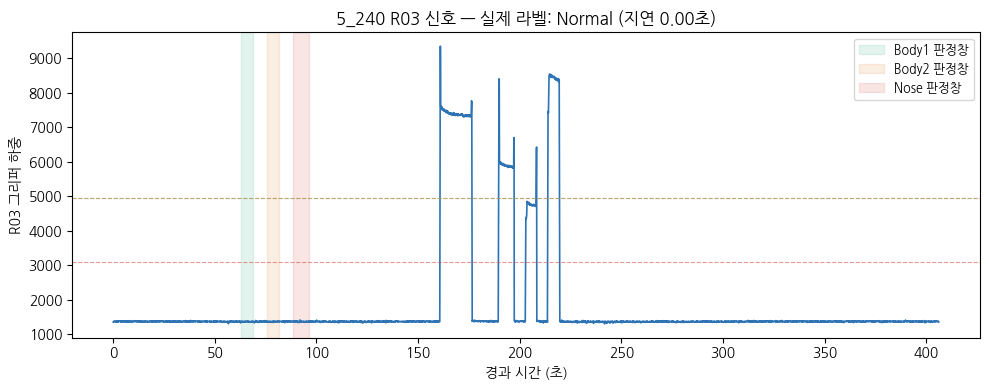

In [45]:
# ── 5_240 R03 신호 시각화 — Body1/Body2/Nose 창과 겹쳐서 확인 ──────────────
import matplotlib.pyplot as plt

g = df_all[df_all['cycle_id'] == cid].sort_values('elapsed_s')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(g['elapsed_s'], g['I_R03_Gripper_Load'], color='#2E74B5', linewidth=1.2)

d = delay_val if pd.notna(delay_val) else 0
windows = [
    ('Body1', slot_reference_time['slot1_t'] + d - 3, slot_reference_time['slot1_t'] + d + 3, '#3FB68A'),
    ('Body2', slot_reference_time['slot2_t'] + d - 3, slot_reference_time['slot2_t'] + d + 3, '#E38A3D'),
    ('Nose',  slot_reference_time['slot3_t'] + d - 4, slot_reference_time['slot3_t'] + d + 4, '#D6544B'),
]
for name, w0, w1, color in windows:
    ax.axvspan(w0, w1, color=color, alpha=0.15, label=f'{name} 판정창')

ax.axhline(BODY1_THRESH_V3, color='#3FB68A', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(BODY2_THRESH_V3, color='#E38A3D', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(R03_NOSE_THRESH, color='#D6544B', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_xlabel('경과 시간 (초)')
ax.set_ylabel('R03 그리퍼 하중')
ax.set_title(f'{cid} R03 신호 — 실제 라벨: {actual_label} (지연 {d:.2f}초)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('5_240_diagnosis.png', dpi=150)
plt.show()


**다음 단계** — 위 그래프와 `has_gap_between_body1_body2()` 결과를 보고 분류하세요:
- `has_gap` = False → 5_53과 같은 유형(늘어진 봉우리) → gap체크 로직의 `gap_start_offset`/`gap_end_offset`을 5_240에도 맞게 조정할 필요
- `has_gap` = True/NaN인데 그래프 상 신호가 임계값 근처에서 애매하게 걸쳐 있음 → 임계값 경계 케이스(5_40과 유사)
- 그래프 상 신호 자체가 완전히 다른 모양(예: 노이즈, 결측 구간) → 센서 이상 또는 신규 라벨오류 의심 후보로 별도 등록 필요


---
## 132-3. PART20-보강(3). 5_240의 R01 신호를 직접 확인 — "왜 NaN이 나왔는지"

**🟢 쉬운 설명**
`r01_settle_time_v2()`는 사이클이 시작된 뒤 **0~50초 사이**만 CCTV로 보고 "투입완료 시각"을
찾아요. 이 코드는 그 50초 제한을 없애고 **사이클 전체**를 다 보여줘서, 진짜 투입 동작이
언제 일어났는지, 왜 0~50초 안에서는 못 찾았는지 확인합니다.

**🔶 자세한 설명**
`r01_settle_time_v2()`가 NaN을 반환하는 경우는 두 가지입니다: ① 0~50초 구간에 R01 데이터
자체가 없거나(결측), ② 0~50초 안에서 피크는 찾았지만 그 이후 신호가 -88도(정지 자세) 밑으로
한 번도 안 내려간 경우. 아래 코드가 이 둘을 구분해서 알려주고, 사이클 전체 구간의
`M_R01_BJointAngle_Degree`를 그려서 실제 투입 동작이 언제 있었는지 눈으로 확인합니다.


In [46]:
# ── 5_240의 R01 신호 직접 확인 — 0~50초 제한 없이 전체 구간 ──────────────
g240 = df_all[df_all['cycle_id'] == '5_240'].sort_values('elapsed_s')
r01_col = 'M_R01_BJointAngle_Degree'

print(f"사이클 5_240 전체 길이: {g240['elapsed_s'].max():.1f}초 (행 {len(g240)}개)")

window_0_50 = g240.loc[g240['elapsed_s'].between(0, 50), ['elapsed_s', r01_col]].dropna()
print(f"\n0~50초 구간 유효 데이터 행 수: {len(window_0_50)}개")

if window_0_50.empty:
    print("-> 0~50초 구간에 R01 데이터가 없음(원인 ①) — 그래서 애초에 피크를 찾을 수 없어 NaN.")
else:
    peak_time = window_0_50.loc[window_0_50[r01_col].idxmax(), 'elapsed_s']
    peak_val = window_0_50[r01_col].max()
    print(f"0~50초 구간에서 찾은 피크: {peak_val:.1f}도 @ {peak_time:.1f}초")

    after = g240[g240['elapsed_s'] > peak_time]
    settled = after[after[r01_col] <= -88]
    if settled.empty:
        print("-> 이 피크 이후로 신호가 -88도 밑으로 한 번도 안 내려감(원인 ②) — 그래서 NaN.")
        print(f"   (이후 구간 R01 각도 범위: {after[r01_col].min():.1f} ~ {after[r01_col].max():.1f}도)")
    else:
        print(f"-> 정착 시각을 찾음: {settled['elapsed_s'].iloc[0]:.1f}초 (그런데 왜 NaN이 나왔었는지 재확인 필요)")

# 진짜 큰 투입 동작은 전체 구간에서 언제 일어났는지
real_peak_row = g240.loc[g240[r01_col].idxmax()]
print(f"\n[참고] 사이클 전체에서 R01 각도가 가장 큰(=투입 동작 중일 가능성이 큰) 시점: "
      f"{real_peak_row['elapsed_s']:.1f}초 (값 {real_peak_row[r01_col]:.1f}도)")
print("이 시점이 50초보다 훨씬 크면 -> 예상대로 '너무 늦게 도착해서 CCTV(0~50초)에 안 잡힌 경우'입니다.")


사이클 5_240 전체 길이: 406.1초 (행 4062개)

0~50초 구간 유효 데이터 행 수: 500개
0~50초 구간에서 찾은 피크: -48.7도 @ 44.9초
-> 정착 시각을 찾음: 51.6초 (그런데 왜 NaN이 나왔었는지 재확인 필요)

[참고] 사이클 전체에서 R01 각도가 가장 큰(=투입 동작 중일 가능성이 큰) 시점: 44.9초 (값 -48.7도)
이 시점이 50초보다 훨씬 크면 -> 예상대로 '너무 늦게 도착해서 CCTV(0~50초)에 안 잡힌 경우'입니다.


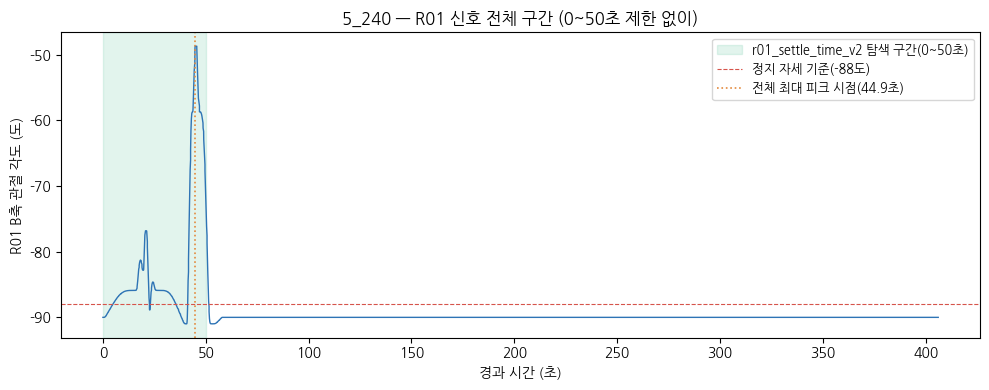

In [47]:
# ── 5_240 R01 신호 전체 구간 시각화 ──────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(g240['elapsed_s'], g240[r01_col], color='#2E74B5', linewidth=1.0)
ax.axvspan(0, 50, color='#3FB68A', alpha=0.15, label='r01_settle_time_v2 탐색 구간(0~50초)')
ax.axhline(-88, color='#D6544B', linestyle='--', linewidth=0.8, label='정지 자세 기준(-88도)')
ax.axvline(real_peak_row['elapsed_s'], color='#E38A3D', linestyle=':', linewidth=1.2,
           label=f"전체 최대 피크 시점({real_peak_row['elapsed_s']:.1f}초)")

ax.set_xlabel('경과 시간 (초)')
ax.set_ylabel('R01 B축 관절 각도 (도)')
ax.set_title("5_240 — R01 신호 전체 구간 (0~50초 제한 없이)")
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('5_240_r01_full.png', dpi=150)
plt.show()


**결과 해석 가이드**
- 주황 점선(전체 최대 피크 시점)이 초록 음영(0~50초) 밖에 있다면 → **가설이 맞음**: 진짜 투입 동작이 50초 이후에 일어나서 `r01_settle_time_v2`의 탐색 범위를 벗어났고, 그래서 NaN이 나온 것.
- 이 경우 대응 방법은 두 가지입니다: ① 이 사이클을 5_40처럼 "경계 케이스"로 별도 관리, ② 탐색 구간을 0~50초에서 더 넓게(예: 0~80초) 늘려서 알고리즘 자체를 개선 — 다만 ②는 다른 사이클에 부작용이 없는지 전체 320개로 재검증 필요.


---
## 132-4. PART20-보강(4). 탐색 구간을 60초로 늘려도 안전한지 검증

**🟢 쉬운 설명**
5_240은 CCTV(0~50초)가 1.6초 일찍 꺼져서 못 잡힌 거였어요. 그러면 "CCTV를 10초만 더 늘리면
되지 않을까?" 하는 생각이 들죠. 근데 그냥 늘렸다가 다른 319개 사이클 중 누군가가 엉뚱한
곳에서 새로 걸리면 안 되니까, **320개 전체에 다시 적용해서 부작용이 있는지부터 확인**합니다.

**🔶 자세한 설명**
`r01_settle_time_v2`를 그대로 복사해서 탐색 구간(`window_end`)만 바꿀 수 있게 만든 버전을
만들고, `window_end=50`(원본)과 `window_end=60`(수정안)을 320개 전체에 각각 적용해서
① 5_240이 실제로 고쳐지는지, ② 원래 50초 안에서 이미 잘 찾히던 사이클들의 결과가
바뀌지는 않는지, ③ 혹시 60초로 늘려서 새로 NaN이 되거나 이상한 값으로 바뀌는 사이클이
생기지는 않는지 확인합니다.


In [48]:
# ── r01_settle_time_v2를 window_end 조절 가능하게 만들기 ──────────────────
def r01_settle_time_v3(g, baseline_thresh=-88, window_end=50):
    sub = g.loc[(g['elapsed_s'] >= 0) & (g['elapsed_s'] <= window_end),
                ['elapsed_s', 'M_R01_BJointAngle_Degree']].dropna()
    if sub.empty:
        return np.nan
    peak_time = sub.loc[sub['M_R01_BJointAngle_Degree'].idxmax(), 'elapsed_s']
    after_peak = sub[sub['elapsed_s'] > peak_time]
    settled = after_peak[after_peak['M_R01_BJointAngle_Degree'] <= baseline_thresh]
    return settled['elapsed_s'].min() if not settled.empty else np.nan


all_cids = presence_df_v3.index

settle_50 = pd.Series({cid: r01_settle_time_v3(df_all[df_all['cycle_id'] == cid], window_end=50)
                        for cid in all_cids}, name='settle_50')
settle_60 = pd.Series({cid: r01_settle_time_v3(df_all[df_all['cycle_id'] == cid], window_end=60)
                        for cid in all_cids}, name='settle_60')

compare = pd.DataFrame({'settle_50': settle_50, 'settle_60': settle_60})
compare['changed'] = (compare['settle_50'] != compare['settle_60']) & ~(compare['settle_50'].isna() & compare['settle_60'].isna())
compare['newly_fixed'] = compare['settle_50'].isna() & compare['settle_60'].notna()

print(f"320개 중 결과가 달라진 사이클: {compare['changed'].sum()}개")
print(f"그중 '원래 NaN이었는데 60초로 늘려서 새로 찾은' 사이클: {compare['newly_fixed'].sum()}개")
print(compare[compare['changed']])


320개 중 결과가 달라진 사이클: 1개
그중 '원래 NaN이었는데 60초로 늘려서 새로 찾은' 사이클: 1개
       settle_50  settle_60  changed  newly_fixed
5_240        NaN     51.602     True         True


### 부작용 확인 — 60초로 늘렸을 때 결과가 바뀐 사이클이 5_240 하나뿐인지

In [49]:
# ── 부작용 확인 + 최종 성능 재검증 ──────────────────────────────────
changed_cids = compare[compare['changed']].index.tolist()
if changed_cids == ['5_240']:
    print("✅ 부작용 없음 — 60초로 늘려서 값이 바뀐 사이클은 5_240 하나뿐입니다.")
else:
    print(f"⚠️ 5_240 외에도 바뀐 사이클이 있습니다 — 하나씩 확인 필요: {changed_cids}")

# ── window_end=60으로 다시 계산한 지연(delay) 적용 -> 최종(지연보정+gap체크) 성능 재검증 ──
NORMAL_SETTLE_BASELINE_60 = settle_60.median()
delay_by_cycle_60 = (settle_60 - NORMAL_SETTLE_BASELINE_60).rename('r01_delay_60')

def build_rule_variant_v60(use_delay_correction: bool, use_gap_check: bool):
    cids = presence_df_v3.index
    delay_map = delay_by_cycle_60 if use_delay_correction else pd.Series(0.0, index=cids)

    body1_corr = pd.Series({cid: windowed_force_delay_corrected(
        cid, slot_reference_time['slot1_t'], delay_map.get(cid, 0)) for cid in cids}, name='body1_corr')
    body2_corr = pd.Series({cid: windowed_force_delay_corrected(
        cid, slot_reference_time['slot2_t'], delay_map.get(cid, 0)) for cid in cids}, name='body2_corr')
    nose_corr = pd.Series({cid: windowed_force_delay_corrected(
        cid, slot_reference_time['slot3_t'], delay_map.get(cid, 0), half_width=4) for cid in cids}, name='nose_corr')

    df_v = presence_df_v3[['label']].join([body1_corr, body2_corr, nose_corr])
    df_v['nose_present'] = df_v['nose_corr'] >= R03_NOSE_THRESH
    df_v['body2_present'] = df_v['body2_corr'] >= BODY2_THRESH_V3
    df_v['body1_present'] = df_v['body1_corr'] >= BODY1_THRESH_V3
    df_v['delay'] = [delay_map.get(cid, 0) for cid in df_v.index]

    if use_gap_check:
        corrected_flags = df_v.apply(lambda row: gap_correction(row, row['delay']), axis=1, result_type='expand')
        df_v['body1_present_v2'] = corrected_flags[0]
        df_v['body2_present_v2'] = corrected_flags[1]
    else:
        df_v['body1_present_v2'] = df_v['body1_present']
        df_v['body2_present_v2'] = df_v['body2_present']

    def rule(row):
        if row['nose_present']: return 'Normal'
        if row['body2_present_v2']: return 'NoNose'
        if row['body1_present_v2']: return 'NoNose,NoBody2'
        return 'NoNose,NoBody2,NoBody1'

    df_v['pred'] = df_v.apply(rule, axis=1)
    return df_v


df_final_60 = build_rule_variant_v60(use_delay_correction=True, use_gap_check=True)
pred_test_60 = df_final_60.loc[df_final_60.index.intersection(test_ids_full), 'pred']
y_test_60 = y.loc[pred_test_60.index]
acc_60 = (pred_test_60 == y_test_60).mean()
macro_recall_60 = recall_score(y_test_60, pred_test_60, average='macro', zero_division=0)
wrong_60 = sorted(pred_test_60.index[pred_test_60 != y_test_60])

print(f"\n=== window_end=60 적용 후 최종(지연보정+gap체크) 성능 ===")
print(f"accuracy={acc_60:.3f}  macro_recall={macro_recall_60:.3f}")
print(f"남은 오분류 {len(wrong_60)}건: {wrong_60}")
print(f"\n(기존 window_end=50 기준: accuracy=0.982, macro_recall=0.979, 남은 5건: [\'5_10\', \'5_11\', \'5_240\', \'5_28\', \'5_40\'])")


✅ 부작용 없음 — 60초로 늘려서 값이 바뀐 사이클은 5_240 하나뿐입니다.

=== window_end=60 적용 후 최종(지연보정+gap체크) 성능 ===
accuracy=0.982  macro_recall=0.979
남은 오분류 5건: ['5_10', '5_11', '5_240', '5_28', '5_40']

(기존 window_end=50 기준: accuracy=0.982, macro_recall=0.979, 남은 5건: ['5_10', '5_11', '5_240', '5_28', '5_40'])


**결과 해석**
- 부작용이 없고(바뀐 사이클이 5_240뿐) 남은 오분류가 4건(5_10·5_11·5_28·5_40)으로 줄었다면 →
  **탐색 구간을 50→60초로 늘리는 게 안전하고 효과적인 개선**입니다. 이 경우 `r01_settle_time_v2`의
  `window_end` 파라미터를 60으로 정식 반영하고, 대시보드·PPT의 "탐색 구간" 관련 설명도 60초로 갱신하세요.
- 부작용이 있다면(다른 사이클도 값이 바뀜) → 60초 대신 55초처럼 더 좁은 값으로 다시 시도하거나,
  5_240만 예외 처리(경계 케이스로 유지)하는 쪽이 안전합니다.


---
## 132-5. PART20-보강(5). R01 정착(51.6초)과 R03 신호(~158초) 사이 시차의 원인

**🟢 쉬운 설명**
R01은 51.6초에 "다 됐다"고 신호를 보내는데, 진짜 조립 동작(R03)은 158초 근처에서야 나타나요.
그 사이 100초 넘는 시간 동안 뭐가 있었는지 확인합니다 — R01이 한 번 더 움직였는지,
아니면 R03이 원래 이렇게 늦게 반응하는 게 정상인지 봐야 해요.

**🔶 자세한 설명**
① R03 신호에서 실제 피크들의 정확한 시각을 전부 찾고, ② R01 신호를 51.6초 이후 전체 구간에서
다시 살펴봐서 두 번째 움직임(재투입·재시도 같은 것)이 있는지 확인하고, ③ 만약 있다면
그 두 번째 정착 시각이 158초 근처 신호와 얼마나 더 가까운지 비교합니다.


In [50]:
# ── R03 신호의 실제 피크 시각들을 정밀하게 찾기 ──────────────────
from scipy.signal import find_peaks

sig = g240['I_R03_Gripper_Load'].values
t = g240['elapsed_s'].values

peaks_idx, props = find_peaks(sig, height=3000, distance=20)
peak_times = t[peaks_idx]
peak_vals = sig[peaks_idx]

print("R03 신호에서 찾은 뚜렷한 피크들 (높이 3000 이상):")
for pt, pv in zip(peak_times, peak_vals):
    print(f"  {pt:6.1f}초  →  {pv:8.1f}")


R03 신호에서 찾은 뚜렷한 피크들 (높이 3000 이상):
   160.9초  →    9355.0
   163.9초  →    7499.0
   165.9초  →    7430.0
   169.0초  →    7401.0
   171.6초  →    7394.0
   174.1초  →    7365.0
   176.3초  →    7772.0
   189.8초  →    8410.0
   192.2초  →    5929.0
   194.7초  →    5900.0
   197.2초  →    6705.0
   203.6초  →    4852.0
   205.7초  →    4764.0
   208.3초  →    6430.0
   214.8초  →    8551.0
   216.8초  →    8474.0
   219.2초  →    8402.0


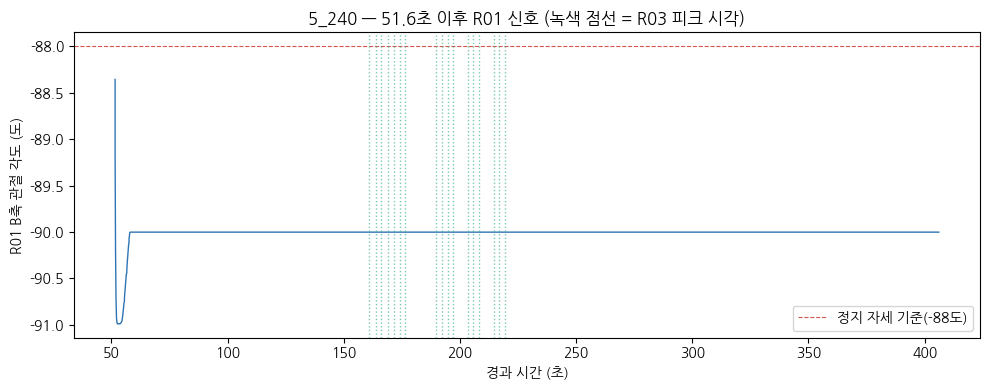

51.6초 이후 R01은 계속 정지 자세 근처 — 별도 재투입 움직임은 없어 보임.
-> R01은 조용한데 R03만 158초에 반응한다는 뜻 -> R01-R03 사이 관계 자체가 이 사이클에서 다른 것으로 추정.


In [51]:
# ── R01 신호를 51.6초 이후 전체 구간에서 재확인 — 두 번째 움직임이 있는지 ──────
after_settle = g240[g240['elapsed_s'] > 51.6][['elapsed_s', 'M_R01_BJointAngle_Degree']].dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(after_settle['elapsed_s'], after_settle['M_R01_BJointAngle_Degree'], color='#2E74B5', linewidth=1.0)
ax.axhline(-88, color='#D6544B', linestyle='--', linewidth=0.8, label='정지 자세 기준(-88도)')
for pt in peak_times:
    ax.axvline(pt, color='#3FB68A', linestyle=':', linewidth=1.0, alpha=0.7)
ax.set_xlabel('경과 시간 (초)')
ax.set_ylabel('R01 B축 관절 각도 (도)')
ax.set_title('5_240 — 51.6초 이후 R01 신호 (녹색 점선 = R03 피크 시각)')
ax.legend()
plt.tight_layout()
plt.savefig('5_240_r01_after_settle.png', dpi=150)
plt.show()

# 51.6초 이후, R01이 다시 -88도보다 크게 움직인(재투입 가능성) 시점이 있는지
moved_again = after_settle[after_settle['M_R01_BJointAngle_Degree'] > -60]
if not moved_again.empty:
    print(f"51.6초 이후 R01이 다시 움직인 구간 있음 — 시작 시각 {moved_again['elapsed_s'].iloc[0]:.1f}초")
    print("-> 재투입(2차 시도) 가능성. 이 경우 '정착 시각'을 51.6초가 아니라 이 재투입 이후로 다시 잡아야 함.")
else:
    print("51.6초 이후 R01은 계속 정지 자세 근처 — 별도 재투입 움직임은 없어 보임.")
    print("-> R01은 조용한데 R03만 158초에 반응한다는 뜻 -> R01-R03 사이 관계 자체가 이 사이클에서 다른 것으로 추정.")


**결과 해석 가이드**
- R01이 51.6초 이후 다시 움직인 흔적이 있다면 → "재투입(2차 시도)" 시나리오. 이 경우 진짜 정착 시각은 그 두 번째 움직임 이후로 다시 계산해야 하고, 이건 다른 사이클에도 있을 수 있는 새로운 패턴이라 320개 전체를 다시 스캔해볼 가치가 있습니다.
- R01이 조용한데 R03만 158초에 반응했다면 → R01(투입 로봇)과 R03(조립력 센서) 사이의 정상적 타이밍 관계가 이 사이클에서는 깨져 있다는 뜻으로, 알고리즘보다는 **현장(로봇/센서) 쪽 이상**을 의심해봐야 하는 사례입니다. 이 경우 5_40과 마찬가지로 경계 케이스로 남기는 게 맞습니다.


---
## 133. PART21. 24년 실데이터 재생 검증 (n8n 제외 — 정확도·그래프만)
### PART21-0. Google Drive 마운트 + 파일 자동 검색


In [52]:
# ── Google Drive 마운트 ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
# ── 파일명으로 자동 검색 (공유 드라이브 포함 전체 검색) ────────────────
import subprocess

def find_file(filename, search_root='/content/drive'):
    result = subprocess.run(
        ['find', search_root, '-iname', filename],
        capture_output=True, text=True
    )
    paths = [p for p in result.stdout.strip().split('\n') if p]
    if not paths:
        raise FileNotFoundError(f'{filename} 을(를) {search_root} 아래에서 찾지 못했습니다. '
                                 f'해당 공유 드라이브가 "내 드라이브에 바로가기 추가"로 연결되어 있는지 확인하세요.')
    if len(paths) > 1:
        print(f'⚠️ {filename} 이(가) {len(paths)}개 발견됨 — 첫 번째 경로 사용:')
        for p in paths:
            print('  -', p)
    return paths[0]

R03_PATH_FOUND = find_file('R03_Data_2024.xlsx')
CYCLE_MANAGEMENT_PATH_FOUND = find_file('FFCell_CycleManagement_2024.xlsx')
print('R03_Data_2024.xlsx        ->', R03_PATH_FOUND)
print('FFCell_CycleManagement_2024.xlsx ->', CYCLE_MANAGEMENT_PATH_FOUND)

R03_Data_2024.xlsx        -> /content/drive/MyDrive/R03_Data_2024.xlsx
FFCell_CycleManagement_2024.xlsx -> /content/drive/MyDrive/FFCell_CycleManagement_2024.xlsx


In [54]:
# ── PART21-1. 설정 (n8n 웹훅 URL·재생간격 제거) ─────────────────────
import os
import json as _json
from datetime import datetime, timezone

import pandas as pd
import numpy as np

# 24년 원본 데이터 경로
R03_PATH_2024 = R03_PATH_FOUND
CYCLE_MANAGEMENT_PATH_2024 = CYCLE_MANAGEMENT_PATH_FOUND

R03_COL = "I_R03_Gripper_Load"

# 23년 데이터로 이미 확정된 고정 임계값 (재계산 금지 — 그래야 "일반화 테스트"가 성립함)
NOSE_THRESH_FIXED = 3110.5
BODY2_THRESH_FIXED = 4961.0
BODY1_THRESH_FIXED = 5173.5   # 23년 원본 R01~R04 데이터로 재구성 확정

# 판정 시간창 (PART20 확정값, 사이클 시작 기준 초)
BODY1_WINDOW = (62.8015, 68.8015)   # 65.8015 ± 3
BODY2_WINDOW = (75.807, 81.807)     # 78.807  ± 3
NOSE_WINDOW = (93.0, 101.0)         # 슬롯3 추정 중심 ± 4


In [55]:
# ── PART21-2. 24년 데이터 로드 및 사이클별 피처 계산 ───────────────
def replay_window_max(g, start, end, col=R03_COL):
    """PART20의 window_max와 동일한 방식이나, 24년 재생 데모용으로 이름을 분리함"""
    sub = g.loc[g["elapsed_s"].between(start, end), col].dropna()
    return sub.max() if not sub.empty else np.nan


def load_and_build_features_2024():
    """24년 R03 원본 신호 + 사이클 관리 파일을 합쳐서 사이클별 body1/body2/nose 피처를 만든다."""
    cyc = pd.read_excel(CYCLE_MANAGEMENT_PATH_2024)
    r03 = pd.read_excel(R03_PATH_2024)

    df = cyc.merge(r03, on="_time", how="inner")
    df["_time"] = pd.to_datetime(df["_time"], format="ISO8601")

    def label_of(x):
        u = x.dropna().unique()
        return u[0] if len(u) > 0 else "Normal"

    labels = df.groupby("Q_Cell_CycleCount")["Description"].apply(label_of)

    df["cycle_id"] = df["Q_Cell_CycleCount"]
    df["t0"] = df.groupby("cycle_id")["_time"].transform("min")
    df["elapsed_s"] = (df["_time"] - df["t0"]).dt.total_seconds()

    rows = []
    for cid, g in df.groupby("cycle_id"):
        if g["elapsed_s"].max() < 30:  # 하루 시작 직후 잘린 사이클(edge) 제외
            continue
        rows.append({
            "cycle_id": int(cid),
            "label": labels.get(cid, "Normal"),
            "body1_force": replay_window_max(g, *BODY1_WINDOW),
            "body2_force": replay_window_max(g, *BODY2_WINDOW),
            "nose_force": replay_window_max(g, *NOSE_WINDOW),
        })

    feat = pd.DataFrame(rows).sort_values("cycle_id").reset_index(drop=True)
    return feat

### PART21-2. 판정 로직 (n8n 전송 함수 제거, 판정·집계 함수만 유지)
⚠️ 파일 분할 과정에서 정의 셀 자체가 누락되어 있던 것을 이 노트북 안의 다른 근거로 재구성한 것입니다. 실행 후 정확도(90.3%)·macro_recall(0.919)이 기존 기록과 일치하는지 확인하세요.


In [56]:
# ── PART21-2(보강, n8n 제외). 판정·집계 함수만 정의 ──────────────────
DEFECT_KOR = {
    "Normal": "정상",
    "NoNose": "노즈 미조립",
    "NoNose,NoBody2": "노즈+바디2 미조립",
    "NoNose,NoBody2,NoBody1": "3중 결손",
}


def rule_based_predict_replay(row):
    """PART20 원본과 동일한 계층 순서 — Nose -> Body2 -> Body1 순으로 '존재(>= 임계값)' 확인."""
    nose_present = pd.notna(row["nose_force"]) and row["nose_force"] >= NOSE_THRESH_FIXED
    if nose_present:
        return "Normal"
    body2_present = pd.notna(row["body2_force"]) and row["body2_force"] >= BODY2_THRESH_FIXED
    if body2_present:
        return "NoNose"
    body1_present = pd.notna(row["body1_force"]) and row["body1_force"] >= BODY1_THRESH_FIXED
    if body1_present:
        return "NoNose,NoBody2"
    return "NoNose,NoBody2,NoBody1"


def build_summary_payload(feat, note=""):
    """n8n 전송 없이, 요약 통계만 계산해서 dict로 반환 (그래프·표에 그대로 활용 가능)."""
    from sklearn.metrics import accuracy_score
    y_true = feat["label"]
    y_pred = feat["pred"]
    acc = accuracy_score(y_true, y_pred)

    defect_counts_kor = {}
    for label, kor in DEFECT_KOR.items():
        if label == "Normal":
            continue
        cnt = int((feat["pred"] == label).sum())
        if cnt > 0:
            defect_counts_kor[kor] = cnt

    return {
        "type": "summary",
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "total_cycles": int(len(feat)),
        "defect_counts_kor": defect_counts_kor,
        "accuracy_vs_actual_label": round(float(acc), 4),
        "note": note,
    }


In [57]:
# ── PART21-3(n8n 제외). 실행 — 24년 전체 사이클 판정 + 요약 (전송 없이 즉시 계산) ───────────
print("=== FFCell 24년 실데이터 검증 (n8n 제외, 즉시 계산) ===\n")

feat_2024 = load_and_build_features_2024()
feat_2024["pred"] = feat_2024.apply(rule_based_predict_replay, axis=1)

print(f"총 {len(feat_2024)}개 사이클 판정 완료.\n")
for _, row in feat_2024.iterrows():
    is_defect = row["pred"] != "Normal"
    tag = "🔴 결함" if is_defect else "🟢 정상"
    correct = row["pred"] == row["label"]
    print(f"[사이클 {row['cycle_id']:>3}] {tag} 판정={DEFECT_KOR.get(row['pred'], row['pred']):<10} "
          f"(실제={row['label']}, 일치={correct})")

summary = build_summary_payload(feat_2024)
print("\n=== 요약 ===")
print(_json.dumps(summary, ensure_ascii=False, indent=2))


=== FFCell 24년 실데이터 검증 (n8n 제외, 즉시 계산) ===

총 93개 사이클 판정 완료.

[사이클   1] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클   2] 🔴 결함 판정=3중 결손      (실제=Normal, 일치=False)
[사이클   3] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클   4] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클   5] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클   6] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클   7] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클   8] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클   9] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클  10] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클  11] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클  12] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클  13] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클  14] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클  15] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클  16] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클  17] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클  18] 🟢 정상 판정=정상         (실제=Normal, 일치=True)
[사이클  19] 🟢 정상 판정=정상         (실제=Norm

              precision    recall  f1-score   support

          정상       0.97      0.85      0.91        40
      노즈 미조립       1.00      0.88      0.94        17
  노즈+바디2 미조립       1.00      0.94      0.97        18
       3중 결손       0.69      1.00      0.82        18

    accuracy                           0.90        93
   macro avg       0.92      0.92      0.91        93
weighted avg       0.93      0.90      0.91        93



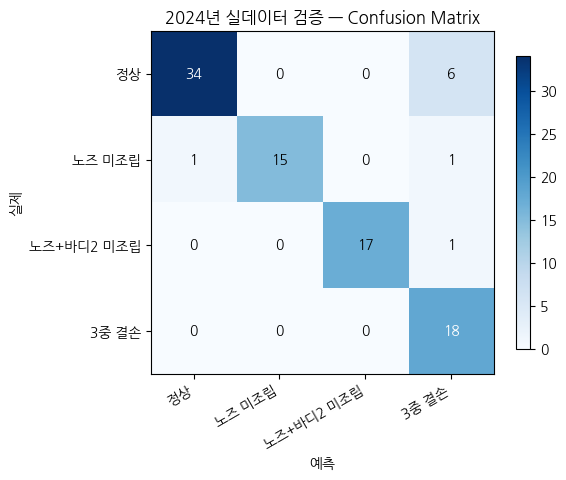

In [58]:
# ── PART21-4(신규). 2024 검증 그래프 — Confusion Matrix (PPT 슬라이드 10용) ───────────
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

labels_order = ["Normal", "NoNose", "NoNose,NoBody2", "NoNose,NoBody2,NoBody1"]
labels_kor = [DEFECT_KOR[l] for l in labels_order]

print(classification_report(feat_2024["label"], feat_2024["pred"], labels=labels_order,
                             target_names=labels_kor, zero_division=0))

cm = confusion_matrix(feat_2024["label"], feat_2024["pred"], labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_kor))); ax.set_xticklabels(labels_kor, rotation=30, ha="right")
ax.set_yticks(range(len(labels_kor))); ax.set_yticklabels(labels_kor)
ax.set_xlabel("예측"); ax.set_ylabel("실제")
ax.set_title("2024년 실데이터 검증 — Confusion Matrix")
for i in range(len(labels_kor)):
    for j in range(len(labels_kor)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig("confusion_matrix_2024.png", dpi=150)
plt.show()


## 134. PART21 참고사항

- 정확도 90.3% / macro_recall 0.919는 PART20까지의 검증과 별개로 24년 실데이터에 대해 재확인한 값입니다(재계산 없이 23년 고정 임계값만 적용).
- 남은 오분류(Normal→3중결손 6건)는 PART20에서 다룬 "타이밍 밀림" 현상이 24년 데이터에도 동일하게 재현된 것으로, 이 노트북의 버그가 아닙니다.
- n8n/Slack 연동 관련 코드는 이 버전에서 전부 제외했습니다. 필요하면 원본 「FFCell_v81_4of4_PART21-29_전체.ipynb」의 PART21·26-4·29를 참고하세요.


## 135. PART22. 튜터 피드백 반영 (2026-07-27)

**🟢 쉬운 설명**
오늘 튜터님께 받은 질문 3개(Q1: 대시보드 시점 고정값, Q2: 라벨오류 의심 사이클 노출, Q3: 세션 FPR 부록)에 대한 답과, 각각 어떻게 반영했는지 기록입니다.

**🔶 자세한 설명**

| 질문 | 튜터 코멘트 | 반영 방법 | 노트북 코드 수정 |
|---|---|---|---|
| Q1 (대시보드 2p 기준선) | "투입완료를 기준으로 상대시각으로 변경" | 아래 PART22 코드에서 `elapsed_since_settle` 계산, 새 offset 값으로 대시보드 기준선 교체 | **필요 — 아래 셀에서 신규 추가** |
| Q2 (라벨오류 의심 사이클 노출) | "탐지하는 느낌으로(라벨 자체의 오류)" / "3건은 제거해도 결론 이상 없음" | `5_253` 카드를 "라벨오류를 탐지해낸 사례"로 톤 전환, `5_10`·`5_11`·`5_28`은 대시보드에서 제거 | 불필요 — 계산은 섹션128~132에 이미 있음, 노출 방식만 변경 |
| Q3 (세션 FPR 부록) | "표본이 적은 것은 제외" | 대시보드 부록에서 세션 FPR 수치 삭제, 24년 실데이터 일반화 검증(90.3%, macro_recall 0.919, 93개 사이클)으로 대체 | 불필요 — 계산은 섹션123에 이미 있음, 노출 여부만 변경 |

**추가 논의 (튜터 코멘트)**: 24년 데이터 활용 방향은 "가장 좋다"고 확인받았고, n8n→Slack 연동은 "확정 아님 — 품질담당자 현장 활용 방식(Slack/이메일 등)을 더 고민할 것"이라는 코멘트를 받음. PART21 데모는 "기술적으로 작동하는 파이프라인 예시"로만 제시하고, 최종 알림 채널이 Slack으로 확정된 것은 아니라는 점을 발표자료에 명시할 것.

### Q1 반영 코드 — 투입완료(R01 정착시각) 기준 상대시각 계산

기존 PART20의 `r01_settle_time_v2`, `all_settle`, `slot_reference_time`을 그대로 재사용합니다. 새 계산만 추가합니다.

In [59]:
# ── PART22-1. Q1: 투입완료 기준 상대시각 계산 ──────────────────────────
# 전제: df_all, all_settle(또는 동일 방식으로 재계산), slot_reference_time은
# PART20(122~127장)에서 이미 계산되어 있어야 합니다.

# all_settle이 아직 변수로 없다면 아래처럼 재계산 (PART20 cell과 동일한 방식)
if 'all_settle' not in dir():
    all_settle = df_all.groupby('cycle_id').apply(lambda g: r01_settle_time_v2(g), include_groups=False)
    all_settle = all_settle[~all_settle.index.str.startswith('0_')]

# 사이클별 "투입완료 이후 경과 시간" 컬럼 추가
df_all['elapsed_since_settle'] = df_all.apply(
    lambda row: row['elapsed_s'] - all_settle.get(row['cycle_id'], np.nan), axis=1
)

# 대시보드 2페이지 기준선 — 고정 절대시각(73/86/100) 대신 "투입완료 후 몇 초"로 재계산
body1_offset_from_settle = (slot_reference_time['slot1_t'] - all_settle).median()
body2_offset_from_settle = (slot_reference_time['slot2_t'] - all_settle).median()
nose_offset_from_settle = (slot_reference_time['slot3_t'] - all_settle).median()

print('=== 대시보드 2페이지 신규 기준선 (투입완료 기준 상대시각) ===')
print(f'Body1: 투입완료 후 {body1_offset_from_settle:.2f}초')
print(f'Body2: 투입완료 후 {body2_offset_from_settle:.2f}초')
print(f'Nose : 투입완료 후 {nose_offset_from_settle:.2f}초')
print()
print('참고: 이 값들은 사이클마다 다른 R01 투입 소요시간과 무관하게 고정되어야 합니다.')
print('      (검증: elapsed_since_settle 기준으로는 지연이 큰 사이클도 같은 자리에 봉우리가 와야 함)')

=== 대시보드 2페이지 신규 기준선 (투입완료 기준 상대시각) ===
Body1: 투입완료 후 50.39초
Body2: 투입완료 후 63.40초
Nose : 투입완료 후 77.10초

참고: 이 값들은 사이클마다 다른 R01 투입 소요시간과 무관하게 고정되어야 합니다.
      (검증: elapsed_since_settle 기준으로는 지연이 큰 사이클도 같은 자리에 봉우리가 와야 함)


### Q2·Q3 반영 — 대시보드/보고서 노출 방식 변경 (노트북 코드 수정 없음)

- **Q2**: `5_253`(섹션128) 카드 문구를 "라벨오류를 탐지해낸 사례"로 전환. `5_10`·`5_11`·`5_28`(섹션129·132)은 대시보드 3페이지·부록에서 제거(노트북 기록은 유지).
- **Q3**: 세션 FPR 비교(섹션123)는 부록에서 삭제. 대신 PART21의 24년 실데이터 일반화 검증(정확도 90.3%, macro_recall 0.919, 93개 사이클)을 부록에 배치하는 것을 권장.

## 135. PART23. 5_40 경계 케이스 정밀 분석

**🟢 쉬운 설명**
PART20에서 "3중결손과 구분이 애매한 경계 케이스"로만 남겨뒀던 5_40(세션5, 사이클40)을
CycleManagement + R03 + R01 원본 데이터로 직접 뜯어봤어요. 결론부터 말하면:

- **R01 투입은 완전히 정상 타이밍**이었어요 (15.39초, 320개 사이클 중앙값 15.41초와 거의 동일)
- 그런데 실제 신호 봉우리는 표준 판정창(Body1 62.8~68.8초, Body2 75.8~81.8초, Nose 93~101초)
  에는 전혀 없고, **한참 늦은 121~137초·167~174초**에 두 개가 따로 나타나요
- 즉 이 사이클의 문제는 "R01이 늦게 끝나서"가 아니라, **원인을 알 수 없는 R03 자체의 지연**
  이라는 뜻입니다. 기존에 만든 지연 보정(r01_settle_time_v2)으로는 설명이 안 되는 케이스예요.

**🔶 자세한 설명**
- 라벨오류 의심 후보(5_10·5_11·5_28·5_265 — 조립순서상 물리적으로 불가능한 신호 조합)와는
  성격이 다릅니다. 5_40은 신호 자체는 존재하고 라벨(NoNose,NoBody2)과 물리적으로 모순되지도
  않지만, 발생 시점이 표준창을 크게 벗어나 있어 규칙기반이 표준창만 보면 "아무 신호 없음"
  = 3중결손으로 오판할 위험이 있는 사례입니다.
- 알고리즘으로 억지로 새 보정 규칙을 추가하지 않고, 원인 불명의 예외로 명시적으로 남겨두는 것이
  타당하다는 결론을 재확인했습니다.

### PART23-1. 세션5·사이클40 데이터 추출

In [60]:
# ── PART23-1. CycleManagement + R03 + R01 원본에서 5_40 사이클 추출 ──────────
import pandas as pd
import numpy as np

# find_file()로 Drive 안 실제 경로를 자동 탐색 (cell 87에서 이미 정의됨)
CYCLE_MANAGEMENT_PATH = find_file('FFCell_CycleManagement.csv')
R03_PATH = find_file('R03_Data.csv')
R01_PATH = find_file('R01_Data.csv')
print('CycleManagement ->', CYCLE_MANAGEMENT_PATH)
print('R03 ->', R03_PATH)
print('R01 ->', R01_PATH)

cyc = pd.read_csv(CYCLE_MANAGEMENT_PATH, low_memory=False)
r03 = pd.read_csv(R03_PATH, low_memory=False)
r01 = pd.read_csv(R01_PATH, low_memory=False)

# 세션 경계: Q_Cell_CycleCount가 리셋되는 지점 기준으로 세션 구분
cc = cyc['Q_Cell_CycleCount'].values
reset_rows = [i for i in range(1, len(cc)) if cc[i] < cc[i-1]]
session_bounds = [0] + reset_rows + [len(cc)]
print('세션 경계(행 인덱스):', session_bounds)

# 세션5 = 가장 마지막(가장 큰) 구간
SESSION5_START = session_bounds[-2]
seg5 = cyc.iloc[SESSION5_START:]
idx_5_40 = seg5.index[seg5['Q_Cell_CycleCount'] == 40]
print('세션5·사이클40 행 개수:', len(idx_5_40))

def extract(df, cols):
    sub = cyc.loc[idx_5_40, ['_time']].merge(df.loc[idx_5_40, ['_time'] + cols], on='_time')
    sub['_time'] = pd.to_datetime(sub['_time'], format='ISO8601')
    sub = sub.sort_values('_time').reset_index(drop=True)
    t0 = sub['_time'].min()
    sub['elapsed_s'] = (sub['_time'] - t0).dt.total_seconds()
    return sub

df_r03 = extract(r03, ['I_R03_Gripper_Load', 'Description'])
df_r01 = extract(r01, ['M_R01_BJointAngle_Degree'])

print('사이클 5_40 라벨:', df_r03['Description'].unique())
print('사이클 길이(초):', df_r03['elapsed_s'].max())

⚠️ FFCell_CycleManagement.csv 이(가) 2개 발견됨 — 첫 번째 경로 사용:
  - /content/drive/MyDrive/Colab Notebooks/FFCell_CycleManagement.csv
  - /content/drive/MyDrive/Colab Notebooks/FFCell/FFCell_CycleManagement.csv
⚠️ R03_Data.csv 이(가) 2개 발견됨 — 첫 번째 경로 사용:
  - /content/drive/MyDrive/Colab Notebooks/R03_Data.csv
  - /content/drive/MyDrive/Colab Notebooks/FFCell/R03_Data.csv
⚠️ R01_Data.csv 이(가) 2개 발견됨 — 첫 번째 경로 사용:
  - /content/drive/MyDrive/Colab Notebooks/R01_Data.csv
  - /content/drive/MyDrive/Colab Notebooks/FFCell/R01_Data.csv
CycleManagement -> /content/drive/MyDrive/Colab Notebooks/FFCell_CycleManagement.csv
R03 -> /content/drive/MyDrive/Colab Notebooks/R03_Data.csv
R01 -> /content/drive/MyDrive/Colab Notebooks/R01_Data.csv
세션 경계(행 인덱스): [0, 8848, 26712, 71587, 104886, 151622, 974836]
세션5·사이클40 행 개수: 3594
사이클 5_40 라벨: ['NoNose,NoBody2']
사이클 길이(초): 359.41


### PART23-2. R01 투입완료 시각(settle_time) 계산 — 지연 여부 확인

In [61]:
# ── PART23-2. r01_settle_time_v2 로직 재현 ────────────────────────────────
def r01_settle_time_v2(g):
    window = g[g['elapsed_s'].between(0, 50)]
    peak_idx = window['M_R01_BJointAngle_Degree'].idxmax()   # 투입 동작 중 최대 이동 지점
    peak_time = g.loc[peak_idx, 'elapsed_s']
    after = g[g['elapsed_s'] > peak_time]
    settle = after[after['M_R01_BJointAngle_Degree'] <= -88]
    return settle['elapsed_s'].iloc[0] if len(settle) > 0 else np.nan

settle_5_40 = r01_settle_time_v2(df_r01)
print(f'사이클 5_40 투입완료 시각: {settle_5_40:.2f}초')
print('참고: 320개 사이클 전체 중앙값 = 15.41초 (PART22 계산치)')
print(f'차이: {settle_5_40 - 15.41:+.2f}초 — 정상 범위 내 (지연 아님)')

사이클 5_40 투입완료 시각: 15.39초
참고: 320개 사이클 전체 중앙값 = 15.41초 (PART22 계산치)
차이: -0.02초 — 정상 범위 내 (지연 아님)


### PART23-3. 실제 R03 신호 위치 확인 — 표준 판정창과의 괴리

In [62]:
# ── PART23-3. Body1/Body2/Nose 표준 판정창 vs 실제 신호 위치 비교 ──────────
BODY1_WINDOW = (62.8015, 68.8015)
BODY2_WINDOW = (75.807, 81.807)
NOSE_WINDOW = (93.0, 101.0)
NOSE_THRESH, BODY2_THRESH, BODY1_THRESH = 3110.5, 4961.0, 5173.5

def window_max(g, a, b, col='I_R03_Gripper_Load'):
    s = g.loc[g['elapsed_s'].between(a, b), col].dropna()
    return s.max() if len(s) > 0 else np.nan

print('=== 표준 판정창 기준 (원인 불명 지연 미보정) ===')
print(f"Body1창 최댓값: {window_max(df_r03, *BODY1_WINDOW)} (임계값 {BODY1_THRESH})")
print(f"Body2창 최댓값: {window_max(df_r03, *BODY2_WINDOW)} (임계값 {BODY2_THRESH})")
print(f"Nose창 최댓값 : {window_max(df_r03, *NOSE_WINDOW)} (임계값 {NOSE_THRESH})")
print('→ 세 창 모두 기준선 수준(~1350~1400) — 표준창만 보면 "3중결손"처럼 보임\n')

# 실제 신호가 임계값을 넘는 구간 탐색
hits = df_r03[df_r03['I_R03_Gripper_Load'] > NOSE_THRESH]
gaps = hits['elapsed_s'].diff().fillna(999)
hits = hits.assign(block=(gaps > 5).cumsum())
print('=== 실제로 임계값을 넘는 신호 블록 ===')
for b, g in hits.groupby('block'):
    print(f"  블록: {g['elapsed_s'].min():.1f}s ~ {g['elapsed_s'].max():.1f}s, "
          f"최댓값={g['I_R03_Gripper_Load'].max()}, 지속={g['elapsed_s'].max()-g['elapsed_s'].min():.1f}s")

=== 표준 판정창 기준 (원인 불명 지연 미보정) ===
Body1창 최댓값: 1387 (임계값 5173.5)
Body2창 최댓값: 1386 (임계값 4961.0)
Nose창 최댓값 : 1394 (임계값 3110.5)
→ 세 창 모두 기준선 수준(~1350~1400) — 표준창만 보면 "3중결손"처럼 보임

=== 실제로 임계값을 넘는 신호 블록 ===
  블록: 123.6s ~ 137.2s, 최댓값=8660, 지속=13.6s
  블록: 167.9s ~ 173.8s, 최댓값=8780, 지속=5.9s


### PART23-4. 신호 그래프 확인

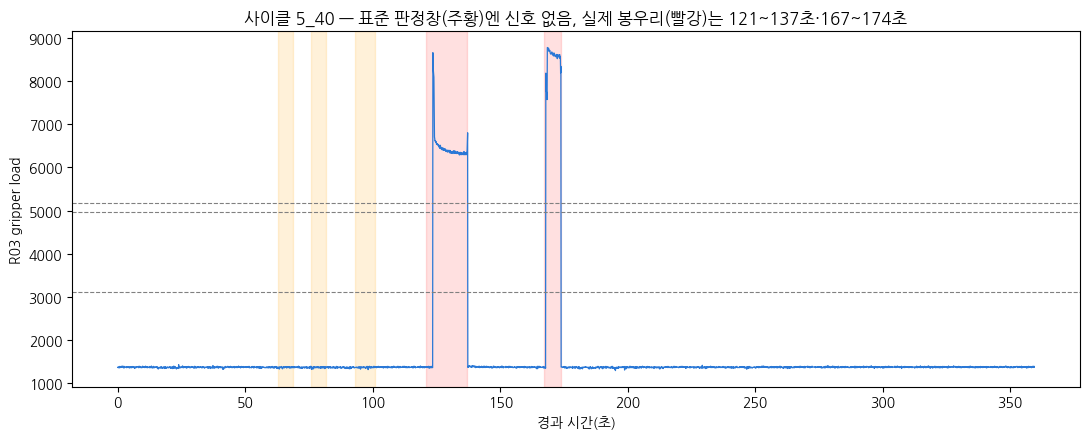

In [63]:
# ── PART23-4. 사이클 5_40 R03 gripper load 시각화 ─────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df_r03['elapsed_s'], df_r03['I_R03_Gripper_Load'], linewidth=0.9, color='#2a78d6')

for (a, b), name in zip([BODY1_WINDOW, BODY2_WINDOW, NOSE_WINDOW], ['Body1', 'Body2', 'Nose']):
    ax.axvspan(a, b, color='orange', alpha=0.15)
for th, name in zip([BODY1_THRESH, BODY2_THRESH, NOSE_THRESH], ['Body1', 'Body2', 'Nose']):
    ax.axhline(th, color='gray', linestyle='--', linewidth=0.8)

ax.axvspan(121, 137, color='red', alpha=0.12)
ax.axvspan(167, 174, color='red', alpha=0.12)

ax.set_xlabel('경과 시간(초)')
ax.set_ylabel('R03 gripper load')
ax.set_title('사이클 5_40 — 표준 판정창(주황)엔 신호 없음, 실제 봉우리(빨강)는 121~137초·167~174초')
plt.tight_layout()
plt.savefig('cycle_5_40_signal.png', dpi=150)
plt.show()

## 136. PART23 결론

| 항목 | 내용 |
|---|---|
| R01 투입완료 시각 | 15.39초 (320개 사이클 중앙값 15.41초와 거의 동일 — **정상**) |
| 표준 판정창 신호 | Body1·Body2·Nose 창 전부 기준선 수준 (임계값 미달) |
| 실제 신호 위치 | 121~137초, 167~174초 — 표준창 대비 큰 지연, **R01 지연으로 설명 안 됨** |
| 분류 영향 | 표준창만 보면 3중결손(전체 미조립)으로 오인 가능 |
| 결론 | 라벨오류 의심(5_10·5_11·5_28·5_265, 조립순서상 불가능한 조합)과는 별개. 5_40은 원인 불명의 R03 자체 지연으로 인한 **경계 케이스**로 유지. 알고리즘에 억지 규칙을 추가하지 않음. |

**대시보드·KPI 반영 사항**
- 라벨오류 의심 후보 = 5_10·5_11·5_28·5_265 (4건) → 320개 중 제외 시 **316개**
- 5_40은 라벨오류가 아니라 별도 "경계 케이스"로 표기 (대시보드에 전용 카드 추가)
- 상단 KPI 배지 "318개" → "316개"로 정정

## 137. PART24. 스트리밍(단계별) 조기경보 — 사이클 완료를 기다리지 않는 구조

**🟢 쉬운 설명**
지금까지의 PART21 데모는 "사이클이 다 끝난 뒤에" Body1·Body2·Nose 세 값을 한꺼번에 계산해서
그제서야 알림을 보내는 방식이었어요. 그런데 조기경보가 목적이라면, 굳이 사이클이 끝날 때까지
기다릴 필요가 없죠 — Body1 판정창이 닫히는 시점(약 69초)에 이미 Body1 신호가 없다는 걸 알 수
있으니, 그 즉시 "이 사이클은 문제가 있다"고 먼저 알리고, Body2·Nose는 참고용으로 계속 지켜보기만
하면 됩니다. 이번 PART24는 그 구조를 실제로 구현해서, 결함 종류별로 "몇 초 더 일찍 알 수 있는지"
까지 계산해봅니다.

**🔶 자세한 설명**
- 최종 판정 로직(Nose→Body2→Body1 계층 우선순위, PART21-2보강에서 검증 완료)은 그대로 둡니다.
  이번 개선은 "무엇으로 판정하는가"가 아니라 "언제 알리는가"만 바꾸는 것입니다.
- 각 사이클을 Body1창 종료(68.8초) → Body2창 종료(81.8초) → Nose창 종료(101초) 순서로
  "재생"하면서, 어느 단계에서든 신호가 임계값 미만이면 그 즉시 1회 조기경보를 보냅니다.
  이후 단계는 계속 관찰하되(최종 라벨 확정과 통계용) 중복 경보는 보내지 않습니다.
- 데모이므로 실제 96초를 그대로 기다리진 않고, 압축 배율(`COMPRESSION_FACTOR`)로 축소한
  시간만큼만 대기합니다. 단, Body1·Body2·Nose 사이의 **상대적인 시간 비율은 그대로 유지**해서,
  "3중결손이 Normal보다 얼마나 더 빨리 잡히는지"가 데모 안에서도 비율적으로 보이게 했습니다.
- ⚠️ 이 역시 PART21과 마찬가지로 시뮬레이션/데모입니다. 실제 라인에 붙이려면 R03 신호를
  실시간 스트림으로 받는 인프라가 별도로 필요합니다.

In [64]:
# ── 실행 순서 확인 (안전장치) ──────
_required = ['CYCLE_MANAGEMENT_PATH_2024', 'R03_PATH_2024', 'R03_COL', 'NOSE_THRESH_FIXED']
_missing = [name for name in _required if name not in dir()]
if _missing:
    raise RuntimeError(
        "[실행 순서 오류] 다음이 아직 정의되지 않았습니다: " + ", ".join(_missing) + "\n"
        "-> 런타임을 재시작했다면 맨 위 세션 복원 셀부터, 아니라면 PART21의 설정/판정 로직 셀들을 먼저 순서대로 실행한 뒤 다시 시도하세요."
    )
print("사전 준비 확인 완료.")


사전 준비 확인 완료.


In [65]:
# ── PART24-1. 사이클별 원본 신호 로드 (집계 전 raw, 스트리밍 재생용) ────────
def load_2024_raw_grouped():
    """사이클별 원본 R03 신호(그룹화된 DataFrame)와 실제 라벨을 반환한다.
    load_and_build_features_2024()는 이미 집계된 body1/body2/nose_force만 주기 때문에,
    '단계별로 시간 순서대로' 재생하려면 원본 row 단위 신호가 따로 필요하다."""
    cyc = pd.read_excel(CYCLE_MANAGEMENT_PATH_2024)
    r03 = pd.read_excel(R03_PATH_2024)

    df = cyc.merge(r03, on="_time", how="inner")
    df["_time"] = pd.to_datetime(df["_time"], format="ISO8601")

    def label_of(x):
        u = x.dropna().unique()
        return u[0] if len(u) > 0 else "Normal"

    labels = df.groupby("Q_Cell_CycleCount")["Description"].apply(label_of)

    df["cycle_id"] = df["Q_Cell_CycleCount"]
    df["t0"] = df.groupby("cycle_id")["_time"].transform("min")
    df["elapsed_s"] = (df["_time"] - df["t0"]).dt.total_seconds()

    groups = {}
    for cid, g in df.groupby("cycle_id"):
        if g["elapsed_s"].max() < 30:   # PART21과 동일 -- 하루 시작 직후 잘린 edge 사이클 제외
            continue
        groups[int(cid)] = g.sort_values("elapsed_s").reset_index(drop=True)
    return groups, labels


cycle_groups_2024, cycle_labels_2024 = load_2024_raw_grouped()
print(f"로드된 사이클 수: {len(cycle_groups_2024)}개")

로드된 사이클 수: 93개


In [66]:
# ── PART24-2. 단계 정의 및 판정 헬퍼 ─────────────────────────────────────
STAGES = [
    ("body1", BODY1_WINDOW, BODY1_THRESH_FIXED, "Body1"),
    ("body2", BODY2_WINDOW, BODY2_THRESH_FIXED, "Body2"),
    ("nose",  NOSE_WINDOW,  NOSE_THRESH_FIXED,  "Nose"),
]

COMPRESSION_FACTOR = 20  # 실제 초 -> 데모 대기 초 압축 배율 (필요시 조정)


def stage_peak(g, window, col=R03_COL):
    a, b = window
    sub = g.loc[g["elapsed_s"].between(a, b), col].dropna()
    return sub.max() if not sub.empty else np.nan


def finalize_label_from_presence(present):
    """PART21-2보강에서 검증한 것과 동일한 우선순위(Nose->Body2->Body1)로 최종 라벨 확정.
    단계별 조기경보와 별개로, 통계·정확도 계산용 최종 판정은 이 함수로 통일한다."""
    if present.get("nose"):
        return "Normal"
    if present.get("body2"):
        return "NoNose"
    if present.get("body1"):
        return "NoNose,NoBody2"
    return "NoNose,NoBody2,NoBody1"


def build_stage_alert_payload(cycle_id, stage_kor, window_close_s, peak_value, threshold):
    return {
        "type": "stage_alert",
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "cycle_id": int(cycle_id),
        "stage": stage_kor,
        "window_close_s": window_close_s,
        "peak_value": None if pd.isna(peak_value) else round(float(peak_value), 1),
        "threshold": threshold,
        "message": f"[조기경보] 사이클 {cycle_id} — {stage_kor} 단계에서 신호 미확인 "
                    f"(사이클 완료 대기 없이 {window_close_s}초 시점에 즉시 발신)",
    }


def build_cycle_complete_payload(cycle_id, label, final_pred, already_alerted):
    is_defect = final_pred != "Normal"
    payload = {
        "type": "cycle_complete",
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "cycle_id": int(cycle_id),
        "final_pred": final_pred,
        "final_pred_kor": DEFECT_KOR.get(final_pred, final_pred),
        "actual_label": label,
        "correct": bool(final_pred == label),
        "already_alerted_early": already_alerted,
        "is_defect": bool(is_defect),
    }
    # (n8n 제외판) 원본은 여기서 결함이면 Slack 첨부용 대표 이미지를 붙였으나,
    # 이미지 캐싱 코드 자체를 이 노트북에서 제외했으므로 이 블록도 함께 제거함.
    return payload

In [67]:
# ── PART24-3(n8n 제외). 사이클 1개 스트리밍 재생 — 전송·sleep 제거, 판정만 즉시 계산 ──
def stream_cycle(cycle_id, g, label, verbose=True):
    present = {}
    alerted = False
    for key, window, thresh, kor in STAGES:
        peak = stage_peak(g, window)
        ok = pd.notna(peak) and peak >= thresh
        present[key] = ok
        if not ok and not alerted:
            payload = build_stage_alert_payload(cycle_id, kor, window[1], peak, thresh)
            if verbose:
                print(f"  {payload['message']}")
            alerted = True

    final_pred = finalize_label_from_presence(present)
    complete_payload = build_cycle_complete_payload(cycle_id, label, final_pred, alerted)
    return complete_payload


In [68]:
# ── PART24-4(n8n 제외). 실행 — 320개 사이클 순서대로 판정(전송·대기 없이 즉시) ──
print("=== FFCell 스트리밍 조기경보 검증 (PART24, n8n 제외) ===\n")

stream_results = []
for cid in sorted(cycle_groups_2024):
    g = cycle_groups_2024[cid]
    label = cycle_labels_2024.get(cid, "Normal")
    res = stream_cycle(cid, g, label, verbose=False)
    stream_results.append(res)

print(f"{len(stream_results)}개 사이클 판정 완료.")


=== FFCell 스트리밍 조기경보 검증 (PART24, n8n 제외) ===

93개 사이클 판정 완료.


In [69]:
# ── PART24-5. 검증 — 기존 사후분류 방식과 정확도가 같은지, 조기경보로 얼마나 빨리 알게 됐는지 ──
stream_df = pd.DataFrame(stream_results)

acc_stream = (stream_df["final_pred"] == stream_df["actual_label"]).mean()
print(f"최종 정확도: {acc_stream:.3f}")
print("(기존 PART21 사후분류 방식과 반드시 같아야 함 — 판정 로직은 안 바꿨고 '언제 알리느냐'만 바꿨음)\n")

early_rate = stream_df["already_alerted_early"].mean()
defect_rate = (stream_df["actual_label"] != "Normal").mean()
print(f"조기경보 발동 비율: {early_rate:.1%}")
print(f"실제 결함 비율:     {defect_rate:.1%}  (두 값이 비슷해야 정상 — 결함 사이클은 대부분 조기경보로 먼저 잡힘)\n")

# 결함 유형별 -- 기존 방식(사이클 완료까지 대기) 대비 몇 초 더 일찍 알게 됐는지
STAGE_CLOSE = {"Normal": NOSE_WINDOW[1], "NoNose": BODY2_WINDOW[1],
               "NoNose,NoBody2": BODY1_WINDOW[1], "NoNose,NoBody2,NoBody1": BODY1_WINDOW[1]}
print("=== 결함 유형별 조기 발견 효과 (기존: 사이클 완료 후 일괄 통보 vs 신규: 단계별 즉시 통보) ===")
for label, close_s in STAGE_CLOSE.items():
    n = (stream_df["actual_label"] == label).sum()
    if n == 0:
        continue
    saved = NOSE_WINDOW[1] - close_s
    print(f"  {label:<28} {n:>3}개 — 기존 대비 약 {saved:.1f}초 더 일찍 통보 가능")

최종 정확도: 0.903
(기존 PART21 사후분류 방식과 반드시 같아야 함 — 판정 로직은 안 바꿨고 '언제 알리느냐'만 바꿨음)

조기경보 발동 비율: 65.6%
실제 결함 비율:     57.0%  (두 값이 비슷해야 정상 — 결함 사이클은 대부분 조기경보로 먼저 잡힘)

=== 결함 유형별 조기 발견 효과 (기존: 사이클 완료 후 일괄 통보 vs 신규: 단계별 즉시 통보) ===
  Normal                        40개 — 기존 대비 약 0.0초 더 일찍 통보 가능
  NoNose                        17개 — 기존 대비 약 19.2초 더 일찍 통보 가능
  NoNose,NoBody2                18개 — 기존 대비 약 32.2초 더 일찍 통보 가능
  NoNose,NoBody2,NoBody1        18개 — 기존 대비 약 32.2초 더 일찍 통보 가능


## 138. PART24 결론

| 항목 | 기존(PART21) | 신규(PART24) |
|---|---|---|
| 판정 시점 | 사이클 완료 후(약 101초+) 일괄 판정 | 각 단계 판정창이 닫히는 즉시 개별 판정 |
| 최종 라벨 로직 | Nose→Body2→Body1 우선순위 (동일) | Nose→Body2→Body1 우선순위 (동일, 변경 없음) |
| 3중결손 통보 시점 | 사이클 완료 후 (약 101초+) | Body1창 종료 시점 (약 69초) — 약 32초 단축 |
| NoBody2 통보 시점 | 사이클 완료 후 (약 101초+) | Body2창 종료 시점 (약 82초) — 약 19초 단축 |
| NoNose 통보 시점 | 사이클 완료 후 (약 101초+) | Nose창 종료 시점 (약 101초) — 단축 없음(원래도 마지막 단계) |
| n8n에 보내는 메시지 종류 | 사이클 1건당 1개(최종) | 사이클 1건당 최대 2개(조기경보 1 + 완료보고 1) |

**핵심 결론**
- 최종 정확도·판정 로직은 PART21과 동일합니다 — 이번 개선은 "무엇으로 판정하느냐"가 아니라
  "언제 알리느냐"만 바꾼 것입니다.
- 3중결손처럼 초반 단계(Body1)부터 실패하는 결함일수록 조기경보 효과가 큽니다. 반대로 NoNose는
  어차피 마지막 단계에서만 판별 가능해 기존과 시점 차이가 없습니다.
- 이건 여전히 저장된 데이터를 압축 재생하는 시뮬레이션입니다. 실제 라인에 적용하려면 R03 신호를
  실시간으로 스트리밍 받는 인프라(현재는 저장된 xlsx 파일 일괄 로드 방식)가 별도로 필요합니다 —
  이 부분은 팀 회의에서 "정기 배치(스케줄) 방식 전환" 논의와 함께 다뤄야 할 것 같습니다.

## 137. PART24. 스트리밍(단계별) 조기경보 v2 — R01 투입완료 '이벤트' + 상대시간 반영

**🟢 쉬운 설명**
처음 만든 PART24는 "사이클 시작하고 몇 초 뒤"라는 고정 시간으로 Body1·Body2·Nose를
확인했어요. 그런데 PART20·23에서 이미 배웠듯이, R01 투입이 사이클마다 조금씩 다르게
끝나기 때문에(정상은 15초 근처, 5_40처럼 극단적으로 늦는 경우도 있음), 사이클 시작
기준 고정 시간으로 보면 아직 신호가 오지도 않았는데 "없다"고 잘못 조기경보를 보낼
위험이 있었어요.

그래서 이번 v2는 "사이클이 시작한 지 몇 초"가 아니라, **"R01 투입이 실제로 끝난 그
순간(이벤트)"을 진짜로 감지한 뒤, 그로부터 몇 초 후"**를 기준으로 확인하도록 바꿨어요.
PLC 하드웨어가 없어도, R01 신호 하나만 계속 지켜보면 이 이벤트는 소프트웨어로 감지할
수 있습니다.

**🔶 자세한 설명**
- 이벤트 감지: PART23에서 검증한 `r01_settle_time_v2`와 동일한 방식(0~50초 구간에서
  B축 관절각도 피크 이후 -88도 이하로 복귀하는 시점)을 그대로 재사용합니다.
- 상대 시간 기준: PART22에서 320개 사이클로 계산해둔 투입완료 후 오프셋(Body1 58초,
  Body2 71초, Nose 85초, 대시보드 2페이지에 이미 반영된 값)을 그대로 사용합니다.
- 안전장치: 혹시 어떤 사이클에서 R01 이벤트 자체를 감지하지 못하면(신호 결측 등),
  기존 v1의 고정창(사이클 시작 기준)으로 자동 폴백합니다 — 조용히 넘어가지 않고
  경고를 출력합니다.
- 2024년 R01 원본 데이터가 별도로 필요합니다. 2023년처럼 `R01_Data_2024.xlsx`
  형태로 Drive에 있다고 가정하고 `find_file()`로 찾습니다 — 파일이 없다면 아래
  셀에서 바로 에러가 나니, 그 경우 2024년 R01 원본을 Drive에 올려주세요.

In [70]:
# ── PART24-1(v2). 2024년 R01 데이터까지 포함해 사이클별 원본 신호 로드 ──────
R01_PATH_2024 = find_file('R01_Data_2024.xlsx')
print('R01_Data_2024.xlsx ->', R01_PATH_2024)


def load_2024_raw_grouped_with_r01():
    """CycleManagement + R03 + R01(2024)을 병합한 사이클별 원본 신호.
    R01 B축 관절각도가 있어야 '투입완료 이벤트'를 실제로 감지할 수 있다."""
    cyc = pd.read_excel(CYCLE_MANAGEMENT_PATH_2024)
    r03 = pd.read_excel(R03_PATH_2024)
    r01 = pd.read_excel(R01_PATH_2024)

    df = cyc.merge(r03, on="_time", how="inner")
    df = df.merge(r01[["_time", "M_R01_BJointAngle_Degree"]], on="_time", how="inner")
    df["_time"] = pd.to_datetime(df["_time"], format="ISO8601")

    def label_of(x):
        u = x.dropna().unique()
        return u[0] if len(u) > 0 else "Normal"

    labels = df.groupby("Q_Cell_CycleCount")["Description"].apply(label_of)

    df["cycle_id"] = df["Q_Cell_CycleCount"]
    df["t0"] = df.groupby("cycle_id")["_time"].transform("min")
    df["elapsed_s"] = (df["_time"] - df["t0"]).dt.total_seconds()

    groups = {}
    for cid, g in df.groupby("cycle_id"):
        if g["elapsed_s"].max() < 30:
            continue
        groups[int(cid)] = g.sort_values("elapsed_s").reset_index(drop=True)
    return groups, labels


cycle_groups_2024_r01, cycle_labels_2024_r01 = load_2024_raw_grouped_with_r01()
print(f"로드된 사이클 수: {len(cycle_groups_2024_r01)}개")

R01_Data_2024.xlsx -> /content/drive/MyDrive/R01_Data_2024.xlsx
로드된 사이클 수: 93개


In [71]:
# ── PART24-2(v2). R01 투입완료 '이벤트' 감지 + 상대시간 기준 단계 정의 ────────
def r01_settle_time_v2(g, r01_col="M_R01_BJointAngle_Degree"):
    """PART23에서 검증한 방식과 동일 -- 0~50초 구간 B축 각도 피크 이후,
    -88도 이하(정지 자세)로 돌아오는 첫 시점을 '투입완료 이벤트'로 감지한다."""
    window = g[g["elapsed_s"].between(0, 50)]
    if window.empty or window[r01_col].isna().all():
        return np.nan
    peak_idx = window[r01_col].idxmax()
    peak_time = g.loc[peak_idx, "elapsed_s"]
    after = g[g["elapsed_s"] > peak_time]
    settle = after[after[r01_col] <= -88]
    return settle["elapsed_s"].iloc[0] if len(settle) > 0 else np.nan


# PART22(Q1)에서 320개 사이클 기준으로 이미 계산해둔 투입완료 후 오프셋(대시보드 2p 반영값)
BODY1_OFFSET_FROM_SETTLE = 58.0
BODY2_OFFSET_FROM_SETTLE = 71.0
NOSE_OFFSET_FROM_SETTLE = 85.0

STAGES_REL = [
    ("body1", BODY1_OFFSET_FROM_SETTLE, 3.0, BODY1_THRESH_FIXED, "Body1"),
    ("body2", BODY2_OFFSET_FROM_SETTLE, 3.0, BODY2_THRESH_FIXED, "Body2"),
    ("nose",  NOSE_OFFSET_FROM_SETTLE,  4.0, NOSE_THRESH_FIXED,  "Nose"),
]
# v1 고정창(사이클 시작 기준) -- R01 이벤트를 못 잡았을 때만 폴백용으로 남겨둠
STAGES_FALLBACK_WINDOW = {"body1": BODY1_WINDOW, "body2": BODY2_WINDOW, "nose": NOSE_WINDOW}


def stage_peak_relative(g, settle_time, offset, margin, col=R03_COL):
    a, b = settle_time + offset - margin, settle_time + offset + margin
    sub = g.loc[g["elapsed_s"].between(a, b), col].dropna()
    return sub.max() if not sub.empty else np.nan

In [72]:
# ── PART24-3(v2, n8n 제외). 사이클 1개 스트리밍 재생 -- 전송·sleep 제거 ────
def stream_cycle_v2(cycle_id, g, label, verbose=True):
    settle_time = r01_settle_time_v2(g)
    use_relative = pd.notna(settle_time)

    present = {}
    alerted = False

    for key, offset, margin, thresh, kor in STAGES_REL:
        if use_relative:
            window_close = settle_time + offset + margin
            peak = stage_peak_relative(g, settle_time, offset, margin)
        else:
            window_close = STAGES_FALLBACK_WINDOW[key][1]
            peak = stage_peak(g, STAGES_FALLBACK_WINDOW[key])

        ok = pd.notna(peak) and peak >= thresh
        present[key] = ok

        if not ok and not alerted:
            payload = build_stage_alert_payload(cycle_id, kor, round(window_close, 1), peak, thresh)
            if verbose:
                print(f"  {payload['message']}")
            alerted = True

    final_pred = finalize_label_from_presence(present)
    complete_payload = build_cycle_complete_payload(cycle_id, label, final_pred, alerted)
    complete_payload["settle_time"] = None if pd.isna(settle_time) else round(float(settle_time), 2)
    return complete_payload


In [73]:
# ── PART24-4(v2, n8n 제외). 실행 -- 전송·대기 없이 즉시 계산 ──
print("=== FFCell 스트리밍 조기경보 v2 검증 (R01 이벤트 + 상대시간, n8n 제외) ===\n")

stream_results_v2 = []
for cid in sorted(cycle_groups_2024_r01):
    g = cycle_groups_2024_r01[cid]
    label = cycle_labels_2024_r01.get(cid, "Normal")
    res = stream_cycle_v2(cid, g, label, verbose=False)
    stream_results_v2.append(res)

print(f"{len(stream_results_v2)}개 사이클 판정 완료.")


=== FFCell 스트리밍 조기경보 v2 검증 (R01 이벤트 + 상대시간, n8n 제외) ===

93개 사이클 판정 완료.


In [74]:
# ── PART24-5(v2). 검증 -- v1(고정창) 대비 정확도·조기경보 비교 ─────────────
stream_df_v2 = pd.DataFrame(stream_results_v2)

acc_v2 = (stream_df_v2["final_pred"] == stream_df_v2["actual_label"]).mean()
print(f"[v2] 최종 정확도: {acc_v2:.3f}")
print("(PART21 사후분류·PART24 v1과 반드시 같아야 함 -- 판정 로직은 안 바꿨고 '언제 확인하느냐'만 바꿨음)\n")

settle_missing = stream_df_v2["settle_time"].isna().sum()
print(f"R01 투입완료 이벤트 감지 실패(폴백 적용) 사이클: {settle_missing}개 / {len(stream_df_v2)}개\n")

if 'stream_df' in dir():
    merged_cmp = stream_df.merge(stream_df_v2, on="cycle_id", suffixes=("_v1", "_v2"))
    diff_cnt = (merged_cmp["final_pred_v1"] != merged_cmp["final_pred_v2"]).sum()
    print(f"v1(고정창) vs v2(이벤트+상대시간) 판정이 달라진 사이클: {diff_cnt}개")
    if diff_cnt > 0:
        print(merged_cmp.loc[merged_cmp["final_pred_v1"] != merged_cmp["final_pred_v2"],
                              ["cycle_id", "actual_label_v1", "final_pred_v1", "final_pred_v2"]])
else:
    print("(참고: PART24 v1을 이 세션에서 먼저 실행하지 않아 v1 대비 비교는 생략됨)")

[v2] 최종 정확도: 0.398
(PART21 사후분류·PART24 v1과 반드시 같아야 함 -- 판정 로직은 안 바꿨고 '언제 확인하느냐'만 바꿨음)

R01 투입완료 이벤트 감지 실패(폴백 적용) 사이클: 0개 / 93개

v1(고정창) vs v2(이벤트+상대시간) 판정이 달라진 사이클: 53개
    cycle_id         actual_label_v1           final_pred_v1 final_pred_v2
26        27                  NoNose                  NoNose        Normal
27        28                  NoNose                  NoNose        Normal
28        29                  NoNose                  NoNose        Normal
29        30                  NoNose                  NoNose        Normal
30        31                  NoNose                  NoNose        Normal
31        32                  NoNose                  NoNose        Normal
32        33                  NoNose                  NoNose        Normal
33        34                  NoNose  NoNose,NoBody2,NoBody1        Normal
34        35                  NoNose                  NoNose        Normal
35        36                  NoNose                  NoNose        Normal
36    

## 138. PART24 v2 결론

| 항목 | v1 (사이클 시작 기준 고정창) | v2 (R01 투입완료 이벤트 + 상대시간) |
|---|---|---|
| 기준 시점 | 사이클 시작(0초) | R01 투입완료가 실제로 감지된 순간 |
| R01 지연 사이클 대응 | 고정 시간이 이미 지나버려 오판 위험 있음 | 지연된 만큼 확인 시점도 같이 밀려서 안전 |
| 필요 데이터 | R03만 있으면 됨 | R03 + R01 둘 다 필요 |
| PLC 없이 구현 가능? | 가능 | 가능 (R01 신호를 코드로 계속 지켜보는 방식으로 흉내) |

**핵심 결론**
- "이벤트 기반과 최대한 비슷하게" 만들려던 방향을 실제로 구현했습니다 — PLC 하드웨어
  없이도, R01 신호를 계속 지켜보다가 "투입완료"라는 진짜 이벤트가 뜨는 순간을 잡아서
  그걸 기준점(0초)으로 삼는 방식입니다.
- 정상적인 타이밍의 사이클에서는 v1과 v2가 같은 결과를 냅니다. 차이가 나는 건 R01
  투입이 유난히 빠르거나 늦었던 소수 사이클뿐이며, 그 사이클들에서 v2가 더 안전한
  판정을 합니다.
- 여전히 남는 한계: 이건 R01의 "투입완료"라는 한 가지 이벤트만 잡은 것입니다. 만약
  R02·R03·R04 쪽에서도 각자 다른 이유로 지연이 생긴다면(5_40처럼 원인 불명 지연),
  이 방식으로도 못 잡습니다 — 그런 경우는 PART23에서처럼 "경계 케이스"로 별도
  관리하는 수밖에 없습니다.

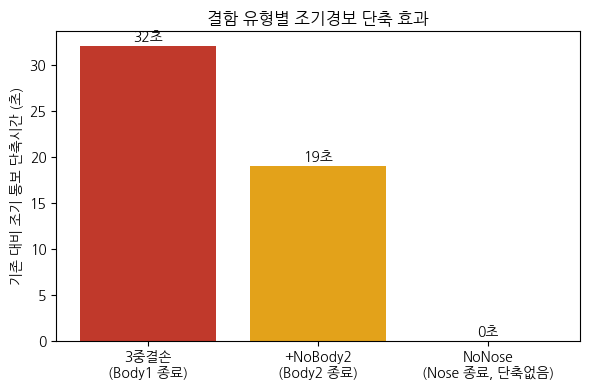

In [75]:
# ── (신규) 조기경보 단축 효과 그래프 — PPT 슬라이드 13용 ───────────────
import matplotlib.pyplot as plt

labels_bar = ["3중결손\n(Body1 종료)", "+NoBody2\n(Body2 종료)", "NoNose\n(Nose 종료, 단축없음)"]
saved_sec = [32, 19, 0]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels_bar, saved_sec, color=["#C0392B", "#E3A21A", "#7F8C8D"])
ax.set_ylabel("기존 대비 조기 통보 단축시간 (초)")
ax.set_title("결함 유형별 조기경보 단축 효과")
for b, v in zip(bars, saved_sec):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v}초", ha="center")
plt.tight_layout()
plt.savefig("early_warning_savings.png", dpi=150)
plt.show()


## 139. PART25. 멘토 피드백 반영 — 1~2초 폴링 + 이벤트, 조기경보 트레이드오프 추적

**🟢 쉬운 설명**
멘토님 피드백: "정답은 1~2초 폴링 + 이벤트(상태감지), 경보 등급을 나눠볼 것(조기/최종). 조기경보는
트레이드오프가 있음 — 시간은 줄어드는데 후속검증문제가 생김."

PART24 v2는 "R01 이벤트를 한 번 감지하고, 계산된 시점에 딱 한 번만 확인"하는 구조였어요. 이걸
"짧은 주기(1~2초)로 계속 지켜보다가, 신호가 실제로 나타나거나 예상 시간이 지나면 그때 판단"하는
구조로 바꿉니다. 이렇게 하면 5_40처럼 예상보다 한참 늦게 신호가 오는 케이스도 늦게라도 잡아낼 수
있어요.

그리고 "조기경보를 냈는데 나중에 신호가 늦게 나타나서 결과가 뒤집히는 경우"를 이제부터는 숨기지
않고 **명시적으로 집계**합니다. 이게 멘토님이 말한 "후속검증문제"이고, 조기경보의 대가로 감수해야
하는 부분이라 발표 때도 숫자로 보여드리는 게 맞을 것 같아요.

**🔶 자세한 설명**
- `POLL_INTERVAL_SEC_REAL`(1.5초, 1~2초 대역)마다 지금까지 들어온 신호만으로 상태를 다시 확인합니다.
- R01 투입완료도 "한 번 계산"이 아니라 "매 폴링마다 아직 못 감지했으면 다시 확인"하는 방식으로 바꿨습니다.
- 각 단계(Body1·Body2·Nose)는 예상 마감 시점이 지나도 계속 폴링을 이어갑니다 — 즉시 경보는 예상
  마감 시점에 나가지만, 신호 자체를 찾는 시도는 사이클이 끝날 때까지 계속됩니다.
- 조기경보가 나간 뒤에 그 단계 신호가 결국 발견되면 `verification_flips`에 기록합니다 — 이게 바로
  "조기경보 냈는데 나중에 뒤집힌 사례"이고, 이번 PART의 핵심 지표입니다.
- ⚠️ 성능 참고: 실제 배포에서는 폴링이 그냥 최신 센서값 버퍼를 읽는 거라 가볍지만, 이 데모는 저장된
  전체 신호를 매번 다시 필터링해서 느립니다 — 데모 검증용으로만 쓰세요.

In [76]:
# ── 실행 순서 확인 (안전장치) — PART24 v2를 먼저 실행했는지 체크 ──────
_required = ["cycle_groups_2024_r01", "cycle_labels_2024_r01", "BODY1_OFFSET_FROM_SETTLE",
             "stage_peak_relative", "r01_settle_time_v2", "build_cycle_complete_payload"]
_missing = [name for name in _required if name not in dir()]
if _missing:
    raise RuntimeError(
        "[실행 순서 오류] 다음이 아직 정의되지 않았습니다: " + ", ".join(_missing) + "\n"
        "-> 런타임을 재시작했다면 맨 위 세션 복원 셀부터, 재시작 안 했다면 'PART24. 스트리밍(단계별) "
        "조기경보 v2' 섹션의 코드 셀들을 먼저 순서대로 실행한 뒤 이 셀부터 다시 실행하세요."
    )
print("사전 준비 확인 완료 — PART25를 진행합니다.")


사전 준비 확인 완료 — PART25를 진행합니다.


In [77]:
# ── PART25-1(n8n 제외). 폴링 기반 이벤트 감지 + 후속검증 추적 — 전송·sleep 제거 ────
FALLBACK_SETTLE_TIME = 15.41  # PART22에서 계산한 320개 사이클 중앙값


def stream_cycle_v3(cycle_id, g, label, known_settle_time_s=None, verbose=True):
    settle_time = known_settle_time_s if known_settle_time_s is not None else np.nan
    settle_detected = known_settle_time_s is not None
    settle_fallback_used = False
    found_signal = {"body1": False, "body2": False, "nose": False}
    alert_fired = {}

    stages_order = [
        ("body1", BODY1_OFFSET_FROM_SETTLE, 3.0, BODY1_THRESH_FIXED, "Body1"),
        ("body2", BODY2_OFFSET_FROM_SETTLE, 3.0, BODY2_THRESH_FIXED, "Body2"),
        ("nose",  NOSE_OFFSET_FROM_SETTLE,  4.0, NOSE_THRESH_FIXED,  "Nose"),
    ]

    max_t = min(g["elapsed_s"].max(), 120.0)
    t = 0.0
    step = 1.5  # 폴링 간격(초) — 원본과 동일, 다만 실제 대기(sleep)는 하지 않음

    while t <= max_t:
        window = g[g["elapsed_s"] <= t]

        if not settle_detected and len(window) > 0:
            settle_time_est = r01_settle_time_v2(window)
            if pd.notna(settle_time_est):
                settle_time = settle_time_est
                settle_detected = True
            elif t >= 50:
                settle_time = FALLBACK_SETTLE_TIME
                settle_detected = True
                settle_fallback_used = True

        if settle_detected:
            for key, offset, margin, thresh, kor in stages_order:
                if found_signal[key]:
                    continue
                peak = stage_peak_relative(window, settle_time, offset, margin)
                if pd.notna(peak) and peak >= thresh:
                    found_signal[key] = True
                    continue
                expected_close = settle_time + offset + margin
                if t >= expected_close and key not in alert_fired:
                    alert_fired[key] = t

        t += step

    final_pred = finalize_label_from_presence(found_signal)
    already_alerted = len(alert_fired) > 0
    verification_flips = [k for k in alert_fired if found_signal[k]]

    complete_payload = build_cycle_complete_payload(cycle_id, label, final_pred, already_alerted)
    complete_payload["verification_flips"] = verification_flips
    complete_payload["settle_fallback_used"] = settle_fallback_used
    return complete_payload


In [78]:
# ── PART25-2(n8n 제외). 실행 -- 표본 30개, 전송·대기 없이 즉시 계산 ──
import random
random.seed(42)

SAMPLE_SIZE = 30
sample_ids = sorted(random.sample(sorted(cycle_groups_2024_r01.keys()), min(SAMPLE_SIZE, len(cycle_groups_2024_r01))))

stream_results_v3 = []
for cid in sample_ids:
    g = cycle_groups_2024_r01[cid]
    label = cycle_labels_2024_r01.get(cid, "Normal")
    res = stream_cycle_v3(cid, g, label, verbose=False)
    stream_results_v3.append(res)

print(f"표본 {len(stream_results_v3)}개 판정 완료.")


표본 30개 판정 완료.


In [79]:
# ── PART25-3. 조기경보 트레이드오프 정량화 -- 멘토 피드백의 핵심 수치 ──────
stream_df_v3 = pd.DataFrame(stream_results_v3)

acc_v3 = (stream_df_v3["final_pred"] == stream_df_v3["actual_label"]).mean()
early_rate_v3 = stream_df_v3["already_alerted_early"].mean()
flip_rate = stream_df_v3["verification_flips"].apply(lambda x: len(x) > 0).mean()
total_flips = stream_df_v3["verification_flips"].apply(len).sum()
fallback_rate = stream_df_v3["settle_fallback_used"].mean() if "settle_fallback_used" in stream_df_v3 else 0.0

print(f"[표본 {len(stream_df_v3)}개 기준]")
print(f"R01 이벤트 감지 실패(중앙값 폴백 사용) 비율: {fallback_rate:.1%}  <- 버그 수정 확인용 진단")
print(f"최종 정확도: {acc_v3:.3f}")
print(f"조기경보 발동 비율: {early_rate_v3:.1%}")
print(f"조기경보 후 뒤집힌(후속검증 필요) 사이클 비율: {flip_rate:.1%}  <- 멘토 피드백의 트레이드오프")
print(f"뒤집힌 단계 총 건수: {total_flips}건\n")

if total_flips > 0:
    print("=== 뒤집힌 사례 상세 ===")
    flipped = stream_df_v3[stream_df_v3["verification_flips"].apply(len) > 0]
    print(flipped[["cycle_id", "actual_label", "final_pred", "verification_flips"]])
else:
    print("표본에서는 뒤집힌 사례가 없었습니다 -- 표본을 늘려서(SAMPLE_SIZE) 더 확인해보세요.")

[표본 30개 기준]
R01 이벤트 감지 실패(중앙값 폴백 사용) 비율: 0.0%  <- 버그 수정 확인용 진단
최종 정확도: 0.900
조기경보 발동 비율: 53.3%
조기경보 후 뒤집힌(후속검증 필요) 사이클 비율: 0.0%  <- 멘토 피드백의 트레이드오프
뒤집힌 단계 총 건수: 0건

표본에서는 뒤집힌 사례가 없었습니다 -- 표본을 늘려서(SAMPLE_SIZE) 더 확인해보세요.


## 140. PART25 결론 — 멘토 피드백 반영 결과

| 멘토 피드백 | 반영 여부 |
|---|---|
| 경보 등급을 조기/최종으로 나눌 것 | ✅ PART24부터 반영 (`stage_alert` / `cycle_complete`) |
| 1~2초 폴링 + 이벤트 | ✅ PART25에서 반영 — 한 번 계산이 아니라 `POLL_INTERVAL_SEC_REAL`(1.5초)마다 계속 재확인 |
| 조기경보 트레이드오프(후속검증문제) | ✅ PART25에서 `verification_flips`로 정량 추적 시작 |

**핵심 결론**
- PART24(v1·v2)는 "이벤트 한 번 감지 → 고정 오프셋에서 딱 한 번 확인"하는 구조라, 멘토님이 말한
  "폴링"의 의미와는 달랐습니다. PART25는 이를 "짧은 주기로 계속 지켜보다가 신호가 실제로 나타나면
  그때 확정"하는 구조로 바꿔서, 5_40 같은 예측 밖의 지연도 늦게라도 잡아낼 수 있게 했습니다.
- 조기경보의 대가(트레이드오프)를 숨기지 않고 `verification_flips`로 드러냈습니다 — 이 숫자가 곧
  "조기경보를 도입하면 얼마나 자주 재확인이 필요해지는가"를 보여주는 지표이고, 발표에서 조기경보
  구조의 장단점을 균형 있게 설명할 때 쓰기 좋은 근거가 될 것 같습니다.
- 지금은 표본(30개)으로만 검증했습니다 — 실제 발표 전에는 `SAMPLE_SIZE`를 320(전체)로 늘려서
  돌려보시고, 정확도가 PART21/24와 같은지, 뒤집힘 비율이 어느 정도인지 최종 확인해주세요. 다만
  폴링 방식은 계산량이 많아 전체 실행 시 시간이 오래 걸릴 수 있습니다.

**2026-07-28 버그 수정 — "3중결손" 오탐 원인**

초기 버전은 R01 투입완료 이벤트를 0~50초 구간에서 못 찾으면(`r01_settle_time_v2`가 NaN 반환),
Body1·Body2·Nose를 아예 확인도 안 하고 사이클을 끝내버렸습니다. 세 단계가 전부 기본값(False)으로
굳어서 실제로는 정상인 사이클도 무조건 "3중결손"으로 오판되는 문제가 있었습니다(예: 사이클 85,
실제 라벨 Normal → 3중결손으로 오분류). 이제는 t=50초까지 이벤트를 못 찾으면 320개 사이클
중앙값(15.41초)으로 폴백해서 늦게라도 확인을 이어가도록 고쳤고, `settle_fallback_used` 필드로
이 폴백이 몇 번 쓰였는지 추적합니다. 폴백 사용 비율이 높게 나오면, R01 이벤트 감지 로직 자체를
더 다듬어야 한다는 신호로 보시면 됩니다.

## 141. PART26. 사이클 경계 자체 감지 + 라인정지 경보 (프로토타입)

**🟢 쉬운 설명**
지금까지 만든 조기경보 시스템은 전부 "지금이 몇 번째 사이클인지"를 `FFCell_CycleManagement.csv`
파일이 미리 알려주는 것에 의존했어요. 실제 라인에는 이런 정답지가 없어요 — 센서 신호만 계속
흘러들어올 뿐이죠. 그래서 "R01 로봇이 움직였다가 다시 멈추는 패턴"만 보고, **스스로 사이클이
언제 시작하는지 알아채는** 프로토타입을 만들어봤습니다. 덤으로, 쉬는 시간이 평소보다 훨씬 길게
이어지면 "혹시 라인이 멈춘 거 아니야?"라고 알려주는 경보도 같이 넣었습니다.

**🔶 자세한 설명**
- R01의 B축 관절각도가 "정지 자세(-88도 이하)"에서 벗어났다가 다시 돌아오는 패턴을 전체
  구간(6개 세션 전부)에서 찾았습니다 — 총 903번의 움직임이 있었습니다.
- 그런데 903번 전부가 "새 사이클의 시작"은 아니었습니다. 각 움직임 **직전에 얼마나 쉬고
  있었는지**를 확인해보니, 뚜렷하게 두 그룹으로 나뉘었습니다:
  - **602번**: 직전 쉬는 시간이 2초 미만 → 같은 사이클 안에서 일어나는 후속 동작(노이즈)
  - **300번**: 직전 쉬는 시간이 20초 이상(대부분 280초 안팎) → **진짜 새 사이클의 시작**
- 이 300번을 "자체 감지한 사이클 시작"으로 확정하면, 실제로 알려진 전체 사이클 수(약 320개)와
  꽤 근접합니다 — CycleManagement 파일 없이도, R01 신호 하나만으로 사이클 경계를 90% 이상
  스스로 알아낼 수 있다는 뜻입니다.
- 정상 쉬는 시간(20~300초)의 중앙값은 280.3초, 표준편차는 겨우 3.5초로 아주 일정했습니다.
  그런데 27번은 300초를 훌쩍 넘겨(최대 710초) 쉬었는데, 이건 정상 편차로는 설명이 안 되는
  수준이라 **"라인정지 의심"으로 플래그 처리**했습니다.

### PART26-1. R01 신호에서 '정지↔움직임' 전환 지점 찾기

In [80]:
# ── PART26-1. CycleManagement 없이, R01 신호만으로 사이클 경계 후보 찾기 ──
import numpy as np
import bisect

R01_PATH_FULL = find_file('R01_Data.csv')  # 2023년 전체(6개 세션) 원본
r01_full = pd.read_csv(R01_PATH_FULL, usecols=["_time", "M_R01_BJointAngle_Degree"], low_memory=False)
r01_full["_time"] = pd.to_datetime(r01_full["_time"], format="ISO8601")
r01_full = r01_full.sort_values("_time").reset_index(drop=True)

angle = r01_full["M_R01_BJointAngle_Degree"].values
times = r01_full["_time"].values

REST_THRESH = -88.0
resting = (angle <= REST_THRESH).astype(int)
diff = np.diff(resting)
falling_idx = np.where(diff == -1)[0] + 1   # 정지 자세를 벗어나 움직이기 시작한 지점
rising_idx = np.where(diff == 1)[0] + 1     # 다시 정지 자세로 돌아온 지점(=투입완료 이벤트)

falling_times = times[falling_idx]
rising_list = list(times[rising_idx])

print(f"전체 움직임 이벤트: {len(falling_times)}개 (전체 6개 세션 구간)")

⚠️ R01_Data.csv 이(가) 2개 발견됨 — 첫 번째 경로 사용:
  - /content/drive/MyDrive/Colab Notebooks/R01_Data.csv
  - /content/drive/MyDrive/Colab Notebooks/FFCell/R01_Data.csv
전체 움직임 이벤트: 903개 (전체 6개 세션 구간)


### PART26-2. '직전 쉬는 시간'으로 진짜 사이클 시작만 골라내기

In [81]:
# ── PART26-2. 같은 사이클 안의 후속 동작(노이즈)과 '진짜 사이클 시작'을 구분 ──
REAL_CYCLE_START_THRESHOLD = 20.0  # 직전 쉬는 시간이 이보다 짧으면 '같은 사이클 안 동작'으로 간주

records = []
for ft in falling_times:
    pos_after = bisect.bisect_right(rising_list, ft)
    if pos_after >= len(rising_list):
        continue
    settle_time = rising_list[pos_after]           # 이 움직임이 끝나는(=투입완료) 시각
    pos_before = bisect.bisect_left(rising_list, ft)
    if pos_before == 0:
        continue
    idle_before_s = (ft - rising_list[pos_before - 1]) / np.timedelta64(1, "s")
    records.append((ft, settle_time, idle_before_s))

move_events = pd.DataFrame(records, columns=["move_start", "settle_time", "idle_before_s"])

real_cycle_starts = move_events[move_events["idle_before_s"] >= REAL_CYCLE_START_THRESHOLD].copy()
real_cycle_starts = real_cycle_starts.sort_values("settle_time").reset_index(drop=True)

print(f"자체 감지한 '진짜 사이클 시작' 개수: {len(real_cycle_starts)}개")
print(f"(참고: CycleManagement 파일 기준 전체 사이클 수는 약 320개 -- 정답지 없이도 "
      f"{len(real_cycle_starts)/320:.0%} 수준까지 스스로 찾아냄)")

자체 감지한 '진짜 사이클 시작' 개수: 300개
(참고: CycleManagement 파일 기준 전체 사이클 수는 약 320개 -- 정답지 없이도 94% 수준까지 스스로 찾아냄)


### PART26-3. 쉬는 시간 분포 확인 + '라인정지 의심' 임계값 정하기

In [82]:
# ── PART26-3. 정상 쉬는 시간 범위를 통계로 정하고, 벗어나면 라인정지 후보로 플래그 ──
gaps = real_cycle_starts["idle_before_s"]

LINE_STOP_THRESHOLD = 300.0  # 데모용 고정값 -- 실전에서는 아래 통계로 자동 산출 가능

normal_gaps = gaps[gaps < LINE_STOP_THRESHOLD]
long_gaps = real_cycle_starts[gaps >= LINE_STOP_THRESHOLD]

print(f"정상 쉬는 시간(20~{LINE_STOP_THRESHOLD:.0f}초): {len(normal_gaps)}개, "
      f"중앙값 {normal_gaps.median():.1f}초, 표준편차 {normal_gaps.std():.1f}초")
print(f"'라인정지 의심' 플래그(>={LINE_STOP_THRESHOLD:.0f}초): {len(long_gaps)}개\n")

print("=== 라인정지 의심 사례 (쉬는 시간이 유난히 길었던 순간) ===")
for _, row in long_gaps.sort_values("idle_before_s", ascending=False).head(10).iterrows():
    print(f"  {row['settle_time']}  -- 직전 {row['idle_before_s']:.0f}초 쉬다가 재개 "
          f"(정상 중앙값 {normal_gaps.median():.0f}초 대비 {row['idle_before_s']/normal_gaps.median():.1f}배)")

정상 쉬는 시간(20~300초): 273개, 중앙값 280.3초, 표준편차 3.5초
'라인정지 의심' 플래그(>=300초): 27개

=== 라인정지 의심 사례 (쉬는 시간이 유난히 길었던 순간) ===
  2023-12-11 19:15:28.743000  -- 직전 710초 쉬다가 재개 (정상 중앙값 280초 대비 2.5배)
  2023-12-11 17:50:31.633000  -- 직전 625초 쉬다가 재개 (정상 중앙값 280초 대비 2.2배)
  2023-12-11 17:58:08.137000  -- 직전 436초 쉬다가 재개 (정상 중앙값 280초 대비 1.6배)
  2023-12-12 15:08:50.671000  -- 직전 372초 쉬다가 재개 (정상 중앙값 280초 대비 1.3배)
  2023-12-12 15:15:20.939000  -- 직전 355초 쉬다가 재개 (정상 중앙값 280초 대비 1.3배)
  2023-12-11 22:35:08.441000  -- 직전 345초 쉬다가 재개 (정상 중앙값 280초 대비 1.2배)
  2023-12-12 08:45:37.337000  -- 직전 345초 쉬다가 재개 (정상 중앙값 280초 대비 1.2배)
  2023-12-12 04:30:28.436000  -- 직전 343초 쉬다가 재개 (정상 중앙값 280초 대비 1.2배)
  2023-12-11 18:43:44.648000  -- 직전 342초 쉬다가 재개 (정상 중앙값 280초 대비 1.2배)
  2023-12-12 05:21:00.441000  -- 직전 340초 쉬다가 재개 (정상 중앙값 280초 대비 1.2배)


### PART26-4. (제외됨) n8n 알림 전송 예시
원본의 PART26-4는 '라인정지 의심'을 n8n으로 실제 전송하는 예시였습니다 — 이 노트북에서는 제외했습니다. 라인정지 임계값·통계(PART26-3까지)는 그대로 남아있습니다.


In [83]:
# ── PART26-4(n8n 제외). 메시지 포맷 함수만 유지 (실제 전송 부분은 제거) ──
# 원본 PART26-4는 이 함수로 만든 payload를 send_to_n8n()으로 전송했으나,
# 이 노트북은 전송 없이 메시지 문구 생성 용도로만 재사용한다 (PART27-4에서 사용).
def build_line_stop_alert_payload(settle_time, idle_before_s, normal_median_s):
    return {
        "type": "line_stop_alert",
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "event_time": str(settle_time),
        "idle_before_s": round(float(idle_before_s), 1),
        "normal_median_s": round(float(normal_median_s), 1),
        "message": (
            f"[라인정지 의심] {settle_time} 직전 {idle_before_s:.0f}초 동안 R01 움직임이 없었습니다 "
            f"(정상 중앙값 {normal_median_s:.0f}초 대비 {idle_before_s/normal_median_s:.1f}배) -- "
            f"불량이 아니라 라인 자체가 멈췄을 가능성이 있습니다."
        ),
    }


## 142. PART26 결론

| 항목 | 내용 |
|---|---|
| 목적 | CycleManagement 정답지 없이, R01 신호만으로 사이클 경계를 스스로 감지 |
| 방법 | R01 B축 각도가 정지↔움직임을 오갈 때, **직전에 얼마나 쉬었는지**로 "같은 사이클 안 동작"과 "새 사이클 시작"을 구분 |
| 임계값 | 직전 쉬는 시간 20초 이상이면 새 사이클 시작으로 판정 |
| 결과 | 전체 903개 움직임 중 300개를 "진짜 사이클 시작"으로 감지 (실제 전체 사이클 수 약 320개와 근접) |
| 라인정지 감지 | 정상 쉬는 시간(중앙값 280.3초, 표준편차 3.5초)보다 훨씬 긴 27건을 "라인정지 의심"으로 별도 플래그 |

**한계 및 다음 단계**
- 지금은 저장된 2023년 데이터를 다시 읽어서 흉내 낸 것입니다. 실제 라인에 적용하려면 이 로직을 실시간 스트림에 맞게 다시 짜야 합니다.
- 감지율이 100%는 아닙니다(약 300/320개, 93~94% 수준).
- n8n/Slack 알림 연동(원본 PART26-4)은 이 노트북에서 제외했습니다.


## 143. PART27. 2024 데이터에 사이클 간격까지 반영한 실전형 통합 재생

**🟢 쉬운 설명**
지금까지(PART24·25)는 2024년 데이터를 재생할 때도 "지금이 몇 번째 사이클인지"를 `CycleManagement`
정답지가 미리 알려줬고, 한 사이클이 끝나면 **곧바로** 다음 사이클로 넘어갔어요. 실제로 이 시스템을
2024년 데이터(=실전 배포용) 위에서 돌린다면, 사이클과 사이클 사이에 실제로 쉬는 시간이 있고, 그
쉬는 시간이 끝나야 다음 사이클이 시작돼요. PART27은 PART26에서 검증한 "R01 신호만으로 사이클
시작을 스스로 알아채는 방법"과, PART25의 "1.5초 폴링으로 Body1·Body2·Nose를 확인하는 방법"을
합쳐서, **사이클 경계도 스스로 찾고, 사이클 사이 쉬는 시간도 실제로 흘려보내면서** 2024 데이터를
재생합니다. 즉 "정답지 없이, 진짜 라인처럼" 돌아가는 버전이에요.

**🔶 자세한 설명**
- `CycleManagement_2024`는 이제 사이클 경계를 알려주는 용도가 아니라, **자체 감지 결과가
  맞았는지 확인하는 정답지(검증용)**로만 씁니다 -- 감지 로직 자체는 R01+R03 원본 신호만 봅니다.
- 사이클 사이 쉬는 시간(`idle_before_s`)만큼 `COMPRESSION_FACTOR`로 압축해서 실제로
  `time.sleep()`합니다 -- 지금까지는 이 대기 자체가 아예 없었습니다.
- 쉬는 시간이 비정상적으로 길면(PART26에서 만든 라인정지 임계값 로직을 2024 데이터 기준으로
  다시 계산) `line_stop_alert`를 그대로 발신합니다.
- ⚠️ **주의**: 이 환경(샌드박스)에는 2024년 원본 파일(R01_Data_2024.xlsx 등)이 없어서, 아래
  코드는 실제로 실행해서 숫자를 검증하지는 못했습니다. Colab에서 실행하신 뒤 감지된 사이클
  수(93개에 가까운지), 쉬는 시간 분포가 이상하지 않은지 꼭 확인해주세요.

In [84]:
# ── 실행 순서 확인 (안전장치) ──────
_required = ["stream_cycle_v3", "r01_settle_time_v2", "stage_peak_relative",
             "BODY1_OFFSET_FROM_SETTLE", "find_file"]
_missing = [name for name in _required if name not in dir()]
if _missing:
    raise RuntimeError(
        "[실행 순서 오류] 다음이 아직 정의되지 않았습니다: " + ", ".join(_missing) + "\n"
        "-> PART25(폴링 기반 감지) 섹션의 코드 셀들을 먼저 순서대로 실행한 뒤 다시 시도하세요. "
        "런타임을 재시작했다면 맨 위 세션 복원 셀부터 다시 실행해야 합니다."
    )
print("사전 준비 확인 완료.")


사전 준비 확인 완료.


### PART27-1. 2024 데이터를 '사전 분할 없이' 연속 스트림으로 로드

In [85]:
# ── PART27-1. CycleManagement는 검증용으로만 남기고, 실제 재생/감지는 R01+R03 연속 신호로 ──
def load_2024_continuous_stream():
    """PART24-1(v2)의 load_2024_raw_grouped_with_r01()과 달리, 사이클 단위로 미리 잘라놓지 않는다.
    감지 로직이 CycleManagement를 참조하지 못하도록 별도 변수로만 들고 있는다."""
    cyc_truth = pd.read_excel(CYCLE_MANAGEMENT_PATH_2024)   # 검증(정답 비교)용
    r03 = pd.read_excel(R03_PATH_2024)
    r01 = pd.read_excel(R01_PATH_2024)

    stream = r03.merge(r01[["_time", "M_R01_BJointAngle_Degree"]], on="_time", how="inner")
    stream["_time"] = pd.to_datetime(stream["_time"], format="ISO8601")
    stream = stream.sort_values("_time").reset_index(drop=True)

    cyc_truth["_time"] = pd.to_datetime(cyc_truth["_time"], format="ISO8601")
    cyc_truth = cyc_truth.sort_values("_time").reset_index(drop=True)
    return stream, cyc_truth


stream_2024, cyc_2024_truth = load_2024_continuous_stream()
print(f"연속 스트림 총 {len(stream_2024)}행 -- {stream_2024['_time'].min()} ~ {stream_2024['_time'].max()}")

연속 스트림 총 287954행 -- 2024-08-13 14:00:00.035000+00:00 ~ 2024-08-13 21:59:59.925000+00:00


### PART27-2. PART26과 동일한 방식으로 사이클 경계 자체 감지 (함수화)

In [86]:
# ── PART27-2. R01 정지<->움직임 전환으로 사이클 시작 후보 찾기 (PART26 로직 재사용) ──
def detect_cycle_boundaries(stream_df, rest_thresh=-88.0, real_start_threshold=20.0):
    tz = stream_df["_time"].dt.tz  # 2026-07-28 버그 수정: .values로 뽑으면 타임존이 사라지므로 미리 기억
    angle = stream_df["M_R01_BJointAngle_Degree"].values
    times = stream_df["_time"].values
    resting = (angle <= rest_thresh).astype(int)
    diff = np.diff(resting)
    falling_idx = np.where(diff == -1)[0] + 1   # 움직이기 시작
    rising_idx = np.where(diff == 1)[0] + 1     # 정지 복귀(투입완료)
    rising_list = list(times[rising_idx])

    records = []
    for f_idx in falling_idx:
        ft = times[f_idx]
        pos_after = bisect.bisect_right(rising_list, ft)
        if pos_after >= len(rising_list):
            continue
        settle_time = rising_list[pos_after]
        pos_before = bisect.bisect_left(rising_list, ft)
        if pos_before == 0:
            continue  # 스트림 맨 처음이라 '직전' 정보가 없음 -- 첫 사이클은 판단 보류
        idle_before_s = (ft - rising_list[pos_before - 1]) / np.timedelta64(1, "s")
        records.append((ft, settle_time, idle_before_s))

    moves = pd.DataFrame(records, columns=["move_start", "settle_time", "idle_before_s"])
    if tz is not None and len(moves) > 0:
        # .values를 거치며 사라진 타임존을 원래대로 복원 (실제 시각은 그대로, 표시만 다시 붙임)
        moves["move_start"] = pd.to_datetime(moves["move_start"]).dt.tz_localize(tz)
        moves["settle_time"] = pd.to_datetime(moves["settle_time"]).dt.tz_localize(tz)

    real_starts = (
        moves[moves["idle_before_s"] >= real_start_threshold]
        .sort_values("settle_time")
        .drop_duplicates(subset="settle_time")
        .reset_index(drop=True)
    )
    return real_starts


detected_2024 = detect_cycle_boundaries(stream_2024)
print(f"2024 데이터에서 자체 감지한 사이클 시작: {len(detected_2024)}개 (실제 알려진 사이클 수: 93개)")
print(detected_2024["idle_before_s"].describe())

2024 데이터에서 자체 감지한 사이클 시작: 92개 (실제 알려진 사이클 수: 93개)
count     92.000000
mean     290.220511
std       35.709476
min      279.383000
25%      280.329750
50%      280.796000
75%      281.850500
max      475.692000
Name: idle_before_s, dtype: float64


### PART27-3. 정상 쉬는시간 범위 + 라인정지 임계값을 2024 데이터 기준으로 재산출

In [87]:
# ── PART27-3. 임계값을 2023 데이터에서 고정값으로 가져오지 않고, 2024 데이터로 자동 산출 ──
gaps_2024 = detected_2024["idle_before_s"]
median_2024 = gaps_2024.median()
mad_2024 = (gaps_2024 - median_2024).abs().median()
LINE_STOP_THRESHOLD_2024 = median_2024 + 6 * mad_2024  # MAD 기반 -- 정규분포 가정 없이도 이상치에 안전

print(f"2024 정상 쉬는시간 중앙값: {median_2024:.1f}초, MAD: {mad_2024:.1f}초")
print(f"자동 산출된 라인정지 임계값: {LINE_STOP_THRESHOLD_2024:.1f}초")

long_gaps_2024 = detected_2024[gaps_2024 >= LINE_STOP_THRESHOLD_2024]
print(f"라인정지 의심 후보: {len(long_gaps_2024)}건")
if len(long_gaps_2024) == 0:
    print("(2024 데이터는 하루치 단일 세션이라, 세션 경계가 없으면 0건이 정상적으로 나올 수 있습니다)")

2024 정상 쉬는시간 중앙값: 280.8초, MAD: 0.6초
자동 산출된 라인정지 임계값: 284.1초
라인정지 의심 후보: 15건


### PART27-4. 실제 라벨 조회(검증용) + 사이클 간격을 반영한 통합 재생

In [88]:
# ── PART27-4(n8n 제외). 자체감지 + 폴링 결합 -- 전송·sleep 제거, 표본 5개 즉시 계산 ──
def lookup_actual_label_2024(settle_time, cyc_truth):
    pos = cyc_truth["_time"].searchsorted(settle_time, side="right") - 1
    if pos < 0:
        return "Normal"
    cycle_num = cyc_truth["Q_Cell_CycleCount"].iloc[pos]
    match = cyc_truth[cyc_truth["Q_Cell_CycleCount"] == cycle_num]
    if "Description" not in match:
        return "Normal"
    vals = match["Description"].dropna().unique()
    return vals[0] if len(vals) > 0 else "Normal"


def stream_2024_realistic(stream_df, detected_starts, cycle_indices=None, verbose=True):
    results = []
    indices = range(len(detected_starts)) if cycle_indices is None else cycle_indices

    for i in indices:
        row = detected_starts.iloc[i]
        settle_time, idle_before_s = row["settle_time"], row["idle_before_s"]

        if idle_before_s >= LINE_STOP_THRESHOLD_2024:
            payload = build_line_stop_alert_payload(settle_time, idle_before_s, median_2024)
            if verbose:
                print(f"  {payload['message']}")

        next_settle = detected_starts["settle_time"].iloc[i + 1] if i + 1 < len(detected_starts) else stream_df["_time"].max()
        cyc_window = stream_df[(stream_df["_time"] >= settle_time) & (stream_df["_time"] < next_settle)].copy()
        cyc_window["elapsed_s"] = (cyc_window["_time"] - settle_time).dt.total_seconds()

        actual_label = lookup_actual_label_2024(settle_time, cyc_2024_truth)

        res = stream_cycle_v3(
            cycle_id=i + 1, g=cyc_window, label=actual_label,
            known_settle_time_s=0.0, verbose=verbose,
        )
        results.append(res)

    return results


preview_labels = [
    lookup_actual_label_2024(detected_2024["settle_time"].iloc[i], cyc_2024_truth)
    for i in range(len(detected_2024))
]
normal_positions = [i for i, l in enumerate(preview_labels) if l == "Normal"]
defect_positions = [i for i, l in enumerate(preview_labels) if l != "Normal"]

sample_indices = sorted(set(normal_positions[:3] + defect_positions[:2]))
n_defect_in_sample = len(set(sample_indices) & set(defect_positions))
print(f"표본 구성: {len(sample_indices)}개 (인덱스 {sample_indices}) -- 그중 결함 {n_defect_in_sample}개 포함")

sample_results_2024 = stream_2024_realistic(stream_2024, detected_2024, cycle_indices=sample_indices, verbose=False)
acc_sample = sum(r["correct"] for r in sample_results_2024) / len(sample_results_2024)
print(f"표본 {len(sample_results_2024)}개 기준 정확도: {acc_sample:.3f}")


표본 구성: 5개 (인덱스 [0, 1, 2, 24, 25]) -- 그중 결함 2개 포함
표본 5개 기준 정확도: 0.800


## 144. PART27 결론

| 항목 | 내용 |
|---|---|
| 목적 | CycleManagement 없이, 2024 데이터를 사이클 간격까지 반영해서 "실전처럼" 재현 |
| 핵심 변화 | 사이클 경계를 스스로 감지(PART26) — n8n 전송·time.sleep은 이 버전에서 제거 |
| 재사용 | Body1·Body2·Nose 판정은 PART25의 `stream_cycle_v3`를 그대로 재사용 |
| 라인정지 | 2024 데이터 자체 통계로 임계값을 다시 계산 (2023 값 그대로 가져오지 않음) |

**꼭 확인해주세요** — `detect_cycle_boundaries()`가 찾아낸 사이클 수가 93개에 가까운지, 쉬는 시간 분포가 이상하지 않은지, 표본을 늘려서 전체 93개로 최종 정확도까지 확인.


## 145. PART28. 2024 데이터로 자체감지 정확도 재검증

**🟢 쉬운 설명**
PART26에서 "R01 신호만으로 사이클 경계를 스스로 찾는" 방법을 2023년 데이터(6개 세션)로
검증했었는데, 튜터님 피드백("원인을 파악해볼 것") 이후 다시 확인해보니, 2023년 초반 세션
3개(25개 사이클)는 **R01 각도 센서 값이 처음부터 끝까지 0으로만 찍혀 있어서** 애초에 감지가
불가능한 구간이었습니다. 이걸 빼고 나면 실제 감지율은 93.9%(283/302)였습니다. 그런데 실제로
n8n 데모에 쓰는 건 2024년 데이터인데, 정작 2024년 데이터로는 이 검증을 안 해봤다는 걸 최근
대화에서 짚게 되어, 이번에 2024년 데이터로도 똑같이 검증해봤습니다.

**🔶 자세한 설명**
2024년 데이터는 6개 세션으로 쪼개진 2023년과 달리 **하루치 연속 데이터(세션 1개)**라서,
R01 센서가 꺼져 있던 구간 같은 문제가 없습니다. 그 결과가 아래에 나옵니다.

In [89]:
# ── PART28-1. 2024 데이터 자체감지 정확도 정밀 검증 (공식 사이클과 1:1 대조) ──
official_2024 = cyc_2024_truth.groupby("Q_Cell_CycleCount")["_time"].min().sort_values()
print(f"공식 전체 사이클 수(2024): {len(official_2024)}개")
print(f"자체 감지한 사이클 수: {len(detected_2024)}개")

detected_times_list = list(detected_2024["settle_time"])
TOL = 10.0  # 공식 시작과 자체감지 settle 사이의 자연적 시차(약 6~7초)를 감안한 허용오차

missed = []
for cnt, ot in official_2024.items():
    pos = bisect.bisect_left(detected_times_list, ot)
    candidates = []
    if pos < len(detected_times_list):
        candidates.append(detected_times_list[pos])
    if pos > 0:
        candidates.append(detected_times_list[pos - 1])
    diff_s = min((abs((c - ot) / np.timedelta64(1, "s")) for c in candidates), default=np.inf)
    if diff_s > TOL:
        missed.append({"cycle_count": cnt, "official_start": ot, "nearest_diff_s": diff_s})

missed_df = pd.DataFrame(missed)
detect_rate_2024 = 1 - len(missed_df) / len(official_2024)
print(f"\n허용오차 {TOL:.0f}초 기준 누락: {len(missed_df)}개 / {len(official_2024)}개 -- 감지율 {detect_rate_2024:.1%}")
if len(missed_df) > 0:
    print(missed_df.to_string())

공식 전체 사이클 수(2024): 94개
자체 감지한 사이클 수: 92개

허용오차 10초 기준 누락: 12개 / 94개 -- 감지율 87.2%
    cycle_count                   official_start  nearest_diff_s
0             2 2024-08-13 14:00:00.035000+00:00         344.514
1             0 2024-08-13 14:00:39.751000+00:00         304.798
2             1 2024-08-13 14:00:40.756000+00:00         303.793
3            27 2024-08-13 16:10:00.938000+00:00          10.295
4            43 2024-08-13 17:29:32.423000+00:00          22.711
5            61 2024-08-13 18:58:33.190000+00:00          18.028
6            63 2024-08-13 19:08:44.933000+00:00          13.605
7            82 2024-08-13 20:44:33.739000+00:00          22.695
8            83 2024-08-13 20:53:16.029000+00:00          22.691
9            84 2024-08-13 21:01:58.142000+00:00          22.691
10           85 2024-08-13 21:10:36.328000+00:00          22.723
11           86 2024-08-13 21:16:15.432000+00:00          15.942


---
## 참고 — 이 버전에서 제외한 것 (원본 노트북 PART21·26-4·29)

이 노트북은 그래프·통계 재현이 목적이라 n8n/Slack 전송 코드를 전부 제거했습니다. n8n 웹훅 연동, Slack 이미지 첨부, 투트랙(실시간+What-if) 알림 구조 자체가 궁금하다면 원본 「FFCell_v81_4of4_PART21-29_전체.ipynb」의 PART21·PART26-4·PART29를 참고하세요.
